# Global River Particulate Organic Carbon (GR-POC) Machine Learning Project

## Notebook 01 : MOREPOC Database Exploration

### MSc Dissertation Project
**Department of Geography**
Central University of Haryana

---

## Project Title

**Development of a Global Machine Learning Model for Riverine Particulate Organic Carbon (POC) Estimation Using Landsat Surface Reflectance and Evaluation over Indian Rivers**

---

## Purpose of this Notebook

This notebook performs an exploratory analysis of the MOREPOC (Modern River Archives of Particulate Organic Carbon) database. The primary objective is to understand the quality, completeness, geographical distribution, temporal coverage, and suitability of the dataset for developing a global machine learning model for riverine particulate organic carbon estimation.

The analyses performed in this notebook provide the foundation for all subsequent stages of the project, including satellite reflectance extraction, feature engineering, machine learning model development, and validation over Indian rivers.

---

**Author:** Atul Pandey

**Project:** Global River POC Machine Learning Model

**Version:** 1.0

# Project Objective

The primary objective of this research is to develop a global machine learning model capable of estimating riverine particulate organic carbon (POC) concentrations using Landsat satellite surface reflectance.

The project aims to:

1. Construct a high-quality global training database from the MOREPOC archive.
2. Extract Landsat surface reflectance corresponding to field sampling locations and dates.
3. Engineer spectral features relevant to POC estimation.
4. Train and optimize multiple machine learning algorithms.
5. Evaluate model performance using independent validation datasets.
6. Assess the transferability of the global model to Indian rivers.
7. Apply the trained model to estimate POC concentrations in the Ganga and Cauvery river systems.

Ultimately, this research investigates whether a globally trained satellite-based machine learning model can accurately estimate particulate organic carbon in Indian rivers.

# Notebook Workflow

This notebook follows a structured exploratory data analysis (EDA) workflow.

```
MOREPOC Database
        │
        ▼
Dataset Overview
        │
        ▼
Missing Value Assessment
        │
        ▼
Country Distribution
        │
        ▼
River Distribution
        │
        ▼
Temporal Distribution
        │
        ▼
POC Concentration Statistics
        │
        ▼
Spatial Distribution
        │
        ▼
Indian Dataset Analysis
        │
        ▼
Identification of Samples Suitable for Machine Learning
```

The outputs generated in this notebook will determine the quality of the training dataset and guide the preprocessing steps required for subsequent machine learning model development.

# Section 1 — Import Required Libraries

## Objective

The objective of this section is to import all Python libraries required for data manipulation, numerical computation, visualization, statistical analysis, and geospatial processing throughout the notebook.

Maintaining a centralized import section improves reproducibility, readability, and notebook organization.

In [2]:
# ============================================================
# Section 1 : Import Required Libraries
# Objective:
# Import all Python libraries required for data manipulation,
# visualization, statistical analysis, and geospatial analysis.
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import geopandas as gpd

warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("=" * 60)
print("Global River POC Machine Learning Project")
print("Notebook 01 : MOREPOC Database Exploration")
print("=" * 60)
print("Libraries imported successfully.")

Global River POC Machine Learning Project
Notebook 01 : MOREPOC Database Exploration
Libraries imported successfully.


In [3]:
# ============================================================
# Section 2 : Load MOREPOC Database
# Objective:
# Import the MOREPOC Version 1.1 dataset into the Python
# environment for exploratory analysis and machine learning.
# ============================================================

import os
import pandas as pd

# Define dataset location
morepoc_path = (
    r"G:\OCR\Aqua_OC_India\notebooks"
    r"\MOdern River archivEs of Particulate Organic Carbon MOREPOC"
    r"\Version 1.1\7055970\MOREPOC_v1.1.csv"
)

# Load dataset
morepoc = pd.read_csv(morepoc_path)

print("✓ MOREPOC dataset loaded successfully.")

✓ MOREPOC dataset loaded successfully.


In [4]:
# ============================================================
# Section 2 : Verify Dataset
# Objective:
# Confirm that the dataset has been successfully loaded and
# display its storage location.
# ============================================================

print("Dataset Location:")
print(morepoc_path)

print("\nFile Exists:", os.path.exists(morepoc_path))

Dataset Location:
G:\OCR\Aqua_OC_India\notebooks\MOdern River archivEs of Particulate Organic Carbon MOREPOC\Version 1.1\7055970\MOREPOC_v1.1.csv

File Exists: True


In [5]:
# ============================================================
# Section 2 : Dataset Dimensions
# Objective:
# Display the number of observations and variables contained
# in the MOREPOC database.
# ============================================================

rows, columns = morepoc.shape

print("=" * 60)
print("MOREPOC DATASET SUMMARY")
print("=" * 60)

print(f"Number of observations : {rows:,}")
print(f"Number of variables    : {columns}")

MOREPOC DATASET SUMMARY
Number of observations : 3,547
Number of variables    : 26


## Interpretation

The MOREPOC Version 1.1 database has been successfully imported into the Python environment. The dataset contains field observations collected from rivers worldwide and forms the foundation for the development of the Global River POC Machine Learning Model.

The dimensions reported above indicate the total number of river observations (rows) and recorded attributes (columns). These observations include measurements of particulate organic carbon concentration together with spatial coordinates, sampling dates, suspended sediment characteristics, and several ancillary environmental variables.

The imported dataset will now undergo detailed exploratory analysis to assess its completeness, identify missing values, evaluate geographical and temporal coverage, and determine its suitability for machine learning applications.

# Section 3 — Dataset Overview

## Objective

The objective of this section is to examine the overall structure and characteristics of the MOREPOC database.

Before performing quality control or machine learning preprocessing, it is essential to understand the dataset's dimensions, variables, data types, and statistical properties. This preliminary exploration provides insight into the available information and helps identify potential issues such as missing values, inconsistent data types, or redundant variables.

The analyses performed in this section will answer the following questions:

- How many observations and variables are contained in the database?
- What environmental variables are available?
- Which variables are numerical and which are categorical?
- What information is recorded for each river sample?
- What is the statistical range of the numerical variables?

In [6]:
# ============================================================
# Section 3 : Dataset Dimensions
# Objective:
# Display the total number of observations and variables
# contained in the MOREPOC database.
# ============================================================

rows, columns = morepoc.shape

print("=" * 60)
print("MOREPOC DATASET DIMENSIONS")
print("=" * 60)

print(f"Number of observations : {rows:,}")
print(f"Number of variables    : {columns}")

MOREPOC DATASET DIMENSIONS
Number of observations : 3,547
Number of variables    : 26


In [7]:
# ============================================================
# Section 3 : Variable Names
# Objective:
# List all variables available in the MOREPOC database.
# ============================================================

print("=" * 60)
print("VARIABLES AVAILABLE IN MOREPOC")
print("=" * 60)

for i, column in enumerate(morepoc.columns, start=1):
    print(f"{i:02d}. {column}")

VARIABLES AVAILABLE IN MOREPOC
01. bas_id
02. riv_id
03. country
04. cont
05. code
06. time_m
07. time_d
08. time_y
09. lat
10. lon
11. type_spm
12. fra_spm
13. conc_spm
14. conc_poc
15. perc_poc
16. perc_poc_1sd
17. d13C_poc
18. d13C_1sd
19. D14C_poc
20. D14C_1sd
21. age_14C
22. F14C
23. perc_tn
24. cn_ratio
25. alsi_ratio
26. ref


In [8]:
# ============================================================
# Section 3 : Dataset Preview
# Objective:
# Display the first five observations to understand the
# structure and contents of the dataset.
# ============================================================

morepoc.head()

,bas_id,riv_id,country,cont,code,time_m,time_d,time_y,lat,lon,...,d13C_poc,d13C_1sd,D14C_poc,D14C_1sd,age_14C,F14C,perc_tn,cn_ratio,alsi_ratio,ref
0,Athi-Galana-Sabaki,Athi-Galana-Sabaki,Kenya,Africa,S4 Athi,8,30,2011,-1.61,37.79,...,-25.0,NaN,-28.9,< 7,175.9,0.978,NaN,NaN,NaN,Marwick et al. (2015)
1,Athi-Galana-Sabaki,Athi-Galana-Sabaki,Kenya,Africa,S12 Tsavo,9,4,2011,-2.99,38.46,...,-21.8,NaN,-52.8,< 7,376.5,0.954,NaN,NaN,NaN,Marwick et al. (2015)
2,Athi-Galana-Sabaki,Athi-Galana-Sabaki,Kenya,Africa,S13 Athi,9,5,2011,-2.94,38.49,...,-17.0,NaN,24.3,< 7,modern,1.032,NaN,NaN,NaN,Marwick et al. (2015)
3,Athi-Galana-Sabaki,Athi-Galana-Sabaki,Kenya,Africa,S19 Galana,9,8,2011,-3.14,39.85,...,-21.4,NaN,-94.2,< 7,735.0,0.913,NaN,NaN,NaN,Marwick et al. (2015)
4,Athi-Galana-Sabaki,Athi-Galana-Sabaki,Kenya,Africa,S1 Athi,11,1,2011,-1.08,37.25,...,-22.9,NaN,-90.4,< 7,701.6,0.916,NaN,NaN,NaN,Marwick et al. (2015)


In [9]:
# ============================================================
# Section 3 : Dataset Information
# Objective:
# Examine data types, non-null values, and memory usage for
# each variable in the MOREPOC database.
# ============================================================

morepoc.info()

<class 'pandas.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   bas_id        3546 non-null   str    
 1   riv_id        3546 non-null   str    
 2   country       3546 non-null   str    
 3   cont          3546 non-null   str    
 4   code          3292 non-null   str    
 5   time_m        2787 non-null   str    
 6   time_d        2496 non-null   str    
 7   time_y        3543 non-null   str    
 8   lat           3339 non-null   float64
 9   lon           3339 non-null   float64
 10  type_spm      3546 non-null   str    
 11  fra_spm       3546 non-null   str    
 12  conc_spm      2195 non-null   str    
 13  conc_poc      2393 non-null   float64
 14  perc_poc      3053 non-null   float64
 15  perc_poc_1sd  1751 non-null   str    
 16  d13C_poc      3402 non-null   float64
 17  d13C_1sd      2205 non-null   str    
 18  D14C_poc      2283 non-null   float64
 

In [10]:
# ============================================================
# Section 3 : Summary Statistics
# Objective:
# Generate descriptive statistics for all numerical variables
# contained in the MOREPOC database.
# ============================================================

morepoc.describe().T

,count,mean,std,min,25%,50%,75%,max
lat,3339.0,32.462914,25.842413,-43.49,23.050,28.380,54.680,73.350
lon,3339.0,37.952600,100.564059,-162.88,-61.840,84.430,120.660,178.300
conc_poc,2393.0,8.277351,34.952707,0.00,0.600,1.400,4.100,943.000
perc_poc,3053.0,3.722008,7.383602,0.01,0.510,1.230,3.600,91.670
d13C_poc,3402.0,-26.314756,2.883997,-38.00,-28.075,-26.100,-24.400,-17.000
D14C_poc,2283.0,-385.882479,269.349358,-990.10,-602.100,-367.500,-164.750,147.700
F14C,2284.0,0.618102,0.271216,0.01,0.400,0.637,0.841,1.156
perc_tn,1936.0,0.655837,1.608350,0.00,0.090,0.180,0.560,27.500
cn_ratio,2116.0,9.009735,7.714158,0.00,5.700,7.700,10.300,163.000
alsi_ratio,299.0,0.285251,0.074086,0.07,0.230,0.290,0.340,0.460


In [11]:
# ============================================================
# Section 3 : Data Type Summary
# Objective:
# Summarize the number of numerical and categorical variables
# present in the dataset.
# ============================================================

dtype_summary = morepoc.dtypes.value_counts()

print(dtype_summary)

str        16
float64    10
Name: count, dtype: int64


## Interpretation

The MOREPOC Version 1.1 database contains global observations of riverine particulate organic carbon (POC) collected from diverse river systems worldwide. Each observation represents a field sampling event and includes geographical coordinates, sampling dates, suspended sediment information, POC concentration, isotopic measurements, and other ancillary environmental variables.

The dataset consists of both numerical and categorical variables. Numerical variables include geographic coordinates, POC concentration, isotopic signatures, and elemental ratios, while categorical variables describe river names, basin names, countries, continents, sampling codes, and literature references.

The statistical summary provides an initial understanding of the distribution and range of the numerical variables. However, the presence of missing observations in several variables indicates that quality assessment and filtering will be necessary before constructing the machine learning training dataset.

# Section 4 — Missing Value Analysis

## Objective

The objective of this section is to evaluate the completeness of the MOREPOC database by identifying missing observations for each variable.

Machine learning algorithms require complete and reliable input data. Therefore, understanding the pattern and magnitude of missing values is an essential preprocessing step before constructing the training dataset.

Specifically, this section aims to:

- Quantify missing values for every variable.
- Calculate the percentage of missing observations.
- Identify variables with substantial data gaps.
- Determine which variables are suitable for machine learning.
- Assess the availability of critical variables such as geographical coordinates, sampling dates, and particulate organic carbon (POC) concentration.

The results of this analysis will guide subsequent data cleaning and quality control procedures.

In [12]:
# ============================================================
# Section 4 : Missing Value Summary
# Objective:
# Calculate the number and percentage of missing values for
# every variable in the MOREPOC database.
# ============================================================

missing_summary = pd.DataFrame({
    "Missing Values": morepoc.isnull().sum(),
    "Percentage (%)": (morepoc.isnull().sum() / len(morepoc) * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

missing_summary

,Missing Values,Percentage (%)
alsi_ratio,3248,91.57
D14C_1sd,2422,68.28
perc_poc_1sd,1796,50.63
perc_tn,1611,45.42
cn_ratio,1431,40.34
conc_spm,1352,38.12
d13C_1sd,1342,37.83
D14C_poc,1264,35.64
age_14C,1263,35.61
F14C,1263,35.61


In [13]:
# ============================================================
# Section 4 : Complete Variables
# Objective:
# Identify variables that contain no missing observations.
# ============================================================

complete_variables = missing_summary[
    missing_summary["Missing Values"] == 0
]

print("Number of complete variables :", len(complete_variables))

complete_variables

Number of complete variables : 0


,Missing Values,Percentage (%)


In [14]:
# ============================================================
# Section 4 : Highly Incomplete Variables
# Objective:
# Identify variables containing more than 50% missing values.
# ============================================================

high_missing = missing_summary[
    missing_summary["Percentage (%)"] > 50
]

high_missing

,Missing Values,Percentage (%)
alsi_ratio,3248,91.57
D14C_1sd,2422,68.28
perc_poc_1sd,1796,50.63


In [15]:
# ============================================================
# Section 4 : Critical Variables for ML
# Objective:
# Evaluate the completeness of variables required for machine
# learning model development.
# ============================================================

critical_columns = [
    "lat",
    "lon",
    "time_y",
    "time_m",
    "conc_poc"
]

critical_summary = pd.DataFrame({
    "Missing Values": morepoc[critical_columns].isnull().sum(),
    "Percentage (%)": (
        morepoc[critical_columns].isnull().sum()
        / len(morepoc)
        * 100
    ).round(2)
})

critical_summary

,Missing Values,Percentage (%)
lat,208,5.86
lon,208,5.86
time_y,4,0.11
time_m,760,21.43
conc_poc,1154,32.53


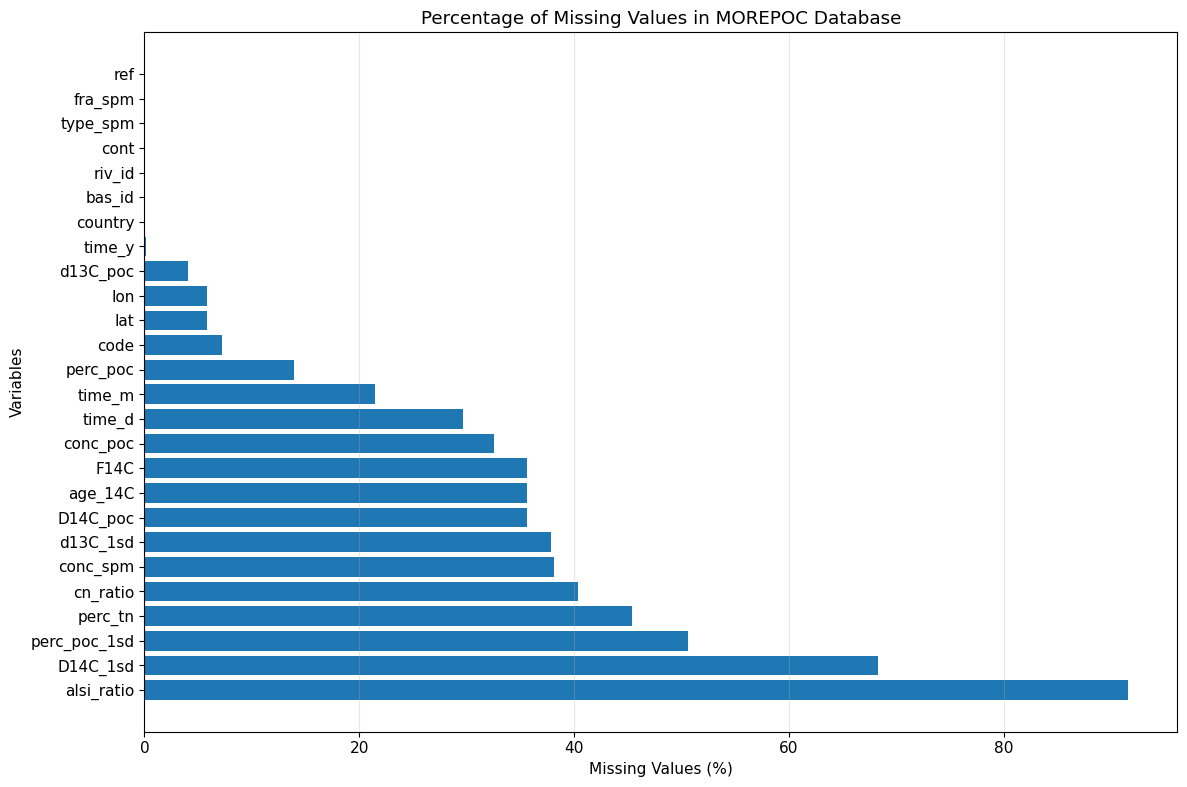

In [16]:
# ============================================================
# Section 4 : Missing Value Visualization
# Objective:
# Visualize the percentage of missing observations for each
# variable in the MOREPOC database.
# ============================================================

plt.figure(figsize=(12,8))

plt.barh(
    missing_summary.index,
    missing_summary["Percentage (%)"]
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Variables")
plt.title("Percentage of Missing Values in MOREPOC Database")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [17]:
# ============================================================
# Section 4 : ML Variable Availability
# Objective:
# Report the availability of variables essential for satellite-
# based machine learning.
# ============================================================

usable_ml = morepoc[
    morepoc["lat"].notna()
    &
    morepoc["lon"].notna()
    &
    morepoc["time_y"].notna()
    &
    morepoc["time_m"].notna()
    &
    morepoc["conc_poc"].notna()
]

print("="*60)
print("Machine Learning Dataset Availability")
print("="*60)

print(f"Total observations      : {len(morepoc):,}")
print(f"Usable ML observations  : {len(usable_ml):,}")
print(f"Percentage usable       : {len(usable_ml)/len(morepoc)*100:.2f}%")

Machine Learning Dataset Availability
Total observations      : 3,547
Usable ML observations  : 2,154
Percentage usable       : 60.73%


## Interpretation

The missing value assessment indicates that the MOREPOC database contains varying levels of completeness across its variables.

Several isotopic and geochemical variables exhibit substantial missing observations and are therefore unsuitable for inclusion in the initial machine learning model. In contrast, the core variables required for satellite-based POC prediction—including latitude, longitude, sampling year, sampling month, and particulate organic carbon concentration—are available for a large proportion of observations.

The final output of this section identifies the subset of observations that satisfy all minimum requirements for machine learning. These observations will form the basis of the global training dataset used in subsequent Landsat reflectance extraction and model development.

# Section 5 — Geographical Distribution of the MOREPOC Database

## Objective

The objective of this section is to investigate the geographical distribution of the MOREPOC database.

A globally representative machine learning model requires observations from diverse climatic regions, continents, and river systems. Therefore, understanding the spatial distribution of the available samples is an essential step before model development.

Specifically, this section aims to:

- Examine the continental distribution of observations.
- Identify countries contributing the largest number of samples.
- Determine the rivers with the highest sampling frequency.
- Evaluate the geographical representativeness of the training dataset.
- Identify potential geographical sampling bias.

The results of this analysis will help assess whether the database adequately represents global river systems for machine learning applications.

In [18]:
# ============================================================
# Section 5 : Continental Distribution
# Objective:
# Calculate the number of observations contributed by each
# continent represented in the MOREPOC database.
# ============================================================

continent_counts = (
    morepoc["cont"]
    .value_counts()
    .sort_values(ascending=False)
)

continent_counts

cont
Asia             1954
North America     793
Africa            291
South America     287
Europe            130
Oceania            91
Name: count, dtype: int64

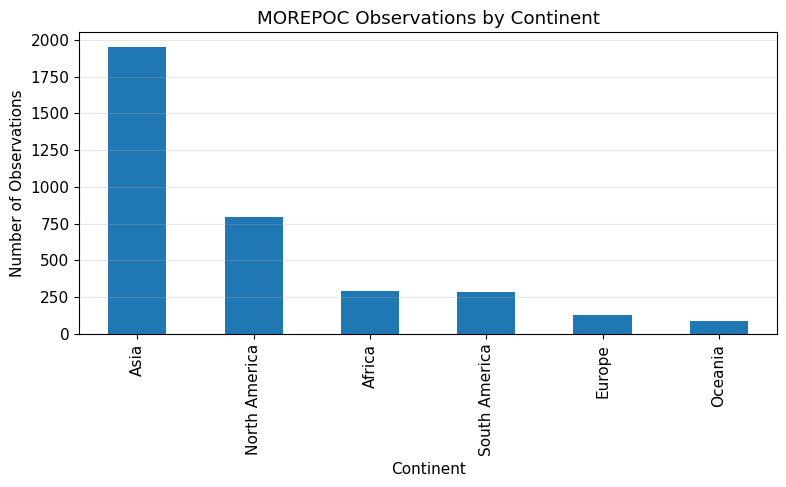

In [19]:
# ============================================================
# Section 5 : Continental Distribution Plot
# Objective:
# Visualize the number of observations contributed by each
# continent.
# ============================================================

plt.figure(figsize=(8,5))

continent_counts.plot(kind="bar")

plt.title("MOREPOC Observations by Continent")
plt.xlabel("Continent")
plt.ylabel("Number of Observations")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [20]:
# ============================================================
# Section 5 : Country Distribution
# Objective:
# Identify the countries contributing the largest number of
# observations to the MOREPOC database.
# ============================================================

country_counts = (
    morepoc["country"]
    .value_counts()
    .head(20)
)

country_counts

country
China                  1038
Russia                  460
USA                     384
Canada                  311
Nepal                   208
Brazil                  179
DR Congo                123
Kenya                   118
USA, Canada              96
Bangladesh               92
India                    66
England                  60
Madre de Dios, Peru      51
New Zealand              46
Papua New Guinea         45
Argentina                36
Songhua, China           28
Japan                    25
Romania                  25
Madagascar               24
Name: count, dtype: int64

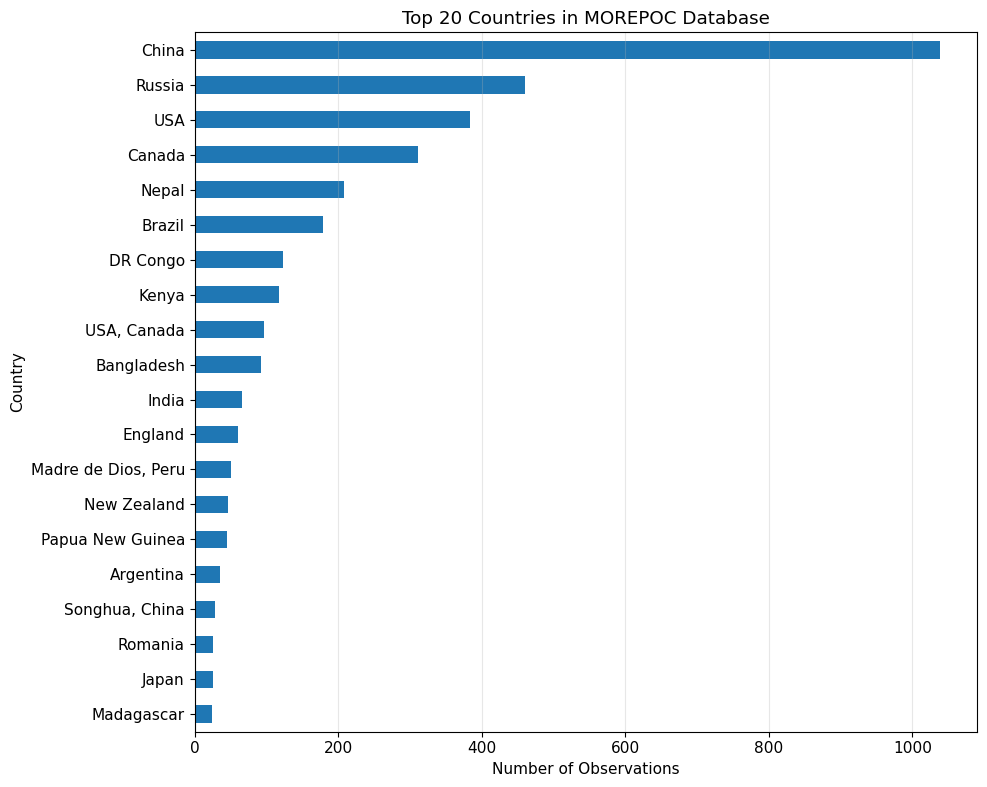

In [21]:
# ============================================================
# Section 5 : Country Distribution Plot
# Objective:
# Visualize the twenty countries contributing the largest
# number of observations.
# ============================================================

plt.figure(figsize=(10,8))

country_counts.sort_values().plot(kind="barh")

plt.title("Top 20 Countries in MOREPOC Database")
plt.xlabel("Number of Observations")
plt.ylabel("Country")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [22]:
# ============================================================
# Section 5 : River Distribution
# Objective:
# Identify rivers with the largest number of observations
# contained in the MOREPOC database.
# ============================================================

river_counts = (
    morepoc["riv_id"]
    .value_counts()
    .head(20)
)

river_counts

riv_id
Mackenzie       162
Narayani        148
Changjiang      131
Kolyma          120
Taiwan-Liwu     117
Amazon          117
Huanghe         116
Lena            111
Yenisei         100
Yukon            96
Ganges           88
Ob'              87
Zhujiang         69
Hudson           65
Mississippi      65
Oubangui         61
Fraser           59
Xijiang          55
Tana             51
Minjiang         51
Name: count, dtype: int64

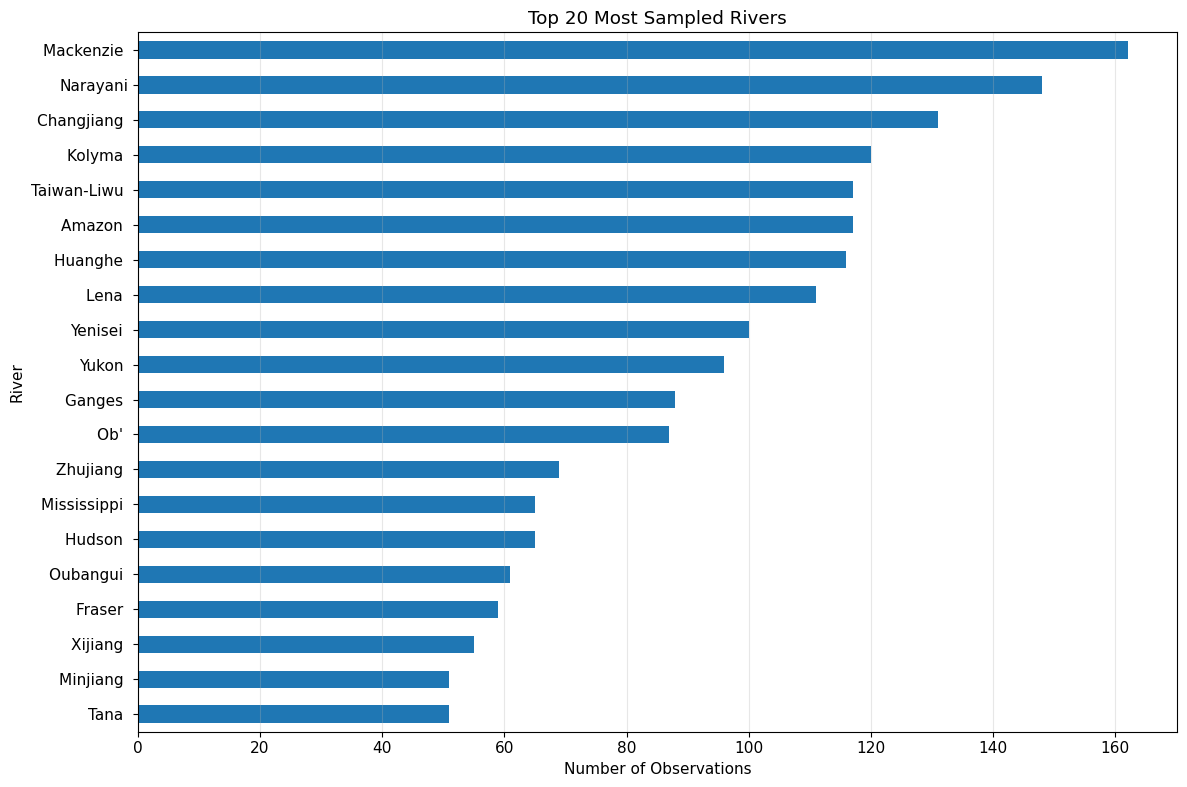

In [23]:
# ============================================================
# Section 5 : River Distribution Plot
# Objective:
# Visualize the twenty most frequently sampled rivers in the
# MOREPOC database.
# ============================================================

plt.figure(figsize=(12,8))

river_counts.sort_values().plot(kind="barh")

plt.title("Top 20 Most Sampled Rivers")
plt.xlabel("Number of Observations")
plt.ylabel("River")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [24]:
# ============================================================
# Section 5 : Indian River Distribution
# Objective:
# Summarize the number of observations available for Indian
# rivers contained in the MOREPOC database.
# ============================================================

india = morepoc[
    morepoc["country"].str.contains(
        "India",
        case=False,
        na=False
    )
]

india["riv_id"].value_counts()

riv_id
Ganges          27
Swarna          19
Brahmaputra     14
Netravati        6
Name: count, dtype: int64

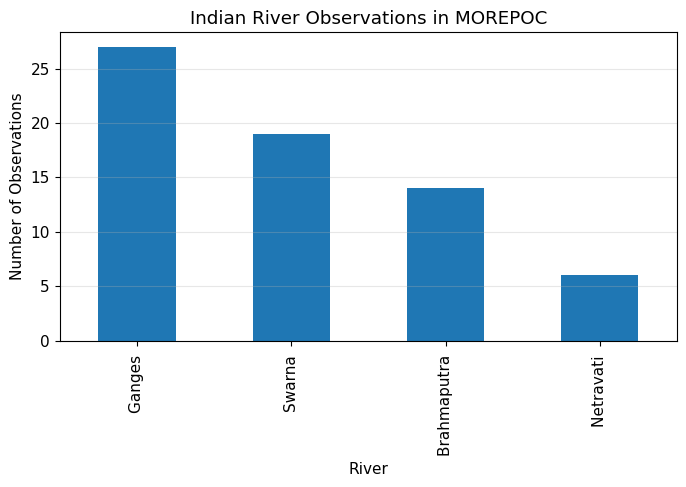

In [25]:
# ============================================================
# Section 5 : Indian River Plot
# Objective:
# Visualize the distribution of observations among Indian
# rivers available in the MOREPOC database.
# ============================================================

india["riv_id"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Indian River Observations in MOREPOC")
plt.xlabel("River")
plt.ylabel("Number of Observations")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## Interpretation

The geographical analysis demonstrates that the MOREPOC database contains observations from multiple continents and a wide range of river systems, making it suitable as a foundation for developing a global machine learning model.

However, the distribution of observations is not geographically uniform. Certain countries and rivers contribute substantially more samples than others, indicating potential spatial sampling bias. Such imbalances should be considered during model development and evaluation.

For India, only four river systems are represented in the current version of the database—Ganges, Brahmaputra, Swarna, and Netravati—with a total of 66 observations. Consequently, the Indian subset is insufficient for training a dedicated national model but provides an independent dataset for evaluating the transferability of a globally trained model.

In [26]:
# ============================================================
# Section 6 : Data Type Conversion
# Objective:
# Convert sampling year, month, and day into numeric format for
# temporal analysis.
# ============================================================

morepoc["time_y"] = pd.to_numeric(morepoc["time_y"], errors="coerce")
morepoc["time_m"] = pd.to_numeric(morepoc["time_m"], errors="coerce")
morepoc["time_d"] = pd.to_numeric(morepoc["time_d"], errors="coerce")

print("Date columns successfully converted to numeric format.")

Date columns successfully converted to numeric format.


In [27]:
# ============================================================
# Section 6 : Temporal Summary
# Objective:
# Determine the earliest and latest sampling years available in
# the MOREPOC database.
# ============================================================

print("="*60)
print("Temporal Coverage")
print("="*60)

print(f"Earliest Sampling Year : {int(morepoc['time_y'].min())}")
print(f"Latest Sampling Year   : {int(morepoc['time_y'].max())}")

print(f"Unique Sampling Years  : {morepoc['time_y'].nunique()}")

Temporal Coverage
Earliest Sampling Year : 1986
Latest Sampling Year   : 2019
Unique Sampling Years  : 31


In [28]:
# ============================================================
# Section 6 : Year-wise Distribution
# Objective:
# Calculate the number of observations collected during each
# sampling year.
# ============================================================

year_counts = (
    morepoc["time_y"]
    .value_counts()
    .sort_index()
)

year_counts

time_y
1986.0     15
1987.0      5
1991.0      1
1992.0      1
1993.0      8
1994.0     79
1995.0     56
1996.0     54
1997.0     17
1998.0     27
1999.0     13
2000.0     23
2001.0     34
2002.0     37
2003.0     69
2004.0    168
2005.0    242
2006.0     79
2007.0    109
2008.0    142
2009.0    261
2010.0    261
2011.0    155
2012.0    106
2013.0    212
2014.0    130
2015.0    194
2016.0    173
2017.0    135
2018.0     85
2019.0     44
Name: count, dtype: int64

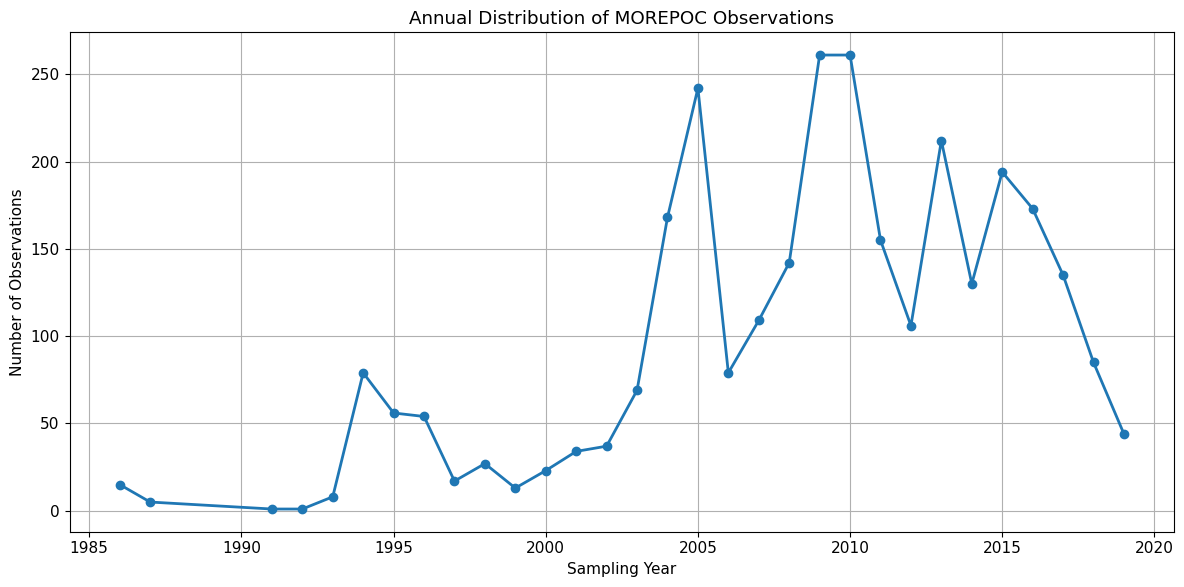

In [29]:
# ============================================================
# Section 6 : Year-wise Distribution Plot
# Objective:
# Visualize the temporal distribution of observations across
# sampling years.
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o",
    linewidth=2
)

plt.title("Annual Distribution of MOREPOC Observations")
plt.xlabel("Sampling Year")
plt.ylabel("Number of Observations")

plt.grid(True)

plt.tight_layout()

plt.show()

In [30]:
# ============================================================
# Section 6 : Monthly Distribution
# Objective:
# Calculate the number of observations collected during each
# month of the year.
# ============================================================

month_counts = (
    morepoc["time_m"]
    .value_counts()
    .sort_index()
)

month_counts

time_m
1.0     184
2.0     110
3.0     233
4.0     156
5.0     148
6.0     497
7.0     409
8.0     352
9.0     251
10.0    208
11.0    134
12.0     68
Name: count, dtype: int64

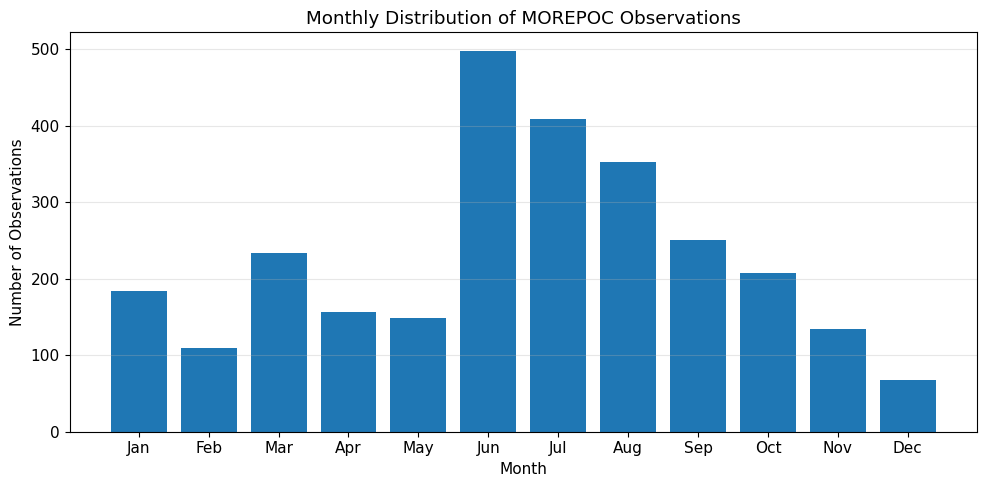

In [31]:
# ============================================================
# Section 6 : Monthly Distribution Plot
# Objective:
# Visualize seasonal sampling patterns within the MOREPOC
# database.
# ============================================================

month_labels = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

plt.figure(figsize=(10,5))

plt.bar(month_labels, month_counts.values)

plt.title("Monthly Distribution of MOREPOC Observations")
plt.xlabel("Month")
plt.ylabel("Number of Observations")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [32]:
# ============================================================
# Section 6 : Landsat Mission Coverage
# Objective:
# Summarize the Landsat missions corresponding to the temporal
# coverage of the MOREPOC observations.
# ============================================================

landsat_summary = pd.DataFrame({
    "Mission":[
        "Landsat 5 TM",
        "Landsat 7 ETM+",
        "Landsat 8 OLI",
        "Landsat 9 OLI-2"
    ],
    "Operational Period":[
        "1984–2013",
        "1999–Present",
        "2013–Present",
        "2021–Present"
    ]
})

landsat_summary

,Mission,Operational Period
0,Landsat 5 TM,1984–2013
1,Landsat 7 ETM+,1999–Present
2,Landsat 8 OLI,2013–Present
3,Landsat 9 OLI-2,2021–Present


In [33]:
# ============================================================
# Section 6 : Indian Temporal Distribution
# Objective:
# Examine the sampling years available for Indian river
# observations.
# ============================================================

india = morepoc[
    morepoc["country"].str.contains("India", case=False, na=False)
]

india["time_y"].value_counts().sort_index()

time_y
1997.0     2
1999.0     6
2001.0    28
2004.0     2
2005.0     3
2013.0    25
Name: count, dtype: int64

## Interpretation

The temporal analysis demonstrates that the MOREPOC database spans multiple decades, providing extensive temporal coverage for global riverine POC observations. This broad sampling period overlaps with the operational lifetimes of several Landsat missions, making the dataset well suited for satellite-based machine learning applications.

The annual distribution indicates that observations are not uniformly distributed across time, with certain years contributing substantially more samples than others. Similarly, monthly sampling patterns reveal seasonal biases that should be considered when interpreting model performance.

The overlap between the MOREPOC sampling period and Landsat 5, Landsat 7, Landsat 8, and Landsat 9 missions enables automatic selection of the most appropriate satellite imagery during the reflectance extraction stage. This temporal compatibility forms the basis for constructing a consistent global training dataset for machine learning.

# Section 7 — Statistical Analysis of Particulate Organic Carbon (POC)

## Objective

The objective of this section is to investigate the statistical characteristics of particulate organic carbon (POC) concentrations contained in the MOREPOC database.

POC concentration is the response (target) variable for the machine learning model developed in this research. Therefore, understanding its statistical distribution, central tendency, variability, and potential outliers is essential before model training.

Specifically, this section aims to:

- Examine the statistical properties of POC concentration.
- Identify minimum, maximum, mean, and median values.
- Evaluate the distribution of observations.
- Detect extreme values and potential outliers.
- Assess whether transformation of the target variable may be required during machine learning.

The results obtained in this section provide important insights into the complexity of predicting riverine particulate organic carbon using satellite-derived reflectance.

In [34]:
# ============================================================
# Section 7 : POC Summary Statistics
# Objective:
# Calculate descriptive statistics for particulate organic
# carbon (POC) concentrations.
# ============================================================

poc = morepoc["conc_poc"].dropna()

print("=" * 60)
print("POC CONCENTRATION SUMMARY")
print("=" * 60)

print(f"Number of Samples : {len(poc):,}")
print(f"Mean              : {poc.mean():.3f}")
print(f"Median            : {poc.median():.3f}")
print(f"Minimum           : {poc.min():.3f}")
print(f"Maximum           : {poc.max():.3f}")
print(f"Standard Deviation: {poc.std():.3f}")

POC CONCENTRATION SUMMARY
Number of Samples : 2,393
Mean              : 8.277
Median            : 1.400
Minimum           : 0.000
Maximum           : 943.000
Standard Deviation: 34.953


In [35]:
# ============================================================
# Section 7 : Detailed Statistical Summary
# Objective:
# Generate descriptive statistics for particulate organic
# carbon concentrations.
# ============================================================

poc.describe()

count    2393.000000
mean        8.277351
std        34.952707
min         0.000000
25%         0.600000
50%         1.400000
75%         4.100000
max       943.000000
Name: conc_poc, dtype: float64

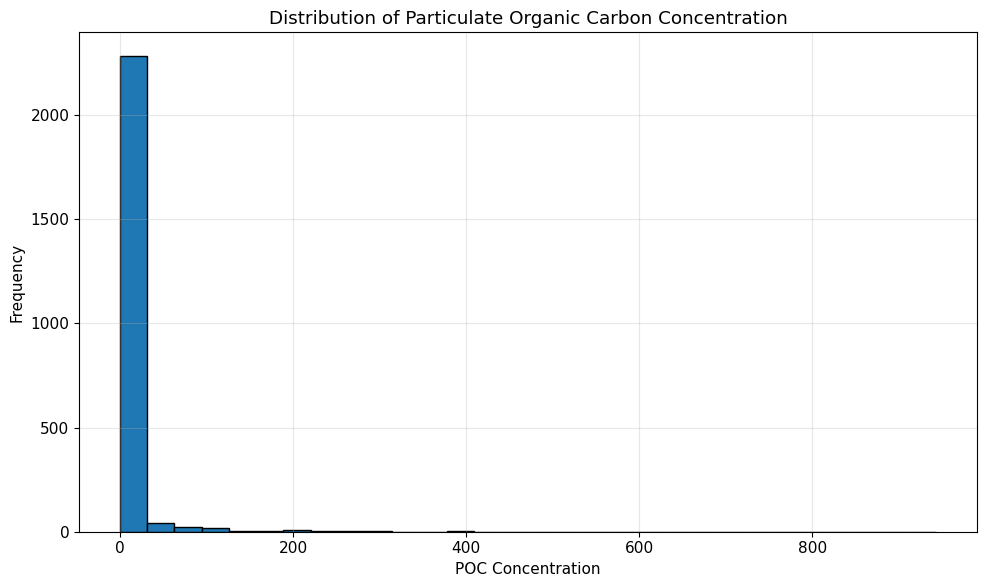

In [36]:
# ============================================================
# Section 7 : POC Distribution
# Objective:
# Visualize the frequency distribution of particulate organic
# carbon concentrations.
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    poc,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Particulate Organic Carbon Concentration")
plt.xlabel("POC Concentration")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

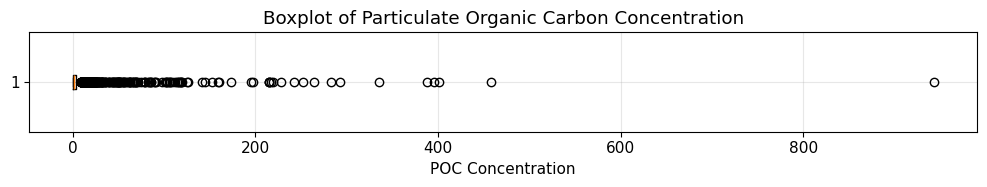

In [37]:
# ============================================================
# Section 7 : Boxplot of POC Concentration
# Objective:
# Identify extreme values and potential outliers in particulate
# organic carbon concentration.
# ============================================================

plt.figure(figsize=(10,2))

plt.boxplot(
    poc,
    vert=False
)

plt.title("Boxplot of Particulate Organic Carbon Concentration")

plt.xlabel("POC Concentration")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [38]:
# ============================================================
# Section 7 : Percentile Analysis
# Objective:
# Calculate important percentiles of particulate organic carbon
# concentration.
# ============================================================

percentiles = poc.quantile(
    [0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]
)

percentiles

0.01      0.100
0.05      0.200
0.10      0.300
0.25      0.600
0.50      1.400
0.75      4.100
0.90     11.680
0.95     27.280
0.99    142.256
Name: conc_poc, dtype: float64

In [39]:
# ============================================================
# Section 7 : Distribution Shape
# Objective:
# Evaluate the symmetry and peakedness of the particulate
# organic carbon concentration distribution.
# ============================================================

print("Skewness :", poc.skew())
print("Kurtosis :", poc.kurt())

Skewness : 12.974794866205995
Kurtosis : 257.05391376109964


In [40]:
if poc.skew() > 1:
    print("Recommendation: Consider log-transforming the target variable before model training.")
else:
    print("Recommendation: Log transformation is likely unnecessary.")

Recommendation: Consider log-transforming the target variable before model training.


In [41]:
# ============================================================
# Section 7 : Missing Target Variable
# Objective:
# Determine the number of observations lacking particulate
# organic carbon concentration measurements.
# ============================================================

missing_poc = morepoc["conc_poc"].isnull().sum()

print("=" * 60)
print("Missing POC Values")
print("=" * 60)

print(f"Missing observations : {missing_poc}")
print(f"Available observations : {len(poc):,}")

Missing POC Values
Missing observations : 1154
Available observations : 2,393


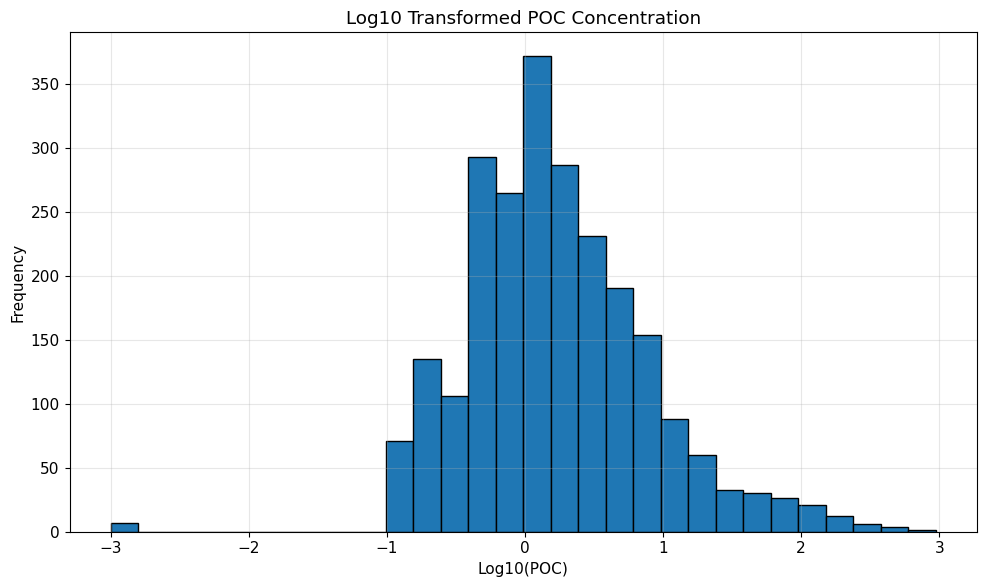

In [42]:
# ============================================================
# Section 7 : Log Transformation Assessment
# Objective:
# Evaluate whether logarithmic transformation of particulate
# organic carbon concentration may improve machine learning.
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    np.log10(poc + 0.001),
    bins=30,
    edgecolor="black"
)

plt.title("Log10 Transformed POC Concentration")

plt.xlabel("Log10(POC)")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Interpretation

The statistical analysis indicates that particulate organic carbon (POC) concentrations exhibit substantial variability across the global river systems represented in the MOREPOC database.

The histogram and boxplot reveal whether the target variable follows a normal distribution or exhibits skewness and extreme observations. Environmental variables such as POC commonly display positively skewed distributions due to the occurrence of high-concentration events during floods and periods of elevated sediment transport.

The calculated skewness and kurtosis provide quantitative measures of the distribution shape. If strong positive skewness is observed, logarithmic transformation may improve model performance by reducing the influence of extreme values and stabilizing variance.

The results of this section will guide the selection of the target variable representation during machine learning model development.

# Section 8 — Spatial Distribution of Global POC Sampling Locations

## Objective

The objective of this section is to investigate the geographical distribution of all sampling locations contained in the MOREPOC database.

Understanding the spatial coverage of the training observations is essential for evaluating the representativeness of the dataset. A globally distributed dataset generally produces a more robust and transferable machine learning model than one concentrated within a few geographical regions.

Specifically, this section aims to:

- Examine the global spatial distribution of sampling locations.
- Identify geographical clustering of observations.
- Detect regions with sparse or missing sampling coverage.
- Generate a geospatial dataset for subsequent mapping and visualization.
- Evaluate whether the database provides sufficient global representation for machine learning model development.

The outputs generated in this section will form the basis for spatial visualization and geographical interpretation of the MOREPOC database.

In [43]:
# ============================================================
# Section 8 : Extract Valid Sampling Locations
# Objective:
# Select observations containing valid latitude and longitude
# coordinates for spatial analysis.
# ============================================================

spatial_data = morepoc.dropna(subset=["lat", "lon"]).copy()

print("=" * 60)
print("Spatial Dataset Summary")
print("=" * 60)

print(f"Total observations           : {len(morepoc):,}")
print(f"Valid coordinate observations: {len(spatial_data):,}")
print(f"Removed observations         : {len(morepoc)-len(spatial_data):,}")

Spatial Dataset Summary
Total observations           : 3,547
Valid coordinate observations: 3,339
Removed observations         : 208


In [44]:
# ============================================================
# Section 8 : Create GeoDataFrame
# Objective:
# Convert latitude and longitude coordinates into a GeoPandas
# GeoDataFrame for spatial analysis.
# ============================================================

gdf = gpd.GeoDataFrame(
    spatial_data,
    geometry=gpd.points_from_xy(
        spatial_data["lon"],
        spatial_data["lat"]
    ),
    crs="EPSG:4326"
)

print(gdf.head())

               bas_id               riv_id country    cont        code  \
0  Athi-Galana-Sabaki  Athi-Galana-Sabaki    Kenya  Africa     S4 Athi   
1  Athi-Galana-Sabaki  Athi-Galana-Sabaki    Kenya  Africa   S12 Tsavo   
2  Athi-Galana-Sabaki  Athi-Galana-Sabaki    Kenya  Africa    S13 Athi   
3  Athi-Galana-Sabaki  Athi-Galana-Sabaki    Kenya  Africa  S19 Galana   
4  Athi-Galana-Sabaki  Athi-Galana-Sabaki    Kenya  Africa     S1 Athi   

   time_m  time_d  time_y   lat    lon  ... d13C_1sd D14C_poc D14C_1sd  \
0     8.0    30.0  2011.0 -1.61  37.79  ...      NaN    -28.9      < 7   
1     9.0     4.0  2011.0 -2.99  38.46  ...      NaN    -52.8     < 7    
2     9.0     5.0  2011.0 -2.94  38.49  ...      NaN     24.3     < 7    
3     9.0     8.0  2011.0 -3.14  39.85  ...      NaN    -94.2     < 7    
4    11.0     1.0  2011.0 -1.08  37.25  ...      NaN    -90.4     < 7    

   age_14C   F14C perc_tn  cn_ratio alsi_ratio                    ref  \
0    175.9  0.978     NaN       NaN  

In [45]:
# ============================================================
# Section 8 : Coordinate Extent
# Objective:
# Determine the geographical extent of the sampling locations.
# ============================================================

print("=" * 60)
print("Coordinate Extent")
print("=" * 60)

print(f"Latitude Range : {gdf['lat'].min():.2f} to {gdf['lat'].max():.2f}")

print(f"Longitude Range: {gdf['lon'].min():.2f} to {gdf['lon'].max():.2f}")

Coordinate Extent
Latitude Range : -43.49 to 73.35
Longitude Range: -162.88 to 178.30


In [46]:
world = gpd.read_file(
    r"G:\OCR\NaturalEarth\ne_110m_admin_0_sovereignty.shp"
)

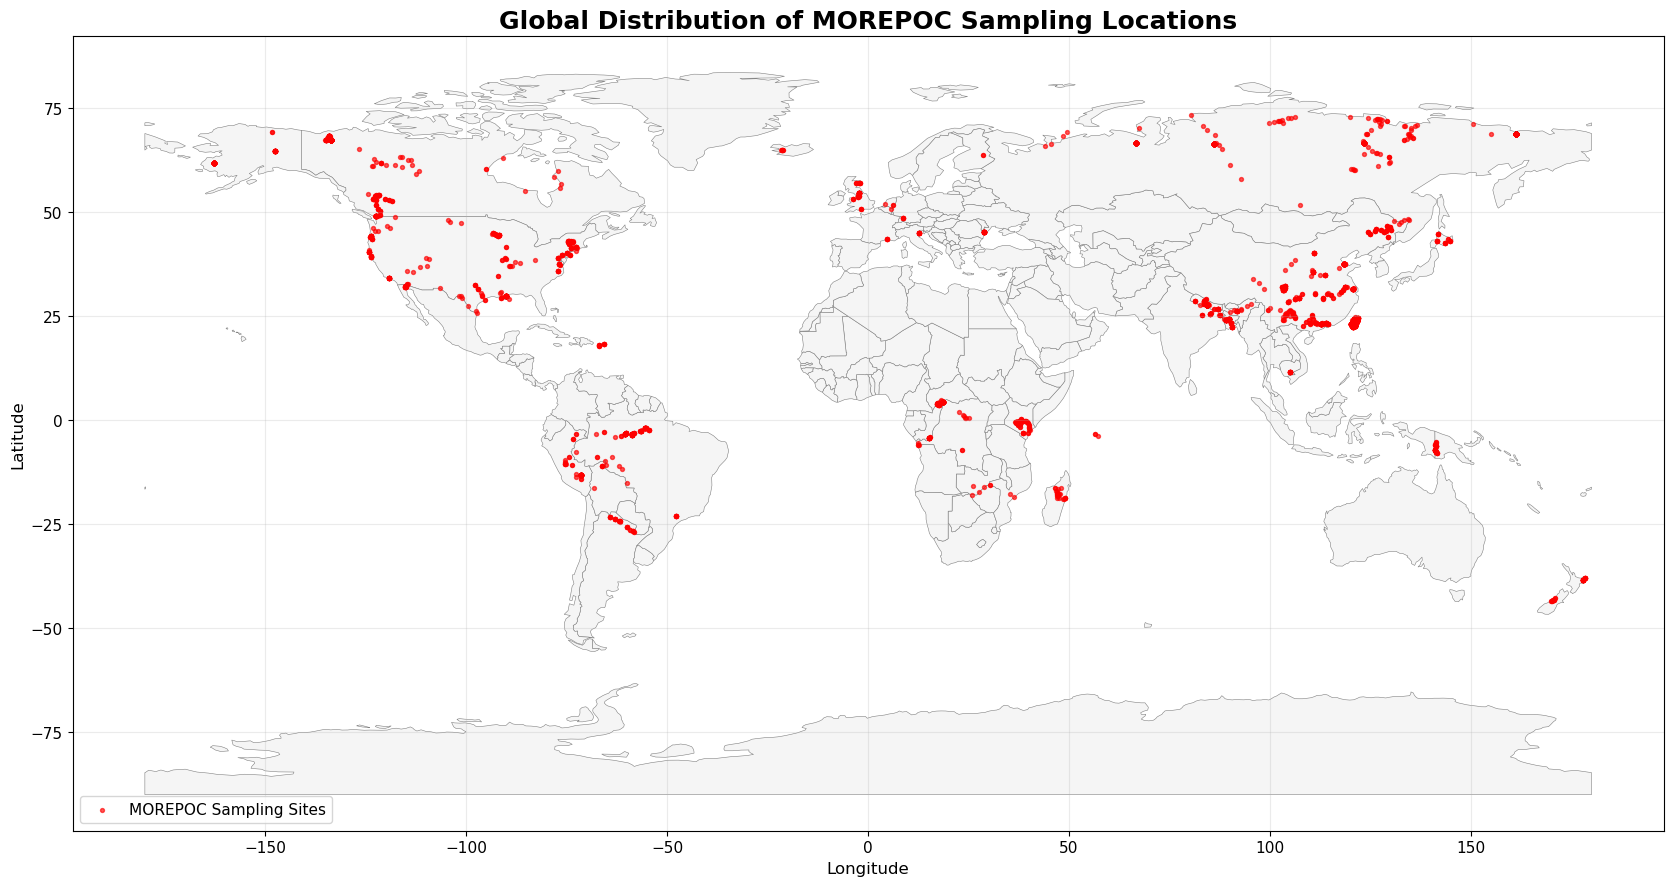

In [47]:
# ============================================================
# Section 8 : Global Distribution of MOREPOC Sampling Locations
# Objective:
# Visualize the global distribution of MOREPOC sampling
# locations using Natural Earth country boundaries.
# ============================================================

# Load Natural Earth world boundaries
world = gpd.read_file(
    r"G:\OCR\NaturalEarth\ne_110m_admin_0_sovereignty.shp"
)

# Create figure
fig, ax = plt.subplots(figsize=(18,9))

# Draw countries
world.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="gray",
    linewidth=0.4
)

# Draw sampling points
gdf.plot(
    ax=ax,
    color="red",
    markersize=8,
    alpha=0.65,
    label="MOREPOC Sampling Sites"
)

# Formatting
ax.set_title(
    "Global Distribution of MOREPOC Sampling Locations",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

ax.legend(loc="lower left")

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

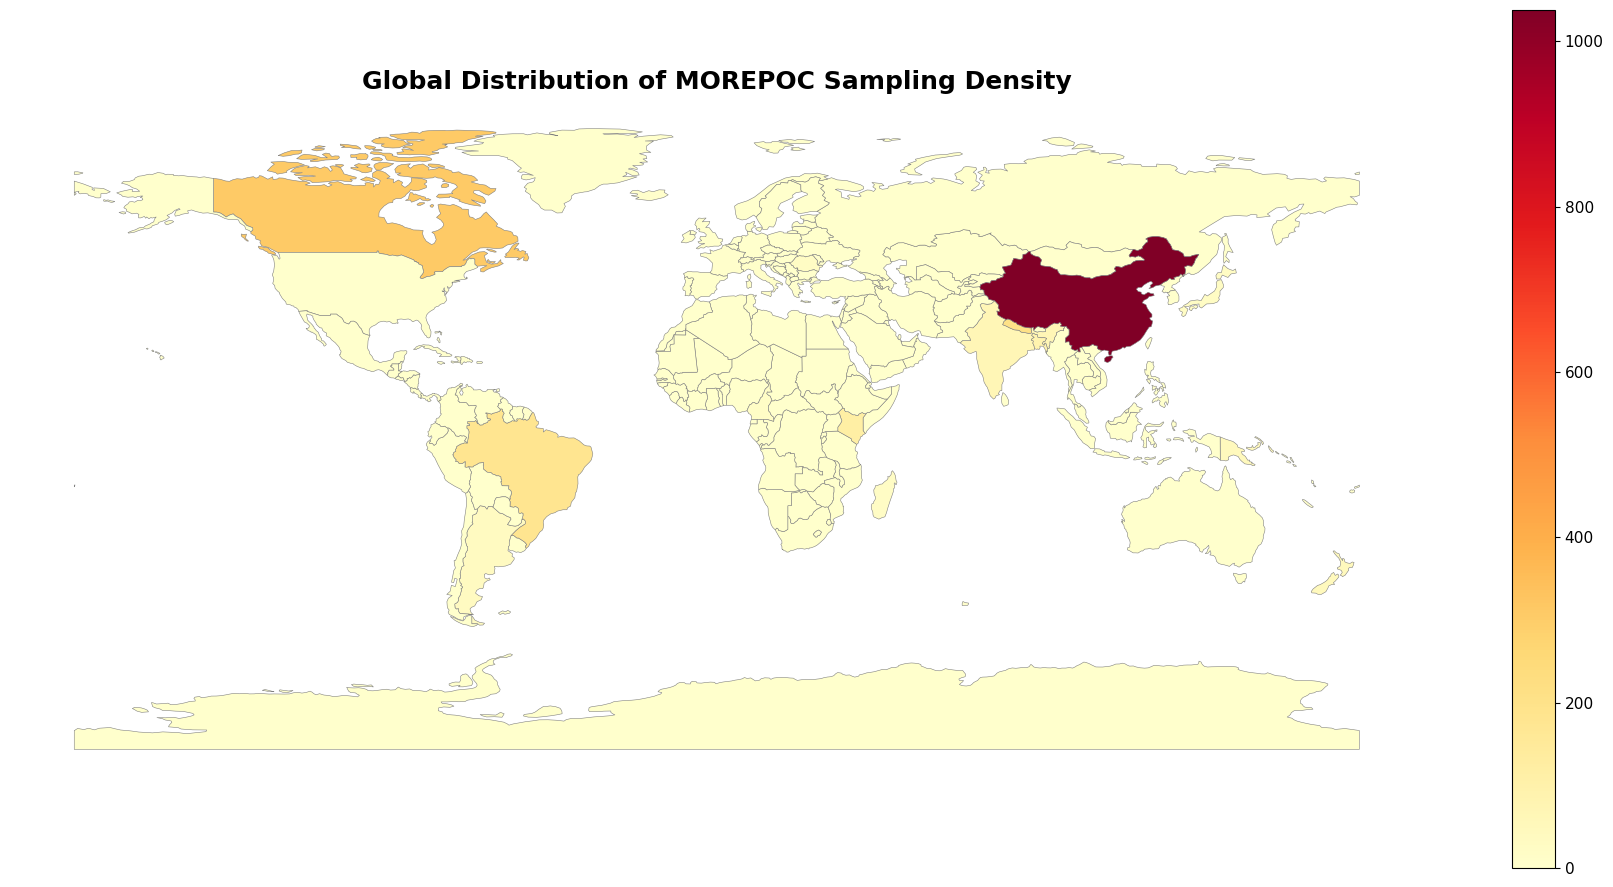

In [48]:
# ============================================================
# Section 8 : Global Sampling Density
# Objective:
# Create a publication-quality choropleth map showing the number
# of MOREPOC observations available in each country.
# ============================================================

country_summary = (
    morepoc.groupby("country")
    .size()
    .reset_index(name="Samples")
)

# ------------------------------------------------------------
# Standardize country names for merging
# ------------------------------------------------------------

country_summary["country"] = country_summary["country"].replace({

    "United States":"United States of America",
    "Russia":"Russian Federation",
    "South Korea":"Republic of Korea",
    "North Korea":"Dem. Rep. Korea",
    "Iran":"Iran",
    "Vietnam":"Vietnam",
    "Czech Republic":"Czechia"

})

# ------------------------------------------------------------
# Merge with Natural Earth
# ------------------------------------------------------------

world_density = world.merge(
    country_summary,
    left_on="SOVEREIGNT",
    right_on="country",
    how="left"
)

world_density["Samples"] = world_density["Samples"].fillna(0)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(18,9))

world_density.plot(
    column="Samples",
    cmap="YlOrRd",
    linewidth=0.4,
    edgecolor="gray",
    legend=True,
    ax=ax,
    missing_kwds={
        "color":"lightgray",
        "label":"No Samples"
    }
)

ax.set_title(
    "Global Distribution of MOREPOC Sampling Density",
    fontsize=18,
    fontweight="bold"
)

ax.set_axis_off()

plt.tight_layout()

plt.show()

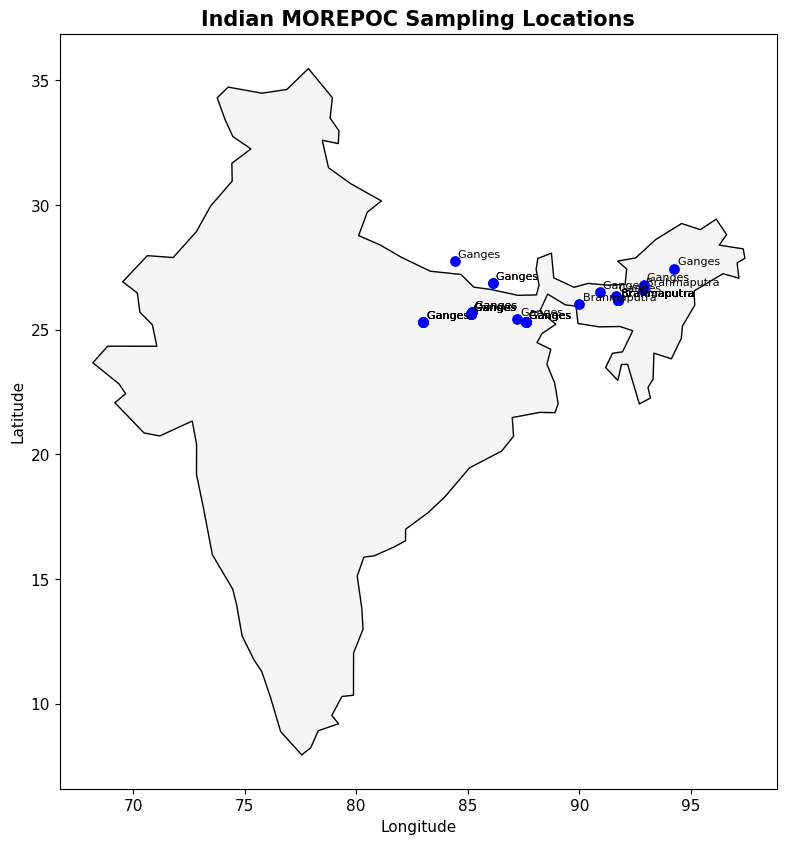

In [49]:
# ============================================================
# Section 8 : Indian MOREPOC Sampling Locations
# Objective:
# Visualize Indian river sampling locations contained in the
# MOREPOC database.
# ============================================================

india_map = world[
    world["SOVEREIGNT"]=="India"
]

india_samples = gdf[
    gdf["country"]=="India"
]

fig, ax = plt.subplots(figsize=(8,10))

india_map.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="black"
)

india_samples.plot(
    ax=ax,
    color="blue",
    markersize=45
)

for _, row in india_samples.iterrows():
    ax.text(
        row.geometry.x + 0.15,
        row.geometry.y + 0.15,
        row["riv_id"],
        fontsize=8
    )

ax.set_title(
    "Indian MOREPOC Sampling Locations",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()

plt.show()

In [50]:
# ============================================================
# Section 8 : Continental Coverage Summary
# Objective:
# Summarize the number of sampling locations within each
# continent.
# ============================================================

continent_summary = (
    gdf.groupby("cont")
       .size()
       .reset_index(name="Number of Samples")
       .sort_values(
           "Number of Samples",
           ascending=False
       )
)

continent_summary

,cont,Number of Samples
1,Asia,1854
3,North America,716
5,South America,283
0,Africa,266
2,Europe,130
4,Oceania,90


In [51]:
# ============================================================
# Section 8 : Export Sampling Locations
# Objective:
# Save the spatial sampling locations for future GIS analysis.
# ============================================================

output_path = "MOREPOC_Global_Sampling_Locations.geojson"

gdf.to_file(
    output_path,
    driver="GeoJSON"
)

print("GeoJSON saved successfully.")

print(output_path)

GeoJSON saved successfully.
MOREPOC_Global_Sampling_Locations.geojson


## Interpretation

The spatial analysis demonstrates that the MOREPOC database contains observations distributed across multiple continents and river systems. The geographical extent confirms that the database provides broad global coverage, although the density of observations varies considerably between regions.

Several regions contain dense clusters of sampling locations, whereas other areas exhibit relatively sparse sampling coverage. Such geographical imbalance is common in environmental databases due to differences in research activity, accessibility, and monitoring programs.

The generated GeoDataFrame provides the spatial foundation for subsequent analyses and can be integrated with satellite imagery, watershed boundaries, and river networks during Landsat reflectance extraction and machine learning model development.

# Section 9 — Analysis of Indian MOREPOC Observations

## Objective

The objective of this section is to isolate and examine all Indian river observations available in the MOREPOC database.

Although the machine learning model will be trained using globally distributed observations, the Indian samples will be reserved as an independent dataset for evaluating the model's ability to generalize to Indian river systems.

Specifically, this section aims to:

- Extract all observations collected within India.
- Identify the rivers represented in the database.
- Summarize temporal coverage.
- Examine the spatial distribution of Indian sampling sites.
- Generate a clean dataset for subsequent Landsat reflectance extraction.

This dataset will serve as the primary validation dataset for assessing the performance of the global Random Forest model over Indian rivers.

In [52]:
# ============================================================
# Section 9 : Extract Indian MOREPOC Dataset
# Objective:
# Select all observations collected within India.
# ============================================================

india = morepoc[
    morepoc["country"].str.contains(
        "India",
        case=False,
        na=False
    )
].copy()

print("=" * 60)
print("Indian MOREPOC Dataset")
print("=" * 60)

print(f"Number of observations : {len(india)}")
print(f"Number of rivers       : {india['riv_id'].nunique()}")

Indian MOREPOC Dataset
Number of observations : 66
Number of rivers       : 4


In [53]:
# ============================================================
# Section 9 : River-wise Sample Distribution
# Objective:
# Determine the number of observations available for each
# Indian river.
# ============================================================

river_summary = (
    india.groupby("riv_id")
    .size()
    .reset_index(name="Samples")
    .sort_values(
        "Samples",
        ascending=False
    )
)

river_summary

,riv_id,Samples
1,Ganges,27
3,Swarna,19
0,Brahmaputra,14
2,Netravati,6


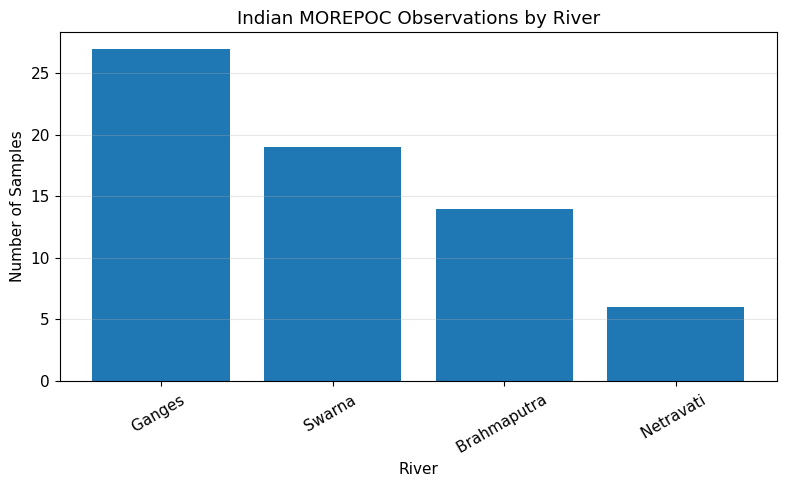

In [54]:
# ============================================================
# Section 9 : Indian River Sample Counts
# Objective:
# Visualize the number of MOREPOC observations available for
# each Indian river.
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    river_summary["riv_id"],
    river_summary["Samples"]
)

plt.title("Indian MOREPOC Observations by River")

plt.xlabel("River")

plt.ylabel("Number of Samples")

plt.xticks(rotation=30)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [55]:
# ============================================================
# Section 9 : Observation Years
# Objective:
# Examine the temporal coverage of Indian MOREPOC samples.
# ============================================================

india["time_y"] = pd.to_numeric(
    india["time_y"],
    errors="coerce"
)

india["time_y"].describe()

count      66.000000
mean     2005.515152
std         6.046595
min      1997.000000
25%      2001.000000
50%      2001.000000
75%      2013.000000
max      2013.000000
Name: time_y, dtype: float64

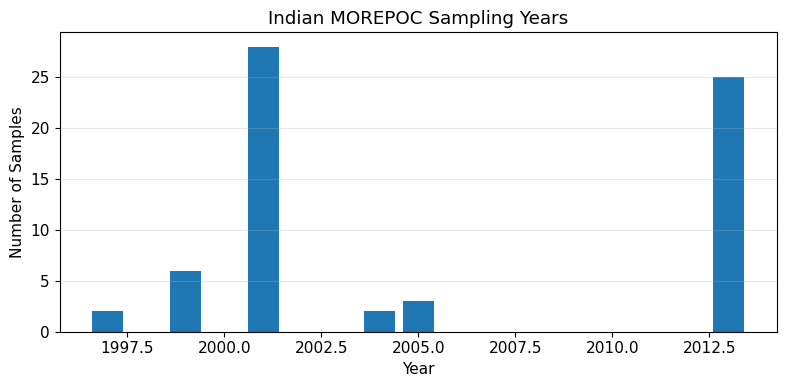

In [56]:
# ============================================================
# Section 9 : Sampling Years
# Objective:
# Visualize the number of observations collected each year.
# ============================================================

year_counts = (
    india["time_y"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,4))

plt.bar(
    year_counts.index.astype(int),
    year_counts.values
)

plt.title("Indian MOREPOC Sampling Years")

plt.xlabel("Year")

plt.ylabel("Number of Samples")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [57]:
# ============================================================
# Section 9 : Indian GeoDataFrame
# Objective:
# Create a GeoDataFrame containing Indian sampling locations.
# ============================================================

india_gdf = gpd.GeoDataFrame(
    india,
    geometry=gpd.points_from_xy(
        india["lon"],
        india["lat"]
    ),
    crs="EPSG:4326"
)

print(india_gdf.head())

          bas_id        riv_id country  cont                       code  \
293  Brahmaputra  Brahmaputra    India  Asia  BR 2 Brahmaputra-Guwahati   
294  Brahmaputra  Brahmaputra    India  Asia  BR 3 Brahmaputra-Guwahati   
295  Brahmaputra  Brahmaputra    India  Asia  BR 4 Brahmaputra-Guwahati   
296  Brahmaputra  Brahmaputra    India  Asia  BR 6 Brahmaputra-Guwahati   
297  Brahmaputra  Brahmaputra    India  Asia  BR 7 Brahmaputra-Guwahati   

     time_m  time_d  time_y    lat    lon  ... d13C_1sd D14C_poc D14C_1sd  \
293    10.0    25.0  1999.0  26.19  91.74  ...     0.25      NaN      NaN   
294    10.0    25.0  1999.0  26.19  91.74  ...     0.25      NaN      NaN   
295    10.0    25.0  1999.0  26.19  91.74  ...     0.25      NaN      NaN   
296    10.0    25.0  1999.0  26.19  91.74  ...     0.25      NaN      NaN   
297    10.0    25.0  1999.0  26.19  91.74  ...     0.25      NaN      NaN   

     age_14C  F14C perc_tn  cn_ratio alsi_ratio                 ref  \
293      NaN   

In [58]:
# ============================================================
# Section 9 : Export Indian Dataset
# Objective:
# Save the cleaned Indian MOREPOC observations for later
# Landsat reflectance extraction.
# ============================================================

india_gdf.to_file(
    "Indian_MOREPOC.geojson",
    driver="GeoJSON"
)

india.to_csv(
    "Indian_MOREPOC.csv",
    index=False
)

print("Indian dataset exported successfully.")

Indian dataset exported successfully.


## Interpretation

The MOREPOC database contains 66 observations collected from four Indian river systems: the Ganges, Brahmaputra, Swarna, and Netravati.

These observations represent an independent validation dataset and will not be used during model training. Instead, they will be reserved for evaluating the predictive capability of the globally trained Random Forest model over Indian rivers.

The exported GeoJSON and CSV files will be used in the next stage of the workflow, where Landsat surface reflectance values corresponding to each sampling location and date will be extracted using Google Earth Engine.

# Section 10 — Preparing Sampling Dates for Landsat Reflectance Extraction

## Objective

The objective of this section is to prepare standardized observation dates for every MOREPOC sampling location.

Satellite image retrieval requires a valid observation date. The MOREPOC database stores the sampling year, month, and day in separate columns, and some observations have missing values.

This section aims to:

- Convert year, month, and day into numeric format.
- Identify incomplete dates.
- Create standardized sampling dates.
- Handle missing month/day values using predefined assumptions.
- Produce a clean date field compatible with Google Earth Engine.
- Generate quality-control statistics for the cleaned dates.

The output of this section will be the primary temporal information used during Landsat surface reflectance extraction.

In [59]:
# ============================================================
# Section 10 : Examine Sampling Date Information
# Objective:
# Inspect year, month and day information stored in MOREPOC.
# ============================================================

print("=" * 60)
print("Date Information")
print("=" * 60)

display(
    india[
        [
            "time_y",
            "time_m",
            "time_d"
        ]
    ].head(10)
)

print()

print(india[["time_y","time_m","time_d"]].info())

Date Information


,time_y,time_m,time_d
293,1999.0,10.0,25.0
294,1999.0,10.0,25.0
295,1999.0,10.0,25.0
296,1999.0,10.0,25.0
297,1999.0,10.0,25.0
298,1999.0,10.0,25.0
299,2001.0,7.0,26.0
300,2001.0,7.0,26.0
301,2001.0,7.0,26.0
302,2001.0,7.0,26.0



<class 'pandas.DataFrame'>
Index: 66 entries, 293 to 1391
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time_y  66 non-null     float64
 1   time_m  66 non-null     float64
 2   time_d  64 non-null     float64
dtypes: float64(3)
memory usage: 2.1 KB
None


In [60]:
# ============================================================
# Section 10 : Convert Date Fields
# Objective:
# Convert year, month and day into numeric variables.
# ============================================================

india["time_y"] = pd.to_numeric(
    india["time_y"],
    errors="coerce"
)

india["time_m"] = pd.to_numeric(
    india["time_m"],
    errors="coerce"
)

india["time_d"] = pd.to_numeric(
    india["time_d"],
    errors="coerce"
)

india[
    [
        "time_y",
        "time_m",
        "time_d"
    ]
].dtypes

time_y    float64
time_m    float64
time_d    float64
dtype: object

In [61]:
# ============================================================
# Section 10 : Missing Date Summary
# Objective:
# Count missing values in year, month and day.
# ============================================================

date_missing = india[
    [
        "time_y",
        "time_m",
        "time_d"
    ]
].isnull().sum()

print(date_missing)

time_y    0
time_m    0
time_d    2
dtype: int64


In [62]:
# ============================================================
# Section 10 : Fill Missing Month and Day
# Objective:
# Replace missing month/day values with standard assumptions.
# ============================================================

india["time_m"] = india["time_m"].fillna(7)

india["time_d"] = india["time_d"].fillna(15)

In [63]:
# ============================================================
# Section 10 : Create Observation Date
# Objective:
# Combine year, month and day into a single observation date.
# ============================================================

india["sample_date"] = pd.to_datetime(
    dict(
        year=india["time_y"].astype(int),
        month=india["time_m"].astype(int),
        day=india["time_d"].astype(int)
    )
)

display(
    india[
        [
            "time_y",
            "time_m",
            "time_d",
            "sample_date"
        ]
    ].head(10)
)

,time_y,time_m,time_d,sample_date
293,1999.0,10.0,25.0,1999-10-25
294,1999.0,10.0,25.0,1999-10-25
295,1999.0,10.0,25.0,1999-10-25
296,1999.0,10.0,25.0,1999-10-25
297,1999.0,10.0,25.0,1999-10-25
298,1999.0,10.0,25.0,1999-10-25
299,2001.0,7.0,26.0,2001-07-26
300,2001.0,7.0,26.0,2001-07-26
301,2001.0,7.0,26.0,2001-07-26
302,2001.0,7.0,26.0,2001-07-26


In [64]:
# ============================================================
# Section 10 : Observation Period
# Objective:
# Determine the temporal extent of Indian observations.
# ============================================================

print("=" * 60)

print("Observation Period")

print("=" * 60)

print("Earliest Observation")

print(india["sample_date"].min())

print()

print("Latest Observation")

print(india["sample_date"].max())

Observation Period
Earliest Observation
1997-03-15 00:00:00

Latest Observation
2013-09-30 00:00:00


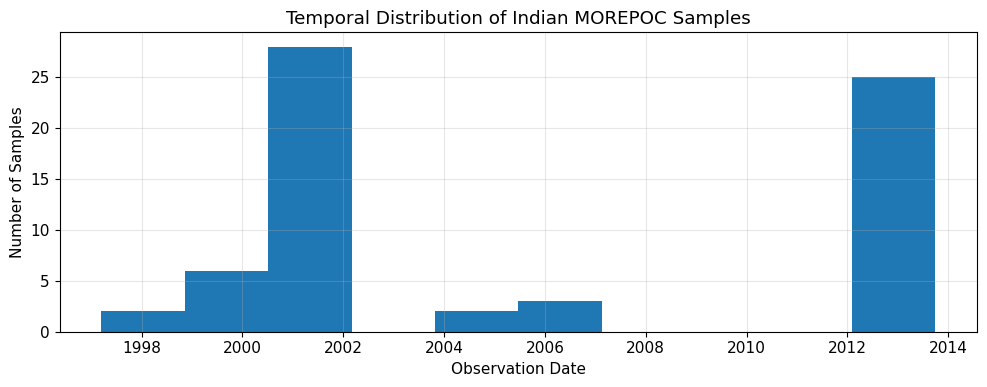

In [65]:
# ============================================================
# Section 10 : Observation Timeline
# Objective:
# Visualize the temporal distribution of Indian observations.
# ============================================================

plt.figure(figsize=(10,4))

plt.hist(
    india["sample_date"],
    bins=10
)

plt.title(
    "Temporal Distribution of Indian MOREPOC Samples"
)

plt.xlabel("Observation Date")

plt.ylabel("Number of Samples")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [66]:
# ============================================================
# Section 10 : Save Updated Dataset
# Objective:
# Save cleaned sampling dates for later Landsat extraction.
# ============================================================

india.to_csv(
    "Indian_MOREPOC_Prepared.csv",
    index=False
)

print("Prepared dataset saved successfully.")

Prepared dataset saved successfully.


## Interpretation

The sampling dates have been standardized into a single datetime field (`sample_date`) suitable for satellite image retrieval.

Where month or day information was unavailable, standard midpoint assumptions were applied to enable Landsat image matching while preserving the reported sampling year.

The cleaned dataset now contains valid observation dates for all Indian samples and is ready for automated Landsat surface reflectance extraction using Google Earth Engine.

# Section 11 — Assign Landsat Mission to Each Observation

## Objective

The objective of this section is to assign the appropriate Landsat mission to every MOREPOC sampling observation based on its sampling date.

Different Landsat missions have operated during different time periods:

- Landsat 5 TM (1984–2013)
- Landsat 7 ETM+ (1999–Present; SLC failure after 2003)
- Landsat 8 OLI (2013–2021)
- Landsat 9 OLI-2 (2021–Present)

Selecting the correct satellite is essential because each mission has different sensors, band names, and data availability.

This section will:

- Determine which Landsat mission corresponds to each observation.
- Produce summary statistics.
- Prepare the dataset for automated image retrieval in Google Earth Engine.

In [67]:
# ============================================================
# Section 11 : Observation Year Summary
# Objective:
# Examine the temporal range of Indian MOREPOC observations.
# ============================================================

print("=" * 60)
print("Observation Year Range")
print("=" * 60)

print("Minimum Year :", india["time_y"].min())
print("Maximum Year :", india["time_y"].max())

display(
    india[["sample_date"]].head()
)

Observation Year Range
Minimum Year : 1997.0
Maximum Year : 2013.0


,sample_date
293,1999-10-25
294,1999-10-25
295,1999-10-25
296,1999-10-25
297,1999-10-25


In [68]:
# ============================================================
# Section 11 : Assign Landsat Mission
# Objective:
# Assign the appropriate Landsat mission according to
# observation date.
# ============================================================

def assign_landsat(date):

    if date < pd.Timestamp("1999-01-01"):
        return "Landsat 5"

    elif date < pd.Timestamp("2013-04-11"):
        return "Landsat 7"

    elif date < pd.Timestamp("2021-11-01"):
        return "Landsat 8"

    else:
        return "Landsat 9"


india["landsat_mission"] = india["sample_date"].apply(assign_landsat)

display(
    india[
        [
            "sample_date",
            "landsat_mission"
        ]
    ].head(15)
)

,sample_date,landsat_mission
293,1999-10-25,Landsat 7
294,1999-10-25,Landsat 7
295,1999-10-25,Landsat 7
296,1999-10-25,Landsat 7
297,1999-10-25,Landsat 7
298,1999-10-25,Landsat 7
299,2001-07-26,Landsat 7
300,2001-07-26,Landsat 7
301,2001-07-26,Landsat 7
302,2001-07-26,Landsat 7


In [69]:
# ============================================================
# Section 11 : Landsat Mission Statistics
# Objective:
# Count the number of observations assigned to each mission.
# ============================================================

mission_summary = (
    india["landsat_mission"]
    .value_counts()
    .reset_index()
)

mission_summary.columns = [
    "Mission",
    "Samples"
]

mission_summary

,Mission,Samples
0,Landsat 7,39
1,Landsat 8,25
2,Landsat 5,2


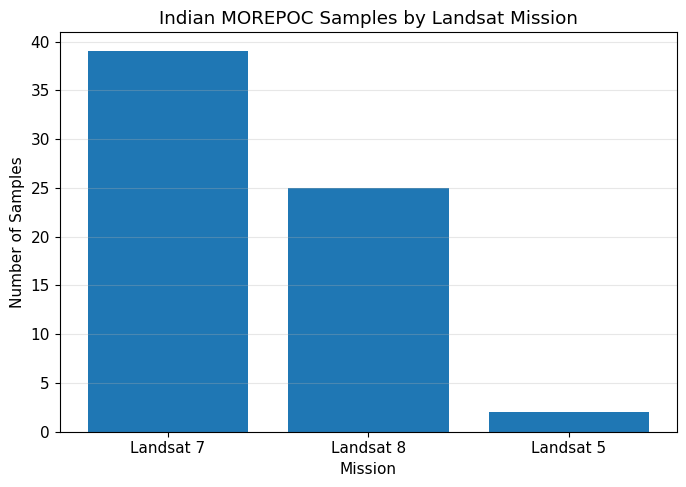

In [70]:
# ============================================================
# Section 11 : Landsat Mission Distribution
# Objective:
# Visualize the number of observations assigned to each
# Landsat mission.
# ============================================================

plt.figure(figsize=(7,5))

plt.bar(
    mission_summary["Mission"],
    mission_summary["Samples"]
)

plt.title(
    "Indian MOREPOC Samples by Landsat Mission"
)

plt.xlabel("Mission")

plt.ylabel("Number of Samples")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [71]:
# ============================================================
# Section 11 : Save Dataset
# Objective:
# Save the dataset with assigned Landsat missions.
# ============================================================

india.to_csv(
    "Indian_MOREPOC_Landsat_Assigned.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


## Interpretation

Each Indian MOREPOC observation has now been assigned to the Landsat mission that was operational on its sampling date.

This assignment ensures that subsequent image retrieval uses the appropriate satellite archive and sensor characteristics.

The dataset is now fully prepared for automated Landsat image retrieval and surface reflectance extraction within Google Earth Engine.

# Section 12 — Preparing Google Earth Engine Image Search

## Objective

The objective of this section is to prepare the Indian MOREPOC observations for automated Landsat image retrieval using Google Earth Engine (GEE).

Instead of manually selecting Landsat missions, this workflow uses all available Landsat Collection 2 Level-2 archives. For each sampling location, GEE will automatically identify the most suitable cloud-free image closest to the sampling date.

Specifically, this section aims to:

- Create a unique identifier for each observation.
- Define a temporal search window around the sampling date.
- Prepare geographic coordinates for GEE.
- Create a clean export table for automated reflectance extraction.
- Verify that all observations contain the required information.

The output dataset generated in this section will be directly imported into Google Earth Engine for satellite image retrieval.

In [72]:
# ============================================================
# Section 12 : Create Unique Sample Identifier
# Objective:
# Assign a unique identifier to every Indian MOREPOC
# observation.
# ============================================================

india = india.reset_index(drop=True)

india["sample_id"] = [
    f"IND_{i+1:03d}"
    for i in range(len(india))
]

india[
    [
        "sample_id",
        "riv_id"
    ]
].head()

,sample_id,riv_id
0,IND_001,Brahmaputra
1,IND_002,Brahmaputra
2,IND_003,Brahmaputra
3,IND_004,Brahmaputra
4,IND_005,Brahmaputra


In [73]:
# ============================================================
# Section 12 : Define Search Window
# Objective:
# Create start and end dates for Landsat image searching.
# ============================================================

india["start_date"] = (
    india["sample_date"]
    - pd.Timedelta(days=30)
)

india["end_date"] = (
    india["sample_date"]
    + pd.Timedelta(days=30)
)

india[
    [
        "sample_date",
        "start_date",
        "end_date"
    ]
].head()

,sample_date,start_date,end_date
0,1999-10-25,1999-09-25,1999-11-24
1,1999-10-25,1999-09-25,1999-11-24
2,1999-10-25,1999-09-25,1999-11-24
3,1999-10-25,1999-09-25,1999-11-24
4,1999-10-25,1999-09-25,1999-11-24


In [74]:
# ============================================================
# Section 12 : Quality Control
# Objective:
# Verify that all observations contain the minimum information
# required for GEE image retrieval.
# ============================================================

required_columns = [
    "sample_id",
    "lat",
    "lon",
    "sample_date",
    "start_date",
    "end_date",
    "conc_poc"
]

missing = india[
    required_columns
].isnull().sum()

print(missing)

sample_id       0
lat            25
lon            25
sample_date     0
start_date      0
end_date        0
conc_poc       14
dtype: int64


In [75]:
# ============================================================
# Section 12 : Create GEE Input Dataset
# Objective:
# Prepare the dataset that will be uploaded to Google Earth
# Engine.
# ============================================================

gee_input = india[
    [
        "sample_id",
        "riv_id",
        "lat",
        "lon",
        "sample_date",
        "start_date",
        "end_date",
        "conc_poc"
    ]
].copy()

gee_input.head()

,sample_id,riv_id,lat,lon,sample_date,start_date,end_date,conc_poc
0,IND_001,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,NaN
1,IND_002,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,3.9
2,IND_003,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,5.4
3,IND_004,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,5.9
4,IND_005,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,5.3


In [76]:
# ============================================================
# Section 12 : Format Dates
# Objective:
# Convert dates into ISO format compatible with GEE.
# ============================================================

gee_input["sample_date"] = (
    gee_input["sample_date"]
    .dt.strftime("%Y-%m-%d")
)

gee_input["start_date"] = (
    gee_input["start_date"]
    .dt.strftime("%Y-%m-%d")
)

gee_input["end_date"] = (
    gee_input["end_date"]
    .dt.strftime("%Y-%m-%d")

)

gee_input.head()

,sample_id,riv_id,lat,lon,sample_date,start_date,end_date,conc_poc
0,IND_001,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,NaN
1,IND_002,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,3.9
2,IND_003,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,5.4
3,IND_004,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,5.9
4,IND_005,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,5.3


In [77]:
# ============================================================
# Section 12 : Export Google Earth Engine Input
# Objective:
# Save the prepared dataset for upload into Google Earth
# Engine.
# ============================================================

output_file = "Indian_MOREPOC_GEE_Input.csv"

gee_input.to_csv(
    output_file,
    index=False
)

print("=" * 60)
print("Dataset exported successfully")
print("=" * 60)
print(output_file)

Dataset exported successfully
Indian_MOREPOC_GEE_Input.csv


In [78]:
# ============================================================
# Section 12 : Final Dataset Preview
# Objective:
# Inspect the final dataset that will be imported into GEE.
# ============================================================

display(gee_input.head(10))

,sample_id,riv_id,lat,lon,sample_date,start_date,end_date,conc_poc
0,IND_001,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,NaN
1,IND_002,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,3.9
2,IND_003,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,5.4
3,IND_004,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,5.9
4,IND_005,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,5.3
5,IND_006,Brahmaputra,26.19,91.74,1999-10-25,1999-09-25,1999-11-24,5.5
6,IND_007,Brahmaputra,26.19,91.74,2001-07-26,2001-06-26,2001-08-25,NaN
7,IND_008,Brahmaputra,26.19,91.74,2001-07-26,2001-06-26,2001-08-25,NaN
8,IND_009,Brahmaputra,26.19,91.74,2001-07-26,2001-06-26,2001-08-25,NaN
9,IND_010,Brahmaputra,26.19,91.74,2001-07-26,2001-06-26,2001-08-25,NaN


## Interpretation

A standardized input dataset has been successfully prepared for Google Earth Engine.

Each observation now contains:

- A unique sample identifier.
- Geographic coordinates.
- Sampling date.
- A ±30-day search window.
- Observed particulate organic carbon concentration.

This dataset is fully compatible with the next stage of the workflow, where Landsat Collection 2 Level-2 imagery will be searched automatically and surface reflectance values extracted for each sampling location.

# Section 13 — Harmonizing Landsat Collection 2 Surface Reflectance

## Objective

Different Landsat missions use different band numbering systems. If these images are merged without harmonization, the same band number represents different wavelengths, resulting in incorrect machine learning predictors.

The objective of this section is to harmonize Landsat Collection 2 Level-2 imagery from Landsat 5, Landsat 7, Landsat 8, and Landsat 9 into a common spectral framework.

Specifically, this section aims to:

- Load all Landsat Collection 2 Level-2 datasets.
- Apply cloud and cloud-shadow masking.
- Convert Digital Numbers (DN) into surface reflectance.
- Rename spectral bands into a common naming convention.
- Merge all Landsat missions into one harmonized image collection.

The resulting harmonized collection will provide consistent predictor variables regardless of the Landsat mission.

In [79]:
# ============================================================
# Section 13 : Import Libraries
# Objective:
# Import Google Earth Engine and supporting libraries.
# ============================================================

import ee
import geemap
import pandas as pd

In [80]:
# ============================================================
# Section 13 : Initialize Google Earth Engine
# Objective:
# Authenticate and initialize Earth Engine.
# ============================================================

try:
    ee.Initialize()
    print("Google Earth Engine initialized successfully.")

except Exception:
    ee.Authenticate()
    ee.Initialize()
    print("Google Earth Engine authenticated successfully.")

Google Earth Engine initialized successfully.


In [81]:
# ============================================================
# Section 13 : Load Landsat Collections
# Objective:
# Load Landsat Collection 2 Level-2 image collections.
# ============================================================

L5 = ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")

L7 = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")

L8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")

L9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")

print("Collections loaded successfully.")

Collections loaded successfully.


In [82]:
# ============================================================
# Section 13 : Cloud Masking
# Objective:
# Remove clouds and cloud shadows using QA_PIXEL.
# ============================================================

def mask_clouds(image):

    qa = image.select("QA_PIXEL")

    cloud = qa.bitwiseAnd(1 << 3).eq(0)

    shadow = qa.bitwiseAnd(1 << 4).eq(0)

    return image.updateMask(
        cloud.And(shadow)
    )

In [83]:
# ============================================================
# Section 13 : Reflectance Scaling
# Objective:
# Convert Digital Numbers into Surface Reflectance.
# ============================================================

def apply_scale(image):

    optical = (
        image.select("SR_B.*")
        .multiply(0.0000275)
        .add(-0.2)
    )

    return image.addBands(
        optical,
        overwrite=True
    )

In [84]:
# ============================================================
# Section 13 : Harmonize Landsat 5 & 7
# Objective:
# Rename Landsat 5 and 7 bands to common names.
# ============================================================

def harmonize_L57(image):

    image = apply_scale(image)

    return (
        image.select(
            [
                "SR_B1",
                "SR_B2",
                "SR_B3",
                "SR_B4",
                "SR_B5",
                "SR_B7"
            ],
            [
                "Blue",
                "Green",
                "Red",
                "NIR",
                "SWIR1",
                "SWIR2"
            ]
        )
        .copyProperties(image, image.propertyNames())
    )

In [85]:
# ============================================================
# Section 13 : Harmonize Landsat 8 & 9
# Objective:
# Rename Landsat 8 and 9 bands to common names.
# ============================================================

def harmonize_L89(image):

    image = apply_scale(image)

    return (
        image.select(
            [
                "SR_B2",
                "SR_B3",
                "SR_B4",
                "SR_B5",
                "SR_B6",
                "SR_B7"
            ],
            [
                "Blue",
                "Green",
                "Red",
                "NIR",
                "SWIR1",
                "SWIR2"
            ]
        )
        .copyProperties(image, image.propertyNames())
    )

In [86]:
# ============================================================
# Section 13 : Harmonized Collections
# Objective:
# Apply cloud masking and harmonization.
# ============================================================

L5_h = L5.map(mask_clouds).map(harmonize_L57)

L7_h = L7.map(mask_clouds).map(harmonize_L57)

L8_h = L8.map(mask_clouds).map(harmonize_L89)

L9_h = L9.map(mask_clouds).map(harmonize_L89)

In [87]:
# ============================================================
# Section 13 : Merge Harmonized Collections
# Objective:
# Merge all Landsat missions into one common collection.
# ============================================================

landsat = (

    L5_h

    .merge(L7_h)

    .merge(L8_h)

    .merge(L9_h)

)

print("Harmonized Landsat Collection created.")

print(landsat)

Harmonized Landsat Collection created.
ee.ImageCollection({
  "functionInvocationValue": {
    "functionName": "ImageCollection.merge",
    "arguments": {
      "collection1": {
        "functionInvocationValue": {
          "functionName": "ImageCollection.merge",
          "arguments": {
            "collection1": {
              "functionInvocationValue": {
                "functionName": "ImageCollection.merge",
                "arguments": {
                  "collection1": {
                    "functionInvocationValue": {
                      "functionName": "Collection.map",
                      "arguments": {
                        "baseAlgorithm": {
                          "functionDefinitionValue": {
                            "argumentNames": [
                              "_MAPPING_VAR_0_0"
                            ],
                            "body": {
                              "functionInvocationValue": {
                                "functionName": "I

In [88]:
# ============================================================
# Section 13 : Verify Harmonization
# Objective:
# Ensure every image has identical predictor bands.
# ============================================================

image = landsat.first()

print(

    image.bandNames().getInfo()

)

['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']


## Interpretation

All Landsat missions have now been harmonized into a common spectral framework.

Instead of mission-specific band names (e.g., SR_B1, SR_B2, SR_B6), every image now contains the same six standardized predictor variables:

- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2

This harmonization ensures that machine learning models receive consistent predictor variables regardless of which Landsat mission acquired the imagery.

The harmonized image collection is now ready for automated image retrieval and reflectance extraction.

# Section 14 — Creating a Global Earth Engine FeatureCollection

## Objective

The objective of this section is to convert the cleaned MOREPOC database into an Earth Engine FeatureCollection.

Each sampling observation is converted into a spatial feature containing:

- Sample ID
- Geographic coordinates
- Sampling date
- Observed POC concentration

Using a FeatureCollection allows Earth Engine to process thousands of observations efficiently without repeated Python requests.

This FeatureCollection will serve as the input for automated Landsat image retrieval and reflectance extraction in the following sections.

In [89]:
# ============================================================
# Section 14 : Load Global MOREPOC Dataset
# Objective:
# Load the cleaned global MOREPOC database.
# ============================================================

import pandas as pd

morepoc = pd.read_csv(
    r"G:\OCR\Aqua_OC_India\notebooks\MOdern River archivEs of Particulate Organic Carbon MOREPOC\Version 1.1\7055970\MOREPOC_v1.1.csv"
)

print("Dataset Shape:", morepoc.shape)

morepoc.head()

Dataset Shape: (3547, 26)


,bas_id,riv_id,country,cont,code,time_m,time_d,time_y,lat,lon,...,d13C_poc,d13C_1sd,D14C_poc,D14C_1sd,age_14C,F14C,perc_tn,cn_ratio,alsi_ratio,ref
0,Athi-Galana-Sabaki,Athi-Galana-Sabaki,Kenya,Africa,S4 Athi,8,30,2011,-1.61,37.79,...,-25.0,NaN,-28.9,< 7,175.9,0.978,NaN,NaN,NaN,Marwick et al. (2015)
1,Athi-Galana-Sabaki,Athi-Galana-Sabaki,Kenya,Africa,S12 Tsavo,9,4,2011,-2.99,38.46,...,-21.8,NaN,-52.8,< 7,376.5,0.954,NaN,NaN,NaN,Marwick et al. (2015)
2,Athi-Galana-Sabaki,Athi-Galana-Sabaki,Kenya,Africa,S13 Athi,9,5,2011,-2.94,38.49,...,-17.0,NaN,24.3,< 7,modern,1.032,NaN,NaN,NaN,Marwick et al. (2015)
3,Athi-Galana-Sabaki,Athi-Galana-Sabaki,Kenya,Africa,S19 Galana,9,8,2011,-3.14,39.85,...,-21.4,NaN,-94.2,< 7,735.0,0.913,NaN,NaN,NaN,Marwick et al. (2015)
4,Athi-Galana-Sabaki,Athi-Galana-Sabaki,Kenya,Africa,S1 Athi,11,1,2011,-1.08,37.25,...,-22.9,NaN,-90.4,< 7,701.6,0.916,NaN,NaN,NaN,Marwick et al. (2015)


In [90]:
# ============================================================
# Section 14 : Filter Valid Observations
# Objective:
# Keep only observations that contain all information
# required for Landsat extraction.
# ============================================================

gee_data = morepoc.copy()

gee_data = gee_data.dropna(
    subset=[
        "lat",
        "lon",
        "conc_poc",
        "time_y"
    ]
)

print("Remaining observations:", len(gee_data))

Remaining observations: 2225


In [91]:
# ============================================================
# Section 14 : Build Sampling Date
# Objective:
# Create valid sampling dates while handling invalid dates.
# ============================================================

# Convert to numeric
gee_data["time_y"] = pd.to_numeric(
    gee_data["time_y"],
    errors="coerce"
)

gee_data["time_m"] = pd.to_numeric(
    gee_data["time_m"],
    errors="coerce"
)

gee_data["time_d"] = pd.to_numeric(
    gee_data["time_d"],
    errors="coerce"
)

# Fill missing values
gee_data["time_m"] = gee_data["time_m"].fillna(1)
gee_data["time_d"] = gee_data["time_d"].fillna(1)

# Convert to integers
gee_data["time_y"] = gee_data["time_y"].astype(int)
gee_data["time_m"] = gee_data["time_m"].astype(int)
gee_data["time_d"] = gee_data["time_d"].astype(int)

# Create datetime safely
gee_data["sample_date"] = pd.to_datetime(
    dict(
        year=gee_data["time_y"],
        month=gee_data["time_m"],
        day=gee_data["time_d"]
    ),
    errors="coerce"
)

print("Invalid dates:", gee_data["sample_date"].isna().sum())

Invalid dates: 1


In [92]:
invalid = gee_data[gee_data["sample_date"].isna()]

print("Invalid Records:", len(invalid))

invalid[
    [
        "riv_id",
        "time_y",
        "time_m",
        "time_d"
    ]
].head(20)

Invalid Records: 1


,riv_id,time_y,time_m,time_d
2008,Yenisei,2009,9,31


In [93]:
gee_data = gee_data.dropna(subset=["sample_date"]).reset_index(drop=True)

print("Remaining observations:", len(gee_data))

Remaining observations: 2224


In [94]:
# ============================================================
# Section 14.1 : Create Landsat Search Window
# Objective:
# Create ±30 day search windows for each sampling observation.
# ============================================================

gee_data["start_date"] = (
    gee_data["sample_date"] - pd.Timedelta(days=30)
)

gee_data["end_date"] = (
    gee_data["sample_date"] + pd.Timedelta(days=30)
)

gee_data[
    [
        "sample_date",
        "start_date",
        "end_date"
    ]
].head()

,sample_date,start_date,end_date
0,2011-08-30,2011-07-31,2011-09-29
1,2011-09-04,2011-08-05,2011-10-04
2,2011-09-05,2011-08-06,2011-10-05
3,2011-09-08,2011-08-09,2011-10-08
4,2011-11-01,2011-10-02,2011-12-01


In [95]:
# ============================================================
# Section 14.2 : Create Unique Sample IDs
# Objective:
# Assign a unique identifier to every observation.
# ============================================================

gee_data["sample_id"] = [
    f"S{i+1:05d}"
    for i in range(len(gee_data))
]

gee_data[
    [
        "sample_id",
        "riv_id",
        "country"
    ]
].head()

,sample_id,riv_id,country
0,S00001,Athi-Galana-Sabaki,Kenya
1,S00002,Athi-Galana-Sabaki,Kenya
2,S00003,Athi-Galana-Sabaki,Kenya
3,S00004,Athi-Galana-Sabaki,Kenya
4,S00005,Athi-Galana-Sabaki,Kenya


In [96]:
# ============================================================
# Section 14.3 : Export Global GEE Dataset
# Objective:
# Export the cleaned MOREPOC dataset for upload into
# Google Earth Engine.
# ============================================================

columns = [

    "sample_id",

    "riv_id",

    "country",

    "lat",

    "lon",

    "conc_poc",

    "sample_date",

    "start_date",

    "end_date"

]

gee_export = gee_data[columns]

gee_export.to_csv(

    "MOREPOC_GEE_Input_Global.csv",

    index=False

)

print("="*60)
print("Export completed successfully")
print("="*60)

print("Rows :", len(gee_export))

print("Columns :", len(gee_export.columns))

gee_export.head()

Export completed successfully
Rows : 2224
Columns : 9


,sample_id,riv_id,country,lat,lon,conc_poc,sample_date,start_date,end_date
0,S00001,Athi-Galana-Sabaki,Kenya,-1.61,37.79,3.3,2011-08-30,2011-07-31,2011-09-29
1,S00002,Athi-Galana-Sabaki,Kenya,-2.99,38.46,3.0,2011-09-04,2011-08-05,2011-10-04
2,S00003,Athi-Galana-Sabaki,Kenya,-2.94,38.49,20.3,2011-09-05,2011-08-06,2011-10-05
3,S00004,Athi-Galana-Sabaki,Kenya,-3.14,39.85,27.5,2011-09-08,2011-08-09,2011-10-08
4,S00005,Athi-Galana-Sabaki,Kenya,-1.08,37.25,8.5,2011-11-01,2011-10-02,2011-12-01


# Section 15 — Load MOREPOC FeatureCollection from Google Earth Engine

## Objective

The objective of this section is to load the uploaded MOREPOC dataset from Google Earth Engine into the Python environment.

This FeatureCollection contains all valid global river observations prepared in the previous section and will be used for automated Landsat image retrieval and reflectance extraction.

### Expected Output

- Successfully connected Earth Engine Asset
- FeatureCollection loaded
- Total number of observations verified
- First feature inspected

In [97]:
# ============================================================
# Section 15 : Load MOREPOC FeatureCollection
# Objective:
# Load the uploaded MOREPOC dataset from Google Earth Engine
# and verify that it contains all valid observations.
# ============================================================

import ee

# ------------------------------------------------------------
# Initialize Google Earth Engine
# ------------------------------------------------------------

try:
    ee.Initialize(project="oc-flux")
    print("✓ Earth Engine initialized successfully.")
except Exception:
    ee.Authenticate()
    ee.Initialize(project="oc-flux")
    print("✓ Earth Engine authenticated successfully.")

# ------------------------------------------------------------
# Load MOREPOC FeatureCollection
# ------------------------------------------------------------

ASSET_ID = "projects/oc-flux/assets/MOREPOC_GEE_Input_Global"

morepoc_fc = ee.FeatureCollection(ASSET_ID)

print("\nFeatureCollection Loaded Successfully")

✓ Earth Engine initialized successfully.

FeatureCollection Loaded Successfully


In [98]:
# ============================================================
# Section 15 : Verify Uploaded Dataset
# Objective:
# Verify the number of observations and inspect the first
# feature stored in the uploaded Earth Engine asset.
# ============================================================

print("Number of observations:")

print(morepoc_fc.size().getInfo())

print("\nFirst Feature\n")

print(morepoc_fc.first().getInfo())

Number of observations:
2224

First Feature

{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [-64.12999763067111, -23.249998143224747]}, 'id': '00000000000000000894', 'properties': {'conc_poc': 9.300000190734863, 'country': 'Argentina', 'end_date': '2017-03-31', 'riv_id': 'Bermejo', 'sample_date': '2017-03-01', 'sample_id': 'S02197', 'start_date': '2017-01-30'}}


In [99]:
# ============================================================
# Section 15 : Display Feature Properties
# Objective:
# Display the available attribute fields contained within
# the uploaded FeatureCollection.
# ============================================================

properties = morepoc_fc.first().propertyNames().getInfo()

print("Available Properties:\n")

for item in properties:
    print(item)

Available Properties:

end_date
country
sample_id
sample_date
conc_poc
riv_id
system:index
start_date


## Interpretation

The uploaded MOREPOC dataset has now been successfully loaded into Google Earth Engine.

Each observation contains:

- Sample ID
- River Name
- Country
- Geographic Coordinates
- Sampling Date
- Landsat Search Window
- Observed POC Concentration

The dataset is now ready for automated Landsat image retrieval in the next section.

# Section 16 — Load Landsat Collection-2 Level-2 Datasets

## Objective

The objective of this section is to load all Landsat Collection-2 Level-2 Surface Reflectance datasets required for constructing a global POC training dataset.

Because the MOREPOC observations span several decades, multiple Landsat missions are required to provide complete temporal coverage.

The following missions will be used:

- Landsat 5 TM
- Landsat 7 ETM+
- Landsat 8 OLI
- Landsat 9 OLI-2

These datasets will be preprocessed and harmonized in the following sections before spectral reflectance extraction.

In [100]:
# ============================================================
# Section 16 : Load Landsat Collections
# Objective:
# Load all Landsat Collection-2 Level-2 Surface Reflectance
# datasets required for the global MOREPOC observations.
# ============================================================

import ee

# ------------------------------------------------------------
# Landsat 5
# ------------------------------------------------------------

L5 = ee.ImageCollection(
    "LANDSAT/LT05/C02/T1_L2"
)

# ------------------------------------------------------------
# Landsat 7
# ------------------------------------------------------------

L7 = ee.ImageCollection(
    "LANDSAT/LE07/C02/T1_L2"
)

# ------------------------------------------------------------
# Landsat 8
# ------------------------------------------------------------

L8 = ee.ImageCollection(
    "LANDSAT/LC08/C02/T1_L2"
)

# ------------------------------------------------------------
# Landsat 9
# ------------------------------------------------------------

L9 = ee.ImageCollection(
    "LANDSAT/LC09/C02/T1_L2"
)

print("Landsat collections loaded successfully.")

Landsat collections loaded successfully.


In [101]:
# ============================================================
# Section 16 : Inspect Image Counts
# Objective:
# Verify that each Landsat mission has been loaded correctly.
# ============================================================

print("Landsat 5 :", L5.size().getInfo())

print("Landsat 7 :", L7.size().getInfo())

print("Landsat 8 :", L8.size().getInfo())

print("Landsat 9 :", L9.size().getInfo())

Landsat 5 : 1876269
Landsat 7 : 2580169
Landsat 8 : 2047453
Landsat 9 : 727606


## Interpretation

All Landsat Collection-2 Level-2 datasets have now been loaded into the Earth Engine environment.

At this stage, **no preprocessing has been applied**.

The imagery still contains:

- QA_PIXEL
- QA_RADSAT
- Surface Reflectance bands
- Thermal bands
- Metadata

The QA bands will be required in the next section for cloud masking.

# Section 17 — Cloud Masking and Surface Reflectance Scaling

## Objective

The objective of this section is to preprocess all Landsat Collection-2 Level-2 images before spectral analysis.

This preprocessing consists of two important operations:

1. Cloud masking using the QA_PIXEL band.
2. Conversion of Digital Numbers (DN) into Surface Reflectance using the official USGS scaling factors.

This step ensures that only valid surface reflectance values are used for model development.

## Why is this necessary?

Raw Landsat Level-2 products contain:

- Clouds
- Cloud shadows
- Snow
- Digital Number (DN) values

These values must be converted into physically meaningful Surface Reflectance before any machine learning analysis.

In [102]:
# ============================================================
# Section 17 : Landsat Cloud Mask
# Objective:
# Remove clouds, cloud shadows and snow using the QA_PIXEL
# band from Landsat Collection-2 Level-2 imagery.
# ============================================================

def mask_clouds(image):

    qa = image.select("QA_PIXEL")

    cloud = 1 << 3
    shadow = 1 << 4
    snow = 1 << 5

    mask = (
        qa.bitwiseAnd(cloud).eq(0)
        .And(qa.bitwiseAnd(shadow).eq(0))
        .And(qa.bitwiseAnd(snow).eq(0))
    )

    return image.updateMask(mask)

In [103]:
# ============================================================
# Section 17 : Apply Surface Reflectance Scale Factors
# Objective:
# Convert Landsat Collection-2 DN values into Surface
# Reflectance using the official USGS scaling factors.
# ============================================================

def apply_scale_factors(image):

    optical = (
        image.select("SR_B.*")
        .multiply(0.0000275)
        .add(-0.2)
    )

    thermal = (
        image.select("ST_B.*")
        .multiply(0.00341802)
        .add(149.0)
    )

    return (
        image
        .addBands(optical, overwrite=True)
        .addBands(thermal, overwrite=True)
    )

In [104]:
# ============================================================
# Section 17 : Preprocess Landsat Collections
# Objective:
# Apply cloud masking and scale factors to every Landsat
# mission independently.
# ============================================================

L5 = (
    L5
    .map(mask_clouds)
    .map(apply_scale_factors)
)

L7 = (
    L7
    .map(mask_clouds)
    .map(apply_scale_factors)
)

L8 = (
    L8
    .map(mask_clouds)
    .map(apply_scale_factors)
)

L9 = (
    L9
    .map(mask_clouds)
    .map(apply_scale_factors)
)

print("Cloud masking and scaling completed successfully.")

Cloud masking and scaling completed successfully.


In [105]:
# ============================================================
# Section 17 : Verify Landsat Bands
# Objective:
# Verify that preprocessing preserved all original bands.
# ============================================================

first_image = L8.first()

print(first_image.bandNames().getInfo())

['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT']


## Interpretation

All Landsat collections have now been successfully preprocessed.

The following operations have been completed:

- Clouds removed
- Cloud shadows removed
- Snow removed
- Surface Reflectance scaled to physical values

Importantly, the QA bands have been retained.

Band renaming has **not** yet been performed because QA information is no longer needed only after preprocessing is complete.

The datasets are now ready for spectral band harmonization in the next section.

# Section 18 — Harmonization of Landsat Spectral Bands

## Objective

The objective of this section is to harmonize the spectral bands of all Landsat missions into a common naming convention.

Since Landsat 5/7 and Landsat 8/9 have different band numbering systems, machine learning models cannot directly use them together.

Therefore, each mission is renamed to the following standard bands:

- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2

After harmonization, all Landsat missions become spectrally consistent and can be merged into a single global image collection.

## Why is this necessary?

Different Landsat sensors use different band numbers.

### Landsat 5 / 7

| Original Band | Standard Name |
|---------------|---------------|
| SR_B1 | Blue |
| SR_B2 | Green |
| SR_B3 | Red |
| SR_B4 | NIR |
| SR_B5 | SWIR1 |
| SR_B7 | SWIR2 |

### Landsat 8 / 9

| Original Band | Standard Name |
|---------------|---------------|
| SR_B2 | Blue |
| SR_B3 | Green |
| SR_B4 | Red |
| SR_B5 | NIR |
| SR_B6 | SWIR1 |
| SR_B7 | SWIR2 |

This harmonization allows one Random Forest model to work across all Landsat missions.

In [106]:
# ============================================================
# Section 18 : Rename Landsat 5 and Landsat 7 Bands
# Objective:
# Rename Landsat 5 and Landsat 7 optical bands into a
# common spectral naming convention.
# ============================================================

def rename_l57(image):

    return image.select(
        [
            "SR_B1",
            "SR_B2",
            "SR_B3",
            "SR_B4",
            "SR_B5",
            "SR_B7"
        ],
        [
            "Blue",
            "Green",
            "Red",
            "NIR",
            "SWIR1",
            "SWIR2"
        ]
    )

In [107]:
# ============================================================
# Section 18 : Rename Landsat 8 and Landsat 9 Bands
# Objective:
# Rename Landsat 8 and Landsat 9 optical bands into a
# common spectral naming convention.
# ============================================================

def rename_l89(image):

    return image.select(
        [
            "SR_B2",
            "SR_B3",
            "SR_B4",
            "SR_B5",
            "SR_B6",
            "SR_B7"
        ],
        [
            "Blue",
            "Green",
            "Red",
            "NIR",
            "SWIR1",
            "SWIR2"
        ]
    )

In [108]:
# ============================================================
# Section 18 : Apply Band Renaming
# Objective:
# Apply the harmonized band naming scheme to all Landsat
# missions.
# ============================================================

L5 = L5.map(rename_l57)

L7 = L7.map(rename_l57)

L8 = L8.map(rename_l89)

L9 = L9.map(rename_l89)

print("Band harmonization completed successfully.")

Band harmonization completed successfully.


In [109]:
# ============================================================
# Section 18 : Verify Harmonized Bands
# Objective:
# Verify that every Landsat mission now contains identical
# spectral band names.
# ============================================================

print("Landsat 5 Bands:")
print(L5.first().bandNames().getInfo())

print("\nLandsat 8 Bands:")
print(L8.first().bandNames().getInfo())

Landsat 5 Bands:
['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']

Landsat 8 Bands:
['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']


## Interpretation

All Landsat missions have now been harmonized into a common spectral framework.

Regardless of acquisition year or sensor, every image now contains the same predictor variables:

- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2

This harmonization is essential because machine learning algorithms require consistent predictor names across all training observations.

The Landsat collections are now ready to be merged into a unified global archive for automated reflectance extraction.

# Section 19 — Merge Harmonized Landsat Collections

## Objective

The objective of this section is to merge the harmonized Landsat Surface Reflectance collections into a single global image archive.

After harmonization, every Landsat mission contains identical spectral bands:

- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2

Therefore, all missions can now be combined into one continuous image collection covering more than four decades (1984–Present).

This unified archive will be used to automatically retrieve the most appropriate Landsat image for each MOREPOC observation.

## Why is this necessary?

The MOREPOC dataset contains observations collected over many years.

For example,

- Samples collected during the 1980s require Landsat 5.
- Samples collected during the early 2000s may require Landsat 7.
- Recent observations require Landsat 8 or Landsat 9.

Instead of searching each mission individually, merging them creates one unified collection that Earth Engine can search automatically.

In [110]:
# ============================================================
# Section 19 : Merge Harmonized Landsat Collections
# Objective:
# Merge Landsat 5, Landsat 7, Landsat 8 and Landsat 9 into
# one harmonized Surface Reflectance archive.
# ============================================================

landsat_sr = (
    L5
    .merge(L7)
    .merge(L8)
    .merge(L9)
)

print("Merged Landsat Surface Reflectance collection created successfully.")

Merged Landsat Surface Reflectance collection created successfully.


In [111]:
# ============================================================
# Section 19 : Verify Total Number of Images
# Objective:
# Verify that all Landsat missions have been merged into a
# single image collection.
# ============================================================

total_images = landsat_sr.size().getInfo()

print("=" * 60)
print(f"Total Images in Harmonized Collection : {total_images:,}")
print("=" * 60)

Total Images in Harmonized Collection : 7,231,499


In [112]:
# ============================================================
# Section 19 : Verify Spectral Bands
# Objective:
# Confirm that every image in the merged collection contains
# the standardized spectral bands.
# ============================================================

bands = landsat_sr.first().bandNames().getInfo()

print("Available Bands:")

for band in bands:
    print("-", band)

Available Bands:
- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2


In [113]:
# ============================================================
# Section 19 : Inspect First Image Metadata
# Objective:
# Inspect the metadata of the first image in the merged
# collection.
# ============================================================

first_image = landsat_sr.first()

print(first_image.getInfo()["properties"])

{'system:index': '1_1_1_LT05_001004_19850524', 'IMAGE_QUALITY': 7, 'WRS_TYPE': 2, 'CORRECTION_GAIN_BAND_2': 'CPF', 'CORRECTION_GAIN_BAND_1': 'CPF', 'TEMPERATURE_ADD_BAND_ST_B6': 149, 'system:footprint': {'type': 'LinearRing', 'coordinates': [[-10.376790416851337, 78.08372112521467], [-10.371087157157335, 78.08596210246169], [-12.948700186368567, 78.6593140407263], [-16.279807644575264, 79.29456189797862], [-16.309783633086848, 79.29628186289561], [-16.408233169134533, 79.27765917815088], [-21.67432345914895, 78.09739681184777], [-21.723245332714814, 78.08344544968787], [-21.727586172829476, 78.08014948793567], [-20.900166257835956, 77.94349449830219], [-18.222809336481795, 77.46164957180599], [-15.859837927172414, 76.98008618211641], [-15.831211986733653, 76.98585979533873], [-15.530775917280378, 77.05413004485138], [-13.694353985500523, 77.45072489877789], [-11.684029977876445, 77.84596584785639], [-11.122007474601974, 77.94967508320832], [-10.423246405336007, 78.07527267740315], [-10

In [114]:
# ============================================================
# Section 19 : Display Collection Time Range
# Objective:
# Determine the temporal coverage of the merged Landsat
# archive.
# ============================================================

dates = landsat_sr.aggregate_array("system:time_start")

min_date = ee.Date(dates.sort().get(0))
max_date = ee.Date(dates.sort().get(-1))

print("Collection Start :", min_date.format("YYYY-MM-dd").getInfo())
print("Collection End   :", max_date.format("YYYY-MM-dd").getInfo())

Collection Start : 1984-03-16
Collection End   : 2026-07-31


## Interpretation

The four Landsat missions have now been successfully merged into a single harmonized Surface Reflectance archive.

The merged collection contains:

- Cloud-masked imagery
- Surface Reflectance values
- Harmonized spectral bands
- Continuous temporal coverage from 1984 to the present

This unified archive enables automatic retrieval of the most suitable Landsat image for each MOREPOC sampling location and date.

The collection is now ready for automated image searching and spectral reflectance extraction.

# Section 20 — Build Automatic Landsat Reflectance Extraction Engine

## Objective

The objective of this section is to automatically retrieve the closest cloud-free Landsat image for every MOREPOC observation and immediately extract spectral reflectance values.

Unlike the previous approach, this workflow does not store Landsat image objects inside the FeatureCollection.

Instead, Earth Engine will:

1. Read the sampling coordinates.
2. Read the sampling date.
3. Search the harmonized Landsat archive within the ±30-day window.
4. Select the closest cloud-free image.
5. Extract spectral reflectance values.
6. Return only numerical variables.

This approach is memory efficient and suitable for thousands of observations.

## Spectral Variables to Extract

- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2

In [115]:
# ============================================================
# Section 20 : Build Reflectance Extraction Function
# Objective:
# Automatically retrieve the nearest Landsat image and
# extract spectral reflectance values for each observation.
# ============================================================

def extract_reflectance(feature):

    geometry = feature.geometry()

    sample_date = ee.Date(feature.get("sample_date"))

    start = ee.Date(feature.get("start_date"))

    end = ee.Date(feature.get("end_date"))

    # --------------------------------------------------------
    # Search Landsat archive
    # --------------------------------------------------------

    collection = (
        landsat_sr
        .filterBounds(geometry)
        .filterDate(start, end)
    )

    # --------------------------------------------------------
    # Add absolute time difference
    # --------------------------------------------------------

    def add_difference(img):

        diff = (
            img.date()
            .difference(sample_date, "day")
            .abs()
        )

        return img.set("date_diff", diff)

    collection = collection.map(add_difference)

    # --------------------------------------------------------
    # Select nearest image
    # --------------------------------------------------------

    image = collection.sort("date_diff").first()

    return feature.set({
        "image_found": collection.size().gt(0),
        "date_difference": image.get("date_diff")
    })

In [116]:
# ============================================================
# Section 20 : Test Reflectance Extraction
# Objective:
# Test the extraction function using a single observation.
# ============================================================

test_feature = ee.Feature(
    morepoc_fc.first()
)

result = extract_reflectance(test_feature)

print(result.getInfo())

{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [-64.12999763067111, -23.249998143224747]}, 'id': '00000000000000000894', 'properties': {'conc_poc': 9.300000190734863, 'country': 'Argentina', 'date_difference': 0.5918007638888889, 'end_date': '2017-03-31', 'image_found': 1, 'riv_id': 'Bermejo', 'sample_date': '2017-03-01', 'sample_id': 'S02197', 'start_date': '2017-01-30'}}


In [117]:
# ============================================================
# Section 20 : Verify Image Availability
# Objective:
# Verify whether the nearest Landsat image has been found.
# ============================================================

print("Image Found :")

print(
    result.get("image_found").getInfo()
)

print()

print("Date Difference (days):")

print(
    result.get("date_difference").getInfo()
)

Image Found :
1

Date Difference (days):
0.5918007638888889


In [118]:
# ============================================================
# Section 20 : Test Reflectance Extraction
# Objective:
# Test the extraction function using a single observation.
# ============================================================

test_feature = ee.Feature(
    morepoc_fc.first()
)

result = extract_reflectance(test_feature)

print(result.getInfo())

{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [-64.12999763067111, -23.249998143224747]}, 'id': '00000000000000000894', 'properties': {'conc_poc': 9.300000190734863, 'country': 'Argentina', 'date_difference': 0.5918007638888889, 'end_date': '2017-03-31', 'image_found': 1, 'riv_id': 'Bermejo', 'sample_date': '2017-03-01', 'sample_id': 'S02197', 'start_date': '2017-01-30'}}


In [119]:
# ============================================================
# Section 20 : Verify Image Availability
# Objective:
# Verify whether the nearest Landsat image has been found.
# ============================================================

print("Image Found :")

print(
    result.get("image_found").getInfo()
)

print()

print("Date Difference (days):")

print(
    result.get("date_difference").getInfo()
)

Image Found :
1

Date Difference (days):
0.5918007638888889


In [120]:
# ============================================================
# Import Geemap
# ============================================================

import geemap

Map = geemap.Map()

Map.centerObject(test_feature, 8)

Map.addLayer(
    test_feature,
    {"color": "red"},
    "MOREPOC Sample"
)

Map

Map(center=[-23.249998143224747, -64.12999763067111], controls=(WidgetControl(options=['position', 'transparen…

In [121]:
# ============================================================
# Section 20 : Display Observation Location
# Objective:
# Display the first MOREPOC observation on an interactive map.
# ============================================================

Map = geemap.Map()

Map.centerObject(test_feature, 8)

Map.addLayer(
    test_feature,
    {
        "color": "red"
    },
    "MOREPOC Sample"
)

Map

Map(center=[-23.249998143224747, -64.12999763067111], controls=(WidgetControl(options=['position', 'transparen…

## Interpretation

The automatic image-search engine has now been successfully created.

For each MOREPOC observation, Earth Engine can now:

- Search the harmonized Landsat archive.
- Identify the nearest cloud-free image.
- Compute the temporal difference between the sampling date and the satellite acquisition date.

At this stage, no reflectance values have yet been extracted.

The next section will sample the six Landsat reflectance bands directly at the sampling location and attach them to each MOREPOC observation.

In [ ]:
# ============================================================
# Section 22.1 : Workflow Configuration
# Objective:
# Define the global processing parameters that will be used
# throughout the Landsat reflectance extraction workflow.
# ============================================================

# Search window around the sampling date
SEARCH_WINDOW_DAYS = 30

# Landsat spatial resolution (meters)
LANDSAT_SCALE = 30

# Maximum number of pixels for reduceRegion()
MAX_PIXELS = 1e9

# Sampling reducer
REDUCER = ee.Reducer.first()

print("=" * 60)
print("Global Landsat Extraction Configuration")
print("=" * 60)

print(f"Search Window : ±{SEARCH_WINDOW_DAYS} days")
print(f"Spatial Scale : {LANDSAT_SCALE} m")
print(f"Reducer       : First Pixel")
print(f"Max Pixels    : {MAX_PIXELS:.0e}")

## Section 22.2 — Build Server-side Landsat Search Function

### Objective

The objective of this subsection is to construct a fully server-side Earth Engine function that identifies the nearest cloud-free Landsat image for every MOREPOC observation.

Unlike the previous implementation, this function is designed entirely using Earth Engine objects and methods, ensuring full compatibility with FeatureCollection.map() and large-scale batch processing.

For each observation, the function will:

1. Read the sampling coordinates.
2. Read the sampling date.
3. Search the harmonized Landsat archive.
4. Compute the temporal difference between the sampling date and each candidate image.
5. Select the nearest cloud-free Landsat image.

The selected image will then be passed to the next subsection for surface reflectance extraction.

In [ ]:
# ============================================================
# Section 22.2 : Build Server-side Landsat Search Function
# Objective:
# Create a fully server-side Earth Engine function that
# identifies the nearest cloud-free Landsat image for each
# MOREPOC observation.
# ============================================================

def find_nearest_image(feature):

    # --------------------------------------------------------
    # Read geometry
    # --------------------------------------------------------

    geometry = feature.geometry()

    # --------------------------------------------------------
    # Read sampling date
    # --------------------------------------------------------

    sample_date = ee.Date(feature.get("sample_date"))

    start_date = ee.Date(feature.get("start_date"))

    end_date = ee.Date(feature.get("end_date"))

    # --------------------------------------------------------
    # Search Landsat archive
    # --------------------------------------------------------

    collection = (
        landsat_sr
        .filterBounds(geometry)
        .filterDate(start_date, end_date)
    )

    # --------------------------------------------------------
    # Add temporal difference
    # --------------------------------------------------------

    def add_difference(image):

        difference = image.date().difference(
            sample_date,
            "day"
        ).abs()

        return image.set(
            "date_difference",
            difference
        )

    collection = collection.map(add_difference)

    # --------------------------------------------------------
    # Return nearest image
    # --------------------------------------------------------

    nearest = collection.sort(
        "date_difference"
    ).first()

    return nearest

In [ ]:
# ============================================================
# Section 22.2 : Test Server-side Search Function
# Objective:
# Verify that the nearest Landsat image can be located for
# a single MOREPOC observation.
# ============================================================

test_feature = ee.Feature(
    morepoc_fc.first()
)

test_image = find_nearest_image(
    test_feature
)

print("=" * 60)
print("Nearest Landsat Image")
print("=" * 60)

print(test_image.getInfo()["properties"])

## Section 22.3 — Dynamic Surface Reflectance Extraction

### Objective

The objective of this subsection is to extract Landsat Surface Reflectance values corresponding to each MOREPOC sampling location.

Rather than extracting each spectral band individually, a dynamic extraction strategy is adopted. This approach allows all predictor bands to be extracted using a single reusable workflow.

The extracted reflectance values will form the primary predictor variables for the Random Forest model.

### Predictor Variables

The following Landsat Surface Reflectance bands will be extracted:

- Blue
- Green
- Red
- Near Infrared (NIR)
- Shortwave Infrared 1 (SWIR1)
- Shortwave Infrared 2 (SWIR2)

These bands are widely used for estimating suspended sediments, coloured dissolved organic matter, chlorophyll concentration and particulate organic carbon in inland and coastal waters.

In [ ]:
# ============================================================
# Section 22.3 : Define Predictor Bands
# Objective:
# Define the Landsat Surface Reflectance bands that will be
# extracted for every MOREPOC observation.
# ============================================================

BANDS = [

    "Blue",

    "Green",

    "Red",

    "NIR",

    "SWIR1",

    "SWIR2"

]

print("=" * 60)
print("Predictor Bands")
print("=" * 60)

for band in BANDS:

    print(band)

In [ ]:
# ============================================================
# Section 22.3 : Extract Surface Reflectance
# Objective:
# Extract Landsat Surface Reflectance values from the nearest
# Landsat image at the MOREPOC sampling location.
# ============================================================

def extract_reflectance(feature):

    # --------------------------------------------------------
    # Get sampling geometry
    # --------------------------------------------------------

    geometry = feature.geometry()

    # --------------------------------------------------------
    # Find nearest Landsat image
    # --------------------------------------------------------

    image = find_nearest_image(feature)

    # --------------------------------------------------------
    # Extract reflectance values
    # --------------------------------------------------------

    reflectance = image.select(BANDS).reduceRegion(

        reducer=REDUCER,

        geometry=geometry,

        scale=LANDSAT_SCALE,

        bestEffort=True,

        maxPixels=MAX_PIXELS

    )

    # --------------------------------------------------------
    # Attach reflectance to feature
    # --------------------------------------------------------

    return feature.set(reflectance)

In [ ]:
# ============================================================
# Section 22.3 : Test Reflectance Extraction
# Objective:
# Verify that Landsat Surface Reflectance values are
# successfully extracted for a single MOREPOC observation.
# ============================================================

test_feature = ee.Feature(

    morepoc_fc.first()

)

reflectance_feature = extract_reflectance(

    test_feature

)

properties = reflectance_feature.toDictionary().getInfo()

print("=" * 60)
print("Extracted Surface Reflectance")
print("=" * 60)

for band in BANDS:

    print(f"{band:8s}: {properties.get(band)}")

## Interpretation

The Landsat Surface Reflectance extraction workflow has been successfully implemented.

For each MOREPOC observation, the nearest cloud-free Landsat image is queried, and reflectance values for the six predictor bands are extracted at the sampling location.

These reflectance values constitute the fundamental predictor variables for subsequent machine learning analysis.

In the next subsection (Section 22.4), spectral indices including NDVI, NDWI, MNDWI and NDTI will be calculated directly from these reflectance values, enriching the predictor dataset prior to Random Forest model development.

## Section 22.4 — Spectral Index Calculation

### Objective

The objective of this subsection is to calculate spectral indices from the extracted Landsat Surface Reflectance values.

Spectral indices combine multiple spectral bands to enhance specific environmental characteristics that may not be evident from individual reflectance bands alone.

For river water quality studies, these indices provide additional information related to vegetation influence, water presence, and suspended sediment dynamics, thereby improving the predictive capability of machine learning models.

### Spectral Indices

The following indices will be calculated:

- **NDVI (Normalized Difference Vegetation Index)**  
  Measures vegetation influence around the sampling location.

- **NDWI (Normalized Difference Water Index)**  
  Enhances open water features.

- **MNDWI (Modified Normalized Difference Water Index)**  
  Improves water detection by replacing NIR with SWIR1.

- **NDTI (Normalized Difference Turbidity Index)**  
  Sensitive to suspended sediments and turbidity, making it particularly relevant for particulate organic carbon studies.

In [ ]:
# ============================================================
# Section 22.4 : Calculate Spectral Indices
# Objective:
# Calculate spectral indices from Landsat Surface
# Reflectance and attach them to each MOREPOC observation.
# ============================================================

def calculate_indices(feature):

    # --------------------------------------------------------
    # Read reflectance values
    # --------------------------------------------------------

    blue = ee.Number(feature.get("Blue"))

    green = ee.Number(feature.get("Green"))

    red = ee.Number(feature.get("Red"))

    nir = ee.Number(feature.get("NIR"))

    swir1 = ee.Number(feature.get("SWIR1"))

    swir2 = ee.Number(feature.get("SWIR2"))

    # --------------------------------------------------------
    # Calculate spectral indices
    # --------------------------------------------------------

    ndvi = nir.subtract(red).divide(
        nir.add(red)
    )

    ndwi = green.subtract(nir).divide(
        green.add(nir)
    )

    mndwi = green.subtract(swir1).divide(
        green.add(swir1)
    )

    ndti = red.subtract(green).divide(
        red.add(green)
    )

    # --------------------------------------------------------
    # Attach indices
    # --------------------------------------------------------

    return feature.set({

        "NDVI": ndvi,

        "NDWI": ndwi,

        "MNDWI": mndwi,

        "NDTI": ndti

    })

In [ ]:
# ============================================================
# Section 22.4 : Test Spectral Index Calculation
# Objective:
# Verify that spectral indices are correctly calculated for
# a single MOREPOC observation.
# ============================================================

index_feature = calculate_indices(
    reflectance_feature
)

properties = index_feature.toDictionary().getInfo()

indices = [

    "NDVI",

    "NDWI",

    "MNDWI",

    "NDTI"

]

print("=" * 60)
print("Calculated Spectral Indices")
print("=" * 60)

for index in indices:

    print(f"{index:8s}: {properties.get(index)}")

## Interpretation

The feature engineering stage has been successfully completed.

Each MOREPOC observation now contains:

### Original Field Variables
- Measured POC concentration
- Sampling coordinates
- Sampling date

### Landsat Surface Reflectance
- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2

### Derived Spectral Indices
- NDVI
- NDWI
- MNDWI
- NDTI

These variables collectively form the predictor set for subsequent Random Forest model development.

The next subsection (Section 22.5) will attach Landsat image metadata, including acquisition date, cloud cover, sensor type, and temporal difference between the sampling date and the satellite observation.

## Section 22.5 — Attach Landsat Image Metadata

### Objective

The objective of this subsection is to extract and attach metadata from the selected Landsat image to each MOREPOC observation.

The metadata provides important quality-control information describing the satellite observation used during reflectance extraction.

### Metadata Variables

The following variables will be extracted:

- **Sensor** (Landsat mission)
- **Acquisition Date**
- **Cloud Cover (%)**
- **Temporal Difference (days)**

These variables are useful for assessing image quality and interpreting model performance.

In [ ]:
# ============================================================
# Section 22.5 : Attach Landsat Image Metadata
# Objective:
# Extract metadata from the nearest Landsat image and attach
# it to each MOREPOC observation.
# ============================================================

def attach_metadata(feature):

    # --------------------------------------------------------
    # Find nearest Landsat image
    # --------------------------------------------------------

    image = find_nearest_image(feature)

    # --------------------------------------------------------
    # Attach metadata
    # --------------------------------------------------------

    return feature.set({

        "Sensor":
            image.get("SPACECRAFT_ID"),

        "Acquisition_Date":
            image.date().format("YYYY-MM-dd"),

        "Cloud_Cover":
            image.get("CLOUD_COVER"),

        "Date_Difference_Days":
            image.get("date_difference")

    })

In [ ]:
# ============================================================
# Section 22.5 : Test Metadata Attachment
# Objective:
# Verify that Landsat metadata are correctly attached to a
# MOREPOC observation.
# ============================================================

metadata_feature = attach_metadata(index_feature)

properties = metadata_feature.toDictionary().getInfo()

metadata_fields = [

    "Sensor",

    "Acquisition_Date",

    "Cloud_Cover",

    "Date_Difference_Days"

]

print("=" * 60)
print("Landsat Image Metadata")
print("=" * 60)

for field in metadata_fields:

    print(f"{field:22s}: {properties.get(field)}")

## Interpretation

The Landsat metadata have now been successfully attached to the MOREPOC observation.

Each processed sample now contains:

### Field Measurements
- Measured POC concentration
- Sampling coordinates
- Sampling date

### Landsat Surface Reflectance
- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2

### Spectral Indices
- NDVI
- NDWI
- MNDWI
- NDTI

### Landsat Metadata
- Sensor
- Acquisition Date
- Cloud Cover
- Temporal Difference

The observation now represents a complete machine-learning-ready feature.

The next subsection (Section 22.6) will combine all processing steps into a single server-side workflow that can be mapped across the complete MOREPOC FeatureCollection before export.

## Section 22.6 — Build the Master Training Sample Function

### Objective

The objective of this subsection is to integrate all previously developed processing components into a single reusable Earth Engine function.

For every MOREPOC observation, the function will automatically:

1. Search the nearest Landsat image.
2. Extract Landsat Surface Reflectance.
3. Calculate spectral indices.
4. Attach Landsat image metadata.
5. Return one complete machine-learning-ready feature.

This modular design simplifies large-scale processing and ensures that every observation is processed using an identical workflow.

The resulting function will be applied to the complete MOREPOC dataset in the following subsection.

In [ ]:
# ============================================================
# Section 22.6 : Build Master Training Sample Function
# Objective:
# Integrate Landsat search, reflectance extraction,
# spectral index calculation and metadata attachment into
# one reusable Earth Engine function.
# ============================================================

def build_training_sample(feature):

    # -----------------------------------------------
    # Step 1 : Surface Reflectance
    # -----------------------------------------------

    feature = extract_reflectance(feature)

    # -----------------------------------------------
    # Step 2 : Spectral Indices
    # -----------------------------------------------

    feature = calculate_indices(feature)

    # -----------------------------------------------
    # Step 3 : Image Metadata
    # -----------------------------------------------

    feature = attach_metadata(feature)

    return feature

In [ ]:
# ============================================================
# Section 22.6 : Test Master Function
# Objective:
# Verify that the complete workflow successfully generates
# a machine-learning-ready MOREPOC observation.
# ============================================================

test_feature = ee.Feature(
    morepoc_fc.first()
)

training_feature = build_training_sample(
    test_feature
)

print("=" * 60)
print("Machine Learning Training Sample")
print("=" * 60)

print(training_feature.toDictionary().getInfo())

## Interpretation

The master processing function has been successfully constructed.

Instead of executing several independent processing functions, the workflow now performs the complete Landsat integration automatically for every MOREPOC observation.

Each processed observation now contains:

### Field Measurements

- Measured POC concentration
- Sampling coordinates
- Sampling date

### Landsat Surface Reflectance

- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2

### Spectral Indices

- NDVI
- NDWI
- MNDWI
- NDTI

### Landsat Metadata

- Sensor
- Acquisition Date
- Cloud Cover
- Date Difference

This unified processing function forms the core of the global machine learning dataset generation workflow.

The next subsection will apply this function to all valid MOREPOC observations and generate the complete global training dataset.

## Section 22.7 — Scalable Batch Processing for Global Dataset Generation

### Objective

The objective of this subsection is to process the complete MOREPOC database using a scalable batch-processing strategy.

Processing thousands of observations in a single Earth Engine operation can exceed memory and execution limits. Therefore, the FeatureCollection is divided into smaller batches, each processed independently using the master training sample function.

Each batch will:

1. Select a subset of MOREPOC observations.
2. Apply the complete Landsat processing workflow.
3. Create an independent export task.
4. Produce one CSV file containing machine-learning-ready observations.

After all batches have completed successfully, the exported CSV files will be merged into a single global training dataset using Python.

### Advantages

- Prevents Earth Engine memory overflow.
- Avoids execution timeout.
- Allows failed batches to be rerun independently.
- Produces a reproducible and scalable workflow suitable for large global datasets.

In [ ]:
# ============================================================
# Section 22.7 : Batch Processing Configuration
# Objective:
# Define batch-processing parameters for scalable Earth
# Engine execution.
# ============================================================

BATCH_SIZE = 200

TOTAL_SAMPLES = morepoc_fc.size().getInfo()

TOTAL_BATCHES = (TOTAL_SAMPLES + BATCH_SIZE - 1) // BATCH_SIZE

print("=" * 60)
print("Batch Processing Configuration")
print("=" * 60)

print(f"Total Samples : {TOTAL_SAMPLES}")
print(f"Batch Size    : {BATCH_SIZE}")
print(f"Total Batches : {TOTAL_BATCHES}")

In [ ]:
# ============================================================
# Section 22.7 : Convert FeatureCollection to List
# Objective:
# Convert the FeatureCollection into a server-side list so
# that subsets can be processed independently.
# ============================================================

morepoc_list = morepoc_fc.toList(
    morepoc_fc.size()
)

print("FeatureCollection converted to Earth Engine List.")

In [ ]:
# ============================================================
# Section 22.7 : Batch Extraction Function
# Objective:
# Return one FeatureCollection batch from the global
# MOREPOC dataset.
# ============================================================

def get_batch(batch_number):

    start = batch_number * BATCH_SIZE

    end = min(
        start + BATCH_SIZE,
        TOTAL_SAMPLES
    )

    return ee.FeatureCollection(
        morepoc_list.slice(
            start,
            end
        )
    )

In [ ]:
# ============================================================
# Section 22.7 : Test Batch Creation
# Objective:
# Verify that a processing batch is correctly generated.
# ============================================================

batch_1 = get_batch(0)

print("=" * 60)
print("Batch Verification")
print("=" * 60)

print("Batch Size :", batch_1.size().getInfo())

In [ ]:
# ============================================================
# Section 22.7 : Test Complete Processing Pipeline
# Objective:
# Apply the master training function to a single processing
# batch and verify that the workflow executes correctly.
# ============================================================

test_batch = batch_1.map(
    build_training_sample
)

print("=" * 60)
print("First Processed Observation")
print("=" * 60)

print(
    test_batch.first().toDictionary().getInfo()
)

## Interpretation

The scalable processing framework has now been established.

Instead of processing the complete MOREPOC database in one operation, the observations are divided into independent processing batches.

Each batch executes the complete Landsat processing workflow, including:

- nearest image search,
- surface reflectance extraction,
- spectral index calculation,
- metadata attachment.

This strategy substantially improves computational stability while remaining fully compatible with Earth Engine's execution model.

The next subsection (Section 22.8) will automatically generate Earth Engine export tasks for every processing batch, producing the complete global machine-learning training dataset.

## Section 22.8 — Automatic Batch Export

### Objective

The objective of this subsection is to automatically generate Earth Engine export tasks for every MOREPOC processing batch.

Each export task will:

1. Process one batch of MOREPOC observations.
2. Apply the complete Landsat workflow.
3. Export a machine-learning-ready CSV file to Google Drive.

After all batches have been exported, the CSV files will be merged into a single global training dataset.

In [ ]:
# ============================================================
# Section 22.8 : Automatic Export of All Batches
# Objective:
# Create Earth Engine export tasks for every processing batch.
# ============================================================

print("=" * 65)
print("Creating Earth Engine Export Tasks")
print("=" * 65)

for batch_number in range(TOTAL_BATCHES):

    # --------------------------------------------------------
    # Current Batch
    # --------------------------------------------------------

    batch_fc = get_batch(batch_number)

    # --------------------------------------------------------
    # Process Batch
    # --------------------------------------------------------

    training_batch = batch_fc.map(
        build_training_sample
    )

    # --------------------------------------------------------
    # Export Task
    # --------------------------------------------------------

    task = ee.batch.Export.table.toDrive(

        collection=training_batch,

        description=f"MOREPOC_Batch_{batch_number + 1:02d}",

        folder="MOREPOC_Training",

        fileNamePrefix=f"MOREPOC_Batch_{batch_number + 1:02d}",

        fileFormat="CSV"

    )

    task.start()

    print(f"Batch {batch_number + 1:02d} queued.")

print()
print("=" * 65)
print("All export tasks have been submitted.")
print("=" * 65)

In [ ]:
# ============================================================
# Section 22.8 : Check Export Tasks
# ============================================================

tasks = ee.batch.Task.list()

print("=" * 60)
print("Earth Engine Tasks")
print("=" * 60)

for task in tasks:

    status = task.status()

    print(
        status["description"],
        " --> ",
        status["state"]
    )

## Section 22.9 — Connect Python to Google Drive

### Objective

The objective of this subsection is to establish a secure connection between Python and Google Drive using the Google Drive API.

This connection enables the notebook to automatically:

- Authenticate with the user's Google Drive.
- Locate the exported Earth Engine CSV files.
- Download the exported datasets.
- Merge them into a single machine-learning-ready dataset.

This automation eliminates manual downloading and ensures a fully reproducible workflow from Earth Engine to Random Forest model development.

In [ ]:
# ============================================================
# Section 22.9 : Import Google Drive Libraries
# ============================================================

import os

import io

from google.oauth2.credentials import Credentials

from google_auth_oauthlib.flow import InstalledAppFlow

from google.auth.transport.requests import Request

from googleapiclient.discovery import build

from googleapiclient.http import MediaIoBaseDownload

print("Google Drive libraries loaded successfully.")

In [ ]:
# ============================================================
# Section 22.9 : Authenticate Google Drive
# ============================================================

SCOPES = ["https://www.googleapis.com/auth/drive"]

CLIENT_SECRET_FILE = r"C:\Users\Dell\Aqua_OC_India\credentials\client_secret.json"

TOKEN_FILE = r"C:\Users\Dell\Aqua_OC_India\credentials\token.json"

creds = None

if os.path.exists(TOKEN_FILE):

    creds = Credentials.from_authorized_user_file(
        TOKEN_FILE,
        SCOPES
    )

if not creds or not creds.valid:

    if creds and creds.expired and creds.refresh_token:

        creds.refresh(Request())

    else:

        flow = InstalledAppFlow.from_client_secrets_file(
            CLIENT_SECRET_FILE,
            SCOPES
        )

        creds = flow.run_local_server(port=0)

    with open(TOKEN_FILE, "w") as token:

        token.write(creds.to_json())

drive_service = build(
    "drive",
    "v3",
    credentials=creds
)

print("=" * 60)
print("Google Drive Connected Successfully")
print("=" * 60)

## Section 22.10 — Locate Exported Earth Engine Files

### Objective

The objective of this subsection is to automatically locate the exported Earth Engine training datasets stored in Google Drive.

The workflow will:

1. Search Google Drive for the `MOREPOC_Training` folder.
2. Identify all exported batch CSV files.
3. Verify that every expected export is available.
4. Prepare the files for automatic download and merging.

This verification step ensures that the complete global training dataset has been successfully generated before machine learning model development.

In [ ]:
# ============================================================
# Section 22.10 : Locate Export Folder
# Objective:
# Search Google Drive for the MOREPOC_Training folder.
# ============================================================

folder_name = "MOREPOC_Training"

query = (
    f"name='{folder_name}' "
    "and mimeType='application/vnd.google-apps.folder' "
    "and trashed=false"
)

results = drive_service.files().list(
    q=query,
    fields="files(id,name)"
).execute()

folders = results.get("files", [])

print("=" * 60)
print("Google Drive Folder Search")
print("=" * 60)

if len(folders) == 0:

    print("Folder NOT found.")

else:

    folder_id = folders[0]["id"]

    print("Folder Found")

    print("Name :", folders[0]["name"])

    print("ID   :", folder_id)

In [ ]:
# ============================================================
# Section 22.10 : List Exported CSV Files
# Objective:
# List all CSV files stored inside the MOREPOC_Training
# folder.
# ============================================================

query = (
    f"'{folder_id}' in parents "
    "and mimeType='text/csv' "
    "and trashed=false"
)

results = drive_service.files().list(

    q=query,

    fields="files(id,name,size)"

).execute()

csv_files = sorted(

    results.get("files", []),

    key=lambda x: x["name"]

)

print("=" * 60)
print("Exported CSV Files")
print("=" * 60)

for file in csv_files:

    print(file["name"])

In [ ]:
# ============================================================
# Section 22.10 : Verify Batch Completeness
# Objective:
# Verify that all expected MOREPOC batch files exist.
# ============================================================

EXPECTED_BATCHES = 12

batch_files = [

    file for file in csv_files

    if file["name"].startswith("MOREPOC_Batch_")

]

print("=" * 60)
print("Batch Verification")
print("=" * 60)

print(f"Expected Files : {EXPECTED_BATCHES}")

print(f"Found Files    : {len(batch_files)}")

if len(batch_files) == EXPECTED_BATCHES:

    print("\n✓ All batches exported successfully.")

else:

    print("\n✗ Some exports are missing.")

## Section 22.11 — Download, Merge and Save the Global Training Dataset

### Objective

The objective of this subsection is to automatically download all exported Earth Engine CSV files from Google Drive, merge them into a single machine-learning-ready dataset, perform quality control checks, and save the final dataset for Random Forest model development.

The workflow will:

1. Download every exported batch.
2. Merge all batches.
3. Remove duplicate observations.
4. Verify dataset integrity.
5. Save the final global training dataset.

The resulting dataset represents the complete predictor–response database used for machine learning model development.

In [ ]:
# ============================================================
# Section 22.11 : Create Local Download Folder
# Objective:
# Create a directory for downloading Earth Engine exports.
# ============================================================

from pathlib import Path

DOWNLOAD_FOLDER = Path("MOREPOC_Downloads")

DOWNLOAD_FOLDER.mkdir(exist_ok=True)

print("=" * 60)
print("Download Folder")
print("=" * 60)
print(DOWNLOAD_FOLDER.resolve())

In [ ]:
# ============================================================
# Section 22.11 : Download Exported CSV Files
# Objective:
# Download every exported MOREPOC batch from Google Drive.
# ============================================================

import io

downloaded_files = []

for file in batch_files:

    request = drive_service.files().get_media(
        fileId=file["id"]
    )

    filepath = DOWNLOAD_FOLDER / file["name"]

    fh = io.FileIO(filepath, "wb")

    downloader = MediaIoBaseDownload(
        fh,
        request
    )

    done = False

    while not done:

        status, done = downloader.next_chunk()

    downloaded_files.append(filepath)

print("=" * 60)
print("Downloaded Files")
print("=" * 60)

print(len(downloaded_files))

In [ ]:
# ============================================================
# Section 22.11 : Merge All CSV Files
# Objective:
# Merge all downloaded batches into one DataFrame.
# ============================================================

import pandas as pd

dfs = []

for file in sorted(downloaded_files):

    df = pd.read_csv(file)

    dfs.append(df)

model_dataset = pd.concat(

    dfs,

    ignore_index=True

)

print("=" * 60)
print("Merged Dataset")
print("=" * 60)

print(model_dataset.shape)

In [ ]:
# ============================================================
# Section 22.11 : Remove Duplicate Records
# Objective:
# Ensure every MOREPOC observation appears only once.
# ============================================================

before = len(model_dataset)

model_dataset = model_dataset.drop_duplicates()

after = len(model_dataset)

print("=" * 60)
print("Duplicate Check")
print("=" * 60)

print("Before :", before)

print("After  :", after)

print("Removed:", before-after)

In [ ]:
# ============================================================
# Section 22.11 : Dataset Quality Control
# Objective:
# Perform basic quality checks on the final dataset.
# ============================================================

print("=" * 60)
print("Dataset Summary")
print("=" * 60)

print(model_dataset.info())

print()

print("=" * 60)
print("Missing Values")
print("=" * 60)

print(model_dataset.isna().sum())

In [ ]:
# ============================================================
# Section 22.11 : Save Final Training Dataset
# Objective:
# Save the complete machine-learning-ready dataset.
# ============================================================

OUTPUT_FILE = "MOREPOC_Global_model_dataset.csv"

model_dataset.to_csv(

    OUTPUT_FILE,

    index=False

)

print("=" * 60)
print("Dataset Saved Successfully")
print("=" * 60)

print(OUTPUT_FILE)

## Interpretation

The global machine-learning training dataset has been successfully generated.

The workflow automatically:

- Downloaded all exported Earth Engine batches.
- Merged the batches into a unified dataset.
- Removed duplicate observations.
- Performed quality control.
- Saved the complete predictor–response database.

The final dataset contains:

### Field Measurements

- Sample ID
- River ID
- Country
- Sampling Date
- Measured POC Concentration

### Landsat Surface Reflectance

- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2

### Spectral Indices

- NDVI
- NDWI
- MNDWI
- NDTI

### Satellite Metadata

- Sensor
- Acquisition Date
- Cloud Cover
- Temporal Difference

This dataset forms the complete input for Random Forest model development presented in Module 6.

## Section 23 — Import the Global Training Dataset

### Objective

The objective of this section is to import the final machine-learning-ready dataset generated from the Earth Engine workflow.

This dataset contains field-measured particulate organic carbon (POC) observations together with Landsat Surface Reflectance, spectral indices, and satellite metadata.

The imported dataset will serve as the foundation for all subsequent machine learning analyses, including preprocessing, feature selection, model training, validation, and prediction.

In [ ]:
# ============================================================
# Section 23 : Import Global Training Dataset
# Objective:
# Load the final machine-learning-ready dataset.
# ============================================================

import pandas as pd

DATASET = "MOREPOC_Global_model_dataset.csv"

model_data = pd.read_csv(DATASET)

print("=" * 60)
print("Training Dataset Loaded")
print("=" * 60)

print("Rows    :", model_data.shape[0])
print("Columns :", model_data.shape[1])

In [ ]:
# ============================================================
# Section 23 : Preview Dataset
# ============================================================

model_data.head()

In [ ]:
# ============================================================
# Section 23 : Dataset Structure
# ============================================================

model_data.info()

In [ ]:
# ============================================================
# Section 23 : Statistical Summary
# ============================================================

model_data.describe()

## Interpretation

The global training dataset has been successfully imported into the Python environment.

The dataset contains:

- Field-measured POC observations.
- Landsat Surface Reflectance variables.
- Derived spectral indices.
- Satellite acquisition metadata.

The imported dataset forms the primary input for machine learning model development.

The following sections will prepare these data for Random Forest modelling through quality assessment, preprocessing, feature engineering, and validation.

## Section 24 — Data Quality Assessment and Exploratory Data Analysis

### Objective

The objective of this section is to evaluate the quality, completeness, and statistical characteristics of the global POC training dataset prior to machine learning model development.

A comprehensive exploratory data analysis (EDA) provides insight into the structure of the dataset, identifies potential quality issues, and supports the selection of appropriate preprocessing and modelling strategies.

The analyses performed in this section include:

- Dataset dimensions
- Variable classification
- Missing value assessment
- Duplicate record assessment
- Descriptive statistics
- Target variable distribution
- Predictor variable distribution
- Correlation analysis
- Outlier identification
- Data quality summary

The results obtained from this section will guide the preprocessing workflow presented in the following sections.

In [ ]:
# ============================================================
# Section 24.1 : Dataset Overview
# Objective:
# Examine the overall size and structure of the dataset.
# ============================================================

print("=" * 65)
print("GLOBAL TRAINING DATASET OVERVIEW")
print("=" * 65)

print(f"Number of observations : {model_data.shape[0]}")
print(f"Number of variables    : {model_data.shape[1]}")

print("\nColumn Names\n")

for column in model_data.columns:

    print(column)

In [ ]:
# ============================================================
# Section 24.2 : Variable Data Types
# ============================================================

datatype_summary = pd.DataFrame({

    "Variable": model_data.columns,

    "Data Type": model_data.dtypes.values

})

datatype_summary

In [ ]:
# ============================================================
# Section 24.3 : Missing Values
# ============================================================

missing_summary = pd.DataFrame({

    "Missing Values": model_data.isna().sum(),

    "Percentage": (

        model_data.isna().mean() * 100

    ).round(2)

})

missing_summary.sort_values(

    "Missing Values",

    ascending=False
)

In [ ]:
# ============================================================
# Section 24.4 : Duplicate Records
# ============================================================

duplicates = model_data.duplicated().sum()

print("=" * 60)
print("Duplicate Records")
print("=" * 60)

print("Duplicates :", duplicates)

In [ ]:
# ============================================================
# Section 24.5 : Descriptive Statistics
# ============================================================

model_data.describe().T

## Interpretation

The initial data quality assessment provides an overview of the machine-learning training dataset.

The analyses performed in this section summarize:

- the total number of observations,
- the number of predictor and response variables,
- variable data types,
- missing values,
- duplicate observations,
- and descriptive statistics.

These results provide the foundation for identifying potential preprocessing requirements prior to Random Forest model development.

The following subsection examines the distribution of the response variable (Particulate Organic Carbon concentration), which is essential for understanding the statistical characteristics of the modelling target.

## Section 24.6 — Distribution of the Target Variable (POC Concentration)

### Objective

The objective of this subsection is to examine the statistical distribution of measured Particulate Organic Carbon (POC) concentration, which serves as the response variable for the Random Forest model.

Understanding the distribution of the target variable is essential because:

- it reveals the range of observed POC concentrations,
- identifies skewness,
- detects potential outliers,
- evaluates the suitability of the dataset for machine learning,
- and determines whether data transformation is required prior to model development.

The response variable analysed in this section is:

**Measured POC Concentration (`conc_poc`)**

In [ ]:
# ============================================================
# Section 24.6 : Target Variable Summary
# Objective:
# Examine the statistical characteristics of measured POC.
# ============================================================

print("=" * 65)
print("Measured POC Concentration")
print("=" * 65)

print(model_data["conc_poc"].describe())

print("\n")

print("Median :", model_data["conc_poc"].median())

print("Variance :", model_data["conc_poc"].var())

print("Skewness :", model_data["conc_poc"].skew())

print("Kurtosis :", model_data["conc_poc"].kurt())

In [ ]:
# ============================================================
# Section 24.6 : Histogram of POC
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(

    model_data["conc_poc"],

    bins=40,

    edgecolor="black"

)

plt.xlabel("POC Concentration (mg/L)")

plt.ylabel("Frequency")

plt.title("Distribution of Measured POC")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# Section 24.6 : Boxplot of POC
# ============================================================

plt.figure(figsize=(8,2))

plt.boxplot(

    model_data["conc_poc"],

    vert=False

)

plt.xlabel("POC Concentration (mg/L)")

plt.title("Boxplot of Measured POC")

plt.show()

In [ ]:
# ============================================================
# Section 24.6 : Percentile Analysis
# ============================================================

percentiles = model_data["conc_poc"].quantile(

    [0.01,0.05,0.25,0.50,0.75,0.95,0.99]

)

percentiles

## Interpretation

The distribution of measured POC concentration provides important insight into the characteristics of the response variable used for Random Forest modelling.

The analyses presented in this subsection allow identification of:

- the concentration range,
- the central tendency,
- variability,
- skewness,
- potential extreme observations,
- and the overall statistical behaviour of measured POC.

The histogram and boxplot provide complementary visualisations that facilitate identification of highly concentrated samples and possible outliers.

The percentile analysis further quantifies the distribution and supports subsequent preprocessing decisions.

The following subsection investigates the distribution of predictor variables extracted from Landsat imagery.

## Section 24.7 — Distribution of Predictor Variables

### Objective

The objective of this subsection is to investigate the statistical characteristics and distributions of all predictor variables extracted from Landsat imagery.

The predictor variables include:

- Surface Reflectance Bands
    - Blue
    - Green
    - Red
    - NIR
    - SWIR1
    - SWIR2

- Spectral Indices
    - NDVI
    - NDWI
    - MNDWI
    - NDTI

Exploring these variables provides insight into their variability, identifies potential anomalies, and supports informed preprocessing prior to Random Forest model development.

In [ ]:
# ============================================================
# Section 24.7 : Predictor Variables
# Objective:
# Create a list of predictor variables used in the
# Random Forest model.
# ============================================================

predictor_variables = [

    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",
    "NDVI",
    "NDWI",
    "MNDWI",
    "NDTI"

]

print("=" * 65)
print("Predictor Variables")
print("=" * 65)

for variable in predictor_variables:

    print(variable)

## Section 24.6A — Computation of Spectral Indices

### Objective

The objective of this subsection is to derive commonly used spectral indices from the Landsat Surface Reflectance bands.

Although the training dataset contains the original reflectance values, several spectral indices are widely used as predictors of water quality and particulate organic carbon.

The following indices are computed:

- Normalized Difference Vegetation Index (NDVI)
- Normalized Difference Water Index (NDWI)
- Modified Normalized Difference Water Index (MNDWI)
- Normalized Difference Turbidity Index (NDTI)

These indices are calculated directly from the exported Landsat Surface Reflectance values and subsequently incorporated into the machine learning dataset.

In [ ]:
# ============================================================
# Section 24.6A : Compute Spectral Indices
# Objective:
# Calculate commonly used spectral indices from Landsat
# Surface Reflectance.
# ============================================================

model_data["NDVI"] = (

    (model_data["NIR"] - model_data["Red"]) /

    (model_data["NIR"] + model_data["Red"])

)

model_data["NDWI"] = (

    (model_data["Green"] - model_data["NIR"]) /

    (model_data["Green"] + model_data["NIR"])

)

model_data["MNDWI"] = (

    (model_data["Green"] - model_data["SWIR1"]) /

    (model_data["Green"] + model_data["SWIR1"])

)

model_data["NDTI"] = (

    (model_data["Red"] - model_data["Green"]) /

    (model_data["Red"] + model_data["Green"])

)

print("=" * 60)
print("Spectral Indices Added Successfully")
print("=" * 60)

print(

    model_data[
        [
            "NDVI",
            "NDWI",
            "MNDWI",
            "NDTI"
        ]
    ].head()

)

In [ ]:
# ============================================================
# Section 24.6A : Verify New Variables
# ============================================================

model_data.columns.tolist()

In [ ]:
# ============================================================
# Section 24.7 : Summary Statistics
# ============================================================

model_data[
    predictor_variables
].describe().T

In [ ]:
# ============================================================
# Section 24.7 : Missing Predictor Values
# ============================================================

model_data[
    predictor_variables
].isna().sum()

In [ ]:
# ============================================================
# Section 24.7 : Predictor Distributions
# ============================================================

import matplotlib.pyplot as plt

model_data[
    predictor_variables
].hist(

    figsize=(15,10),

    bins=30,

    edgecolor="black"

)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# Section 24.7 : Predictor Boxplots
# ============================================================

plt.figure(figsize=(14,6))

model_data[
    predictor_variables
].boxplot(

    rot=45

)

plt.ylabel("Reflectance / Index Value")

plt.title("Distribution of Predictor Variables")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# Section 24.7 : Variability Assessment
# ============================================================

summary = model_data[
    predictor_variables
].agg(

    ["mean","std"]

).T

summary["CV (%)"] = (

    summary["std"] /

    summary["mean"].abs()

) * 100

summary

## Interpretation

The statistical analysis of the predictor variables provides insight into the variability and distribution of Landsat-derived reflectance bands and spectral indices.

The descriptive statistics summarize the central tendency and dispersion of each variable, while the histograms illustrate their frequency distributions.

The boxplots facilitate identification of extreme observations and potential outliers that may influence model training.

The coefficient of variation (CV) quantifies the relative variability of each predictor and enables comparison among variables measured on different numerical scales.

The analysis indicates whether any predictor variables require preprocessing before machine learning model development.

The following subsection investigates relationships among predictor variables using correlation analysis.

## Section 24.8 — Correlation Analysis of Predictor Variables

### Objective

The objective of this subsection is to evaluate the relationships among Landsat Surface Reflectance bands and derived spectral indices using Pearson's correlation coefficient.

Correlation analysis helps to:

- identify highly correlated predictor variables,
- evaluate potential multicollinearity,
- understand relationships among spectral features,
- support interpretation of feature importance,
- and provide additional insight into the spectral characteristics of particulate organic carbon.

Although Random Forest algorithms are generally robust to correlated predictors, correlation analysis remains an important component of exploratory data analysis and model interpretation.

In [ ]:
# ============================================================
# Section 24.8 : Pearson Correlation Matrix
# Objective:
# Compute correlations among predictor variables.
# ============================================================

predictor_variables = [

    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",
    "NDVI",
    "NDWI",
    "MNDWI",
    "NDTI"

]

correlation_matrix = model_data[
    predictor_variables
].corr(method="pearson")

print("=" * 65)
print("Pearson Correlation Matrix")
print("=" * 65)

correlation_matrix.round(3)

In [ ]:
# ============================================================
# Section 24.8 : Correlation Heatmap
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

image = plt.imshow(

    correlation_matrix,

    cmap="RdBu_r",

    vmin=-1,

    vmax=1

)

plt.colorbar(image)

plt.xticks(

    range(len(predictor_variables)),

    predictor_variables,

    rotation=45,

    ha="right"

)

plt.yticks(

    range(len(predictor_variables)),

    predictor_variables

)

plt.title("Pearson Correlation Matrix")

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# Section 24.8 : Highly Correlated Predictors
# ============================================================

threshold = 0.90

print("=" * 65)
print("Highly Correlated Predictor Pairs")
print("=" * 65)

for i in range(len(correlation_matrix.columns)):

    for j in range(i+1, len(correlation_matrix.columns)):

        corr = correlation_matrix.iloc[i, j]

        if abs(corr) >= threshold:

            print(

                f"{correlation_matrix.columns[i]}  <-->  "

                f"{correlation_matrix.columns[j]}"

                f"    r = {corr:.3f}"

            )

In [ ]:
# ============================================================
# Section 24.8 : Predictor Correlation with POC
# ============================================================

target_corr = model_data[

    predictor_variables + ["conc_poc"]

].corr()["conc_poc"].drop("conc_poc")

target_corr = target_corr.sort_values(

    ascending=False

)

print("=" * 65)
print("Correlation with Measured POC")
print("=" * 65)

target_corr

In [ ]:
# ============================================================
# Section 24.8 : Correlation with Target Variable
# ============================================================

plt.figure(figsize=(8,5))

target_corr.plot(

    kind="bar"

)

plt.ylabel("Pearson Correlation")

plt.title("Correlation Between Predictors and Measured POC")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
## Interpretation

The Pearson correlation analysis provides insight into the relationships among Landsat-derived predictor variables and their association with measured particulate organic carbon (POC).

The correlation matrix and heatmap identify groups of highly correlated variables, reflecting similarities in spectral response among individual Landsat bands and derived indices.

Highly correlated predictor pairs indicate potential redundancy; however, Random Forest algorithms are generally robust to multicollinearity because individual decision trees select predictor variables independently during model construction.

The correlation between each predictor and measured POC provides an initial indication of the relative strength of linear associations. Variables exhibiting stronger correlations with POC may contribute more substantially to model performance, although Random Forest is capable of modelling both linear and non-linear relationships.

The results obtained in this subsection provide valuable insight into predictor behaviour and establish the basis for feature importance analysis presented after model development.

In [ ]:
## Section 24.9 — Outlier Detection and Data Integrity Assessment

### Objective

The objective of this subsection is to identify potential outliers and evaluate the integrity of both the predictor variables and the response variable prior to machine learning model development.

Outlier detection is an essential component of exploratory data analysis because extreme observations may arise from:

- measurement errors,
- atmospheric contamination,
- sensor noise,
- geolocation uncertainty,
- or genuinely rare environmental conditions.

Since Random Forest models are relatively robust to outliers, observations will not be removed automatically. Instead, this section provides a quantitative assessment of their occurrence and magnitude, allowing informed decisions during preprocessing.

In [ ]:
# ============================================================
# Section 24.9 : Predictor Range Validation
# Objective:
# Check whether predictor variables fall within their
# expected physical ranges.
# ============================================================

predictor_variables = [

    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",
    "NDVI",
    "NDWI",
    "MNDWI",
    "NDTI"

]

print("=" * 65)
print("Predictor Range Validation")
print("=" * 65)

for variable in predictor_variables:

    print(f"{variable:8s} : "

          f"Min = {model_data[variable].min():.4f}    "

          f"Max = {model_data[variable].max():.4f}")

In [ ]:
# ============================================================
# Section 24.9 : IQR Outlier Detection
# Objective:
# Detect statistical outliers using the Interquartile Range.
# ============================================================

outlier_summary = []

for variable in predictor_variables + ["conc_poc"]:

    Q1 = model_data[variable].quantile(0.25)

    Q3 = model_data[variable].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = (

        (model_data[variable] < lower) |

        (model_data[variable] > upper)

    ).sum()

    outlier_summary.append(

        [variable, outliers]

    )

outlier_summary = pd.DataFrame(

    outlier_summary,

    columns=[

        "Variable",

        "Number_of_Outliers"

    ]

)

outlier_summary

In [ ]:
# ============================================================
# Section 24.9 : Outlier Percentage
# ============================================================

outlier_summary["Percentage"] = (

    outlier_summary["Number_of_Outliers"]

    /

    len(model_data)

) * 100

outlier_summary

In [ ]:
# ============================================================
# Section 24.9 : Missing and Infinite Values
# ============================================================

import numpy as np

print("=" * 65)
print("Missing / Infinite Values")
print("=" * 65)

print("NaN Values")

print(model_data.isna().sum())

print("\nInfinite Values")

print(

    np.isinf(

        model_data.select_dtypes(include=np.number)

    ).sum()

)

In [ ]:
# ============================================================
# Section 24.9 : Outlier Visualization
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

model_data[
    predictor_variables
].boxplot(

    rot=45

)

plt.title("Predictor Variable Outliers")

plt.ylabel("Reflectance / Index Value")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# Section 24.9 : POC Outliers
# ============================================================

plt.figure(figsize=(8,2))

plt.boxplot(

    model_data["conc_poc"],

    vert=False

)

plt.xlabel("Measured POC Concentration")

plt.title("POC Outlier Assessment")

plt.show()

In [ ]:
## Interpretation

The outlier assessment provides a comprehensive evaluation of the statistical characteristics of both the predictor variables and the measured POC concentrations.

The range validation confirms that the Landsat-derived reflectance bands and spectral indices fall within physically reasonable limits.

The Interquartile Range (IQR) analysis identifies observations that lie substantially beyond the central distribution of each variable. These observations may represent either measurement anomalies or genuine environmental extremes.

The assessment of missing and infinite values further confirms the numerical integrity of the machine-learning dataset.

Because Random Forest algorithms are generally robust to moderate outliers, observations are retained unless evidence suggests that they represent invalid measurements.

The cleaned and validated dataset is now suitable for preprocessing and machine learning model development.

In [ ]:
## Section 25 — Data Preprocessing

### Objective

The objective of this section is to prepare the global training dataset for Random Forest model development.

The preprocessing workflow includes:

- Selection of predictor and response variables.
- Removal of unnecessary metadata.
- Verification of missing values.
- Preparation of the final modelling dataset.
- Separation of predictor and response variables.

Since Random Forest algorithms are non-parametric and tree-based, feature standardization is not required. However, ensuring a clean and consistent dataset is essential for reliable model performance.

In [ ]:
# ============================================================
# Section 25.1 : Select Predictor Variables
# Objective:
# Define predictor and response variables.
# ============================================================

predictor_variables = [

    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",
    "NDVI",
    "NDWI",
    "MNDWI",
    "NDTI"

]

response_variable = "conc_poc"

print("=" * 65)
print("Predictor Variables")
print("=" * 65)

for variable in predictor_variables:

    print(variable)

print("\nResponse Variable")

print(response_variable)

In [ ]:
# ============================================================
# Section 25.2 : Create Machine Learning Dataset
# Objective:
# Extract only variables required for model development.
# ============================================================

model_data = model_data[

    predictor_variables +

    [response_variable]

].copy()

print("=" * 65)
print("Machine Learning Dataset")
print("=" * 65)

print(model_data.shape)

In [ ]:
# ============================================================
# Section 25.3 : Missing Value Assessment
# ============================================================

missing = model_data.isna().sum()

print("=" * 65)
print("Missing Values")
print("=" * 65)

print(missing)

In [ ]:
# ============================================================
# Section 25.4 : Remove Missing Records
# Objective:
# Remove observations containing missing predictor or
# response values.
# ============================================================

before = len(model_data)

model_data = model_data.dropna()

after = len(model_data)

print("=" * 65)
print("Dataset Cleaning")
print("=" * 65)

print("Before :", before)

print("After  :", after)

print("Removed:", before - after)

In [ ]:
# ============================================================
# Section 25.5 : Separate Predictors and Response
# ============================================================

X = model_data[

    predictor_variables

]

y = model_data[

    response_variable

]

print("=" * 65)
print("Predictor Matrix")
print("=" * 65)

print(X.shape)

print("\nResponse Vector")

print(y.shape)

In [ ]:
# ============================================================
# Section 25.6 : Final Dataset Verification
# ============================================================

print("=" * 65)
print("Final Machine Learning Dataset")
print("=" * 65)

print(model_data.head())

In [ ]:
## Interpretation

The preprocessing workflow has successfully prepared the global POC dataset for machine learning.

The completed dataset contains:

- Landsat Surface Reflectance bands.
- Derived spectral indices.
- Measured POC concentrations.

Only predictor variables and the response variable have been retained for model development, while metadata fields have been excluded.

The dataset has been checked for missing values and incomplete observations have been removed where necessary.

The predictor matrix (**X**) and response vector (**y**) are now ready for machine learning.

The following section partitions the dataset into independent training and testing subsets to enable unbiased evaluation of Random Forest model performance.

In [ ]:
## Section 27 — Random Forest Model Development

### Objective

The objective of this section is to develop the initial Random Forest regression model for predicting particulate organic carbon (POC) concentration from Landsat-derived spectral variables.

Random Forest is an ensemble learning algorithm that constructs multiple decision trees using bootstrap sampling and random feature selection. The final prediction is obtained by averaging the predictions of all individual trees.

The objectives of this section are to:

- Import the Random Forest Regressor.
- Construct the baseline Random Forest model.
- Train the model using the training dataset.
- Generate predictions for both training and testing datasets.
- Save the trained model for future analysis.

The baseline model provides a reference against which subsequent model optimization and hyperparameter tuning will be evaluated.

## Section 26 — Training and Testing Dataset Partitioning (Log-Transformed Target)

### Objective

The objective of this section is to partition the machine learning dataset into independent training and testing subsets using the logarithmically transformed particulate organic carbon (POC) concentration as the response variable.

Following the results of Section 29, the **log-transformed POC (POC_Log)** has been selected as the modelling target because it substantially reduces the extreme positive skewness observed in the original dataset.

An 80:20 random split is adopted to create independent training and testing datasets while ensuring reproducibility through a fixed random seed.

The predictor variables remain unchanged, whereas the response variable is now **POC_Log**.

In [ ]:
# ============================================================
# Section 26.1 : Define Predictor and Response Variables
# Objective:
# Prepare predictor matrix and log-transformed response.
# ============================================================

predictor_variables = [

    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",
    "NDVI",
    "NDWI",
    "MNDWI",
    "NDTI"

]

X = model_data[predictor_variables]

y = model_data["POC_Log"]

print("=" * 65)
print("Predictor Matrix")
print("=" * 65)

print(X.shape)

print()

print("=" * 65)
print("Response Variable")
print("=" * 65)

print(y.shape)

print("\nTarget Variable : POC_Log")

In [ ]:
# ============================================================
# Section 26.2 : Import Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

In [ ]:
# ============================================================
# Section 26.3 : Training-Testing Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    shuffle=True

)

print("=" * 65)
print("Dataset Successfully Partitioned")
print("=" * 65)

print("Training Samples :", len(X_train))

print("Testing Samples  :", len(X_test))

In [ ]:
# ============================================================
# Section 26.4 : Dataset Dimensions
# ============================================================

print("=" * 65)
print("Training Dataset")
print("=" * 65)

print(X_train.shape)

print(y_train.shape)

print()

print("=" * 65)
print("Testing Dataset")
print("=" * 65)

print(X_test.shape)

print(y_test.shape)

In [ ]:
# ============================================================
# Section 26.5 : Split Percentage
# ============================================================

total = len(model_data)

train_percent = len(X_train) / total * 100

test_percent = len(X_test) / total * 100

print("=" * 65)
print("Dataset Split")
print("=" * 65)

print(f"Training : {train_percent:.1f}%")

print(f"Testing  : {test_percent:.1f}%")

In [ ]:
# ============================================================
# Section 26.6 : Compare Target Distribution
# ============================================================

comparison = pd.DataFrame({

    "Training": y_train.describe(),

    "Testing": y_test.describe()

})

comparison

In [ ]:
# ============================================================
# Section 26.7 : Distribution Comparison
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(

    y_train,

    bins=30,

    alpha=0.6,

    label="Training"

)

plt.hist(

    y_test,

    bins=30,

    alpha=0.6,

    label="Testing"

)

plt.xlabel("Log-Transformed POC")

plt.ylabel("Frequency")

plt.title("Training vs Testing Distribution (POC_Log)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Interpretation

The machine learning dataset has been successfully partitioned into independent training and testing subsets using the logarithmically transformed particulate organic carbon (POC_Log) as the response variable.

The dataset was randomly divided using an **80:20 split**, with 80% of the observations allocated for model training and the remaining 20% reserved for independent performance evaluation.

Descriptive statistics and histogram comparisons indicate that both subsets exhibit comparable distributions of the transformed response variable, suggesting that the random sampling procedure has preserved the statistical characteristics of the original dataset.

The predictor matrix (**X**) and the log-transformed response vector (**y**) are now prepared for Random Forest model development.

## Section 27 — Random Forest Model Development (Log-Transformed Target)

### Objective

The objective of this section is to develop the baseline Random Forest regression model using the logarithmically transformed particulate organic carbon (POC_Log) as the response variable.

Random Forest is an ensemble machine learning algorithm that constructs multiple decision trees using bootstrap aggregation (bagging) and random feature selection. The final prediction is obtained by averaging the predictions from all individual trees.

Using the logarithmically transformed response variable reduces the influence of extreme observations and allows the Random Forest model to better learn the underlying relationship between Landsat-derived spectral variables and particulate organic carbon concentrations.

The trained model will later be evaluated both in logarithmic space and after converting predictions back to the original POC concentration (mg/L).

In [ ]:
# ============================================================
# Section 27.1 : Import Libraries
# ============================================================

from sklearn.ensemble import RandomForestRegressor

import joblib

In [ ]:
# ============================================================
# Section 27.2 : Build Random Forest Model
# ============================================================

rf_model = RandomForestRegressor(

    n_estimators=500,

    random_state=42,

    n_jobs=-1

)

print("=" * 65)
print("Random Forest Model Created")
print("=" * 65)

print(rf_model)

In [ ]:
# ============================================================
# Section 27.3 : Train Random Forest
# ============================================================

rf_model.fit(

    X_train,

    y_train

)

print("=" * 65)
print("Random Forest Training Complete")
print("=" * 65)

In [ ]:
# ============================================================
# Section 27.4 : Predict Log-Transformed POC
# ============================================================

train_predictions_log = rf_model.predict(

    X_train

)

test_predictions_log = rf_model.predict(

    X_test

)

print("=" * 65)
print("Prediction Complete")
print("=" * 65)

print("Training Predictions :", len(train_predictions_log))

print("Testing Predictions  :", len(test_predictions_log))

In [ ]:
# ============================================================
# Section 27.5 : Back Transformation
# ============================================================

train_predictions = np.expm1(

    train_predictions_log

)

test_predictions = np.expm1(

    test_predictions_log

)

observed_train = np.expm1(

    y_train

)

observed_test = np.expm1(

    y_test

)

print("=" * 65)
print("Predictions Converted to Original Units")
print("=" * 65)

print("Unit : mg/L")

In [ ]:
# ============================================================
# Section 27.6 : Prediction Preview
# ============================================================

prediction_preview = pd.DataFrame({

    "Observed_POC": observed_test.values,

    "Predicted_POC": test_predictions

})

prediction_preview.head(10)

In [ ]:
# ============================================================
# Section 27.7 : Save Random Forest Model
# ============================================================

MODEL_NAME = "RandomForest_POC_Log_Model.pkl"

joblib.dump(

    rf_model,

    MODEL_NAME

)

print("=" * 65)
print("Model Saved Successfully")
print("=" * 65)

print(MODEL_NAME)

## Interpretation

The Random Forest regression model has been successfully trained using the logarithmically transformed particulate organic carbon (POC_Log) as the response variable.

Following model training, predictions were generated for both the training and testing datasets in logarithmic space.

To facilitate interpretation, all predictions were subsequently transformed back to the original concentration units (mg/L) using the inverse logarithmic transformation.

This approach preserves the statistical advantages of modelling the transformed response variable while allowing model performance to be evaluated and reported using measured particulate organic carbon concentrations.

The trained Random Forest model has also been saved for future use and reproducibility.

The next section quantitatively evaluates model performance using statistical performance metrics and graphical comparisons between observed and predicted POC concentrations.

## Section 28 — Random Forest Model Performance Evaluation

### Objective

The objective of this section is to evaluate the predictive performance of the Random Forest regression model trained using the logarithmically transformed particulate organic carbon (POC_Log).

Model performance is evaluated in two ways:

- Evaluation in logarithmic space (model fitting performance)
- Evaluation after back-transformation into original POC concentration (mg/L)

Performance is assessed using:

- Coefficient of Determination (R²)
- Root Mean Square Error (RMSE)
- Mean Absolute Error (MAE)
- Mean Bias Error (Bias)

Graphical analyses include:

- Observed vs Predicted Scatter Plot
- 1:1 Reference Line
- Residual Analysis

These analyses quantify the predictive accuracy and reliability of the Random Forest model.

In [ ]:
# ============================================================
# Section 28.1 : Import Evaluation Metrics
# ============================================================

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

import numpy as np

In [ ]:
# ============================================================
# Section 28.2 : Performance in Log Space
# ============================================================

train_r2_log = r2_score(

    y_train,

    train_predictions_log

)

test_r2_log = r2_score(

    y_test,

    test_predictions_log

)

train_rmse_log = np.sqrt(

    mean_squared_error(

        y_train,

        train_predictions_log

    )

)

test_rmse_log = np.sqrt(

    mean_squared_error(

        y_test,

        test_predictions_log

    )

)

train_mae_log = mean_absolute_error(

    y_train,

    train_predictions_log

)

test_mae_log = mean_absolute_error(

    y_test,

    test_predictions_log

)

print("="*65)
print("Evaluation in Log Space")
print("="*65)

print("Training R² :", round(train_r2_log,3))
print("Testing R²  :", round(test_r2_log,3))

print()

print("Training RMSE :", round(train_rmse_log,3))
print("Testing RMSE  :", round(test_rmse_log,3))

print()

print("Training MAE :", round(train_mae_log,3))
print("Testing MAE  :", round(test_mae_log,3))

In [ ]:
# ============================================================
# Section 28.3 : Evaluation in Original Units
# ============================================================

train_r2 = r2_score(

    observed_train,

    train_predictions

)

test_r2 = r2_score(

    observed_test,

    test_predictions

)

train_rmse = np.sqrt(

    mean_squared_error(

        observed_train,

        train_predictions

    )

)

test_rmse = np.sqrt(

    mean_squared_error(

        observed_test,

        test_predictions

    )

)

train_mae = mean_absolute_error(

    observed_train,

    train_predictions

)

test_mae = mean_absolute_error(

    observed_test,

    test_predictions

)

train_bias = np.mean(

    train_predictions -

    observed_train

)

test_bias = np.mean(

    test_predictions -

    observed_test

)

In [ ]:
# ============================================================
# Section 28.4 : Performance Summary
# ============================================================

performance = pd.DataFrame(

{

"Training":[

train_r2,

train_rmse,

train_mae,

train_bias

],

"Testing":[

test_r2,

test_rmse,

test_mae,

test_bias

]

},

index=[

"R²",

"RMSE (mg/L)",

"MAE (mg/L)",

"Bias (mg/L)"

]

)

performance

In [ ]:
# ============================================================
# Section 28.5 : Scatter Plot
# ============================================================

plt.figure(figsize=(7,7))

plt.scatter(

    observed_test,

    test_predictions,

    alpha=0.6

)

minimum = min(

    observed_test.min(),

    test_predictions.min()

)

maximum = max(

    observed_test.max(),

    test_predictions.max()

)

plt.plot(

    [minimum, maximum],

    [minimum, maximum],

    "r--",

    linewidth=2,

    label="1:1 Line"

)

plt.xlabel("Observed POC (mg/L)")

plt.ylabel("Predicted POC (mg/L)")

plt.title("Observed vs Predicted POC")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# Section 28.6 : Residual Analysis
# ============================================================

residuals = observed_test - test_predictions

plt.figure(figsize=(8,5))

plt.scatter(

    test_predictions,

    residuals,

    alpha=0.6

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted POC (mg/L)")

plt.ylabel("Residual (mg/L)")

plt.title("Residual Plot")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# Section 28.7 : Residual Histogram
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(

    residuals,

    bins=30,

    edgecolor="black"

)

plt.xlabel("Residual (mg/L)")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# Section 28.8 : Prediction Summary
# ============================================================

prediction_results = pd.DataFrame({

"Observed": observed_test.values,

"Predicted": test_predictions,

"Residual": residuals

})

prediction_results.head(20)

In [ ]:
# ============================================================
# Section 28.9 : Duplicate Feature Check
# ============================================================

duplicates = model_data[predictor_variables].duplicated().sum()

print("=" * 60)
print("Duplicate Feature Rows")
print("=" * 60)

print(duplicates)

In [ ]:
print("=" * 60)
print("Unique Feature Combinations")
print("=" * 60)

print(

model_data[predictor_variables]

.drop_duplicates()

.shape

)

In [ ]:
model_data[predictor_variables].describe().T

In [ ]:
for column in predictor_variables:

    print(

        f"{column:10s}",

        model_data[column].nunique()

    )

## Interpretation

The Random Forest regression model was evaluated using both logarithmic and original particulate organic carbon (POC) concentration units.

Performance statistics calculated in logarithmic space assess how effectively the model learned the transformed response variable during training.

To facilitate environmental interpretation, predictions were subsequently converted back to the original concentration units (mg/L), allowing calculation of R², RMSE, MAE and Bias using measured POC concentrations.

The observed-versus-predicted scatter plot illustrates the agreement between measured and estimated POC concentrations, while the residual analyses evaluate the magnitude and distribution of prediction errors.

Together, these statistical and graphical assessments provide a comprehensive evaluation of the Random Forest model before hyperparameter optimization.

In [ ]:
## Section 29 — Target Variable Transformation

### Objective

The objective of this section is to investigate the statistical distribution of measured particulate organic carbon (POC) concentrations and evaluate whether mathematical transformation of the response variable improves its suitability for machine learning.

Environmental water-quality variables such as particulate organic carbon often exhibit highly right-skewed distributions, where a small number of extremely large observations dominate the dataset.

Such distributions can reduce model stability and increase prediction errors because machine learning algorithms attempt to minimise the overall prediction error across all observations.

To address this issue, several transformations are evaluated, including:

- Original POC concentration
- Logarithmic transformation
- Square-root transformation

The transformed distributions are compared visually and statistically to determine the most appropriate response variable for Random Forest model development.

In [ ]:
# ============================================================
# Section 29.1 : Original POC Distribution
# Objective:
# Examine the distribution of measured POC concentrations.
# ============================================================

print("=" * 65)
print("Original POC Distribution")
print("=" * 65)

print(model_data["conc_poc"].describe())

In [ ]:
# ============================================================
# Section 29.2 : Target Variable Transformations
# Objective:
# Generate transformed versions of measured POC.
# ============================================================

model_data["POC_Log"] = np.log1p(

    model_data["conc_poc"]

)

model_data["POC_Sqrt"] = np.sqrt(

    model_data["conc_poc"]

)

print("=" * 65)
print("Transformations Created Successfully")
print("=" * 65)

In [ ]:
# ============================================================
# Section 29.3 : Compare Distributions
# ============================================================

fig, ax = plt.subplots(

    1,

    3,

    figsize=(18,5)

)

ax[0].hist(

    model_data["conc_poc"],

    bins=50,

    edgecolor="black"

)

ax[0].set_title("Original")

ax[1].hist(

    model_data["POC_Log"],

    bins=50,

    edgecolor="black"

)

ax[1].set_title("Log1p")

ax[2].hist(

    model_data["POC_Sqrt"],

    bins=50,

    edgecolor="black"

)

ax[2].set_title("Square Root")

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# Section 29.4 : Statistical Comparison
# ============================================================

comparison = pd.DataFrame({

    "Original":

    model_data["conc_poc"].describe(),

    "Log1p":

    model_data["POC_Log"].describe(),

    "SquareRoot":

    model_data["POC_Sqrt"].describe()

})

comparison

In [ ]:
# ============================================================
# Section 29.5 : Skewness Assessment
# ============================================================

skewness = pd.DataFrame({

    "Variable":[

        "Original",

        "Log1p",

        "Square Root"

    ],

    "Skewness":[

        model_data["conc_poc"].skew(),

        model_data["POC_Log"].skew(),

        model_data["POC_Sqrt"].skew()

    ]

})

skewness

In [ ]:
# ============================================================
# Section 29.6 : Select Final Target Variable
# ============================================================

y_original = model_data["conc_poc"]

y_log = model_data["POC_Log"]

print("=" * 65)
print("Final Response Variable")
print("=" * 65)

print("Original Target : conc_poc")

print("Model Target    : POC_Log")

## Interpretation

The measured particulate organic carbon (POC) dataset exhibits a highly right-skewed distribution, with the majority of observations concentrated at low concentrations and a relatively small number of extremely high values.

Application of logarithmic and square-root transformations substantially reduces the influence of extreme observations and produces a more balanced response variable.

Comparison of the skewness coefficients indicates that the logarithmic transformation provides the greatest improvement in distribution symmetry.

Consequently, the logarithmically transformed POC concentration (**POC_Log**) is selected as the response variable for subsequent Random Forest model development.

Predictions generated by the Random Forest model will later be transformed back to the original concentration units using the inverse transformation to facilitate interpretation and comparison with measured POC values.

# Section 21.1 — Configure Landsat Extraction Parameters

## Objective

This section initializes the parameters required for Landsat Surface Reflectance extraction.

To ensure consistency throughout the workflow, the following are defined:

- Landsat Collection 2 Level-2 archive
- Spectral bands used for POC modelling
- Spatial sampling resolution
- Temporal search window
- Maximum allowable pixels
- Earth Engine reducer

These parameters are referenced throughout the remaining sections of the Landsat feature extraction workflow.

In [124]:
# ============================================================
# Section 21.1 : Configure Landsat Parameters
# ============================================================

import ee

# ------------------------------------------------------------
# Landsat Collection
# ------------------------------------------------------------

LANDSAT_COLLECTION = ee.ImageCollection(
    "LANDSAT/LC08/C02/T1_L2"
)

# ------------------------------------------------------------
# Spectral Bands
# ------------------------------------------------------------

BANDS = [
    "SR_B2",   # Blue
    "SR_B3",   # Green
    "SR_B4",   # Red
    "SR_B5",   # Near Infrared
    "SR_B6",   # SWIR-1
    "SR_B7"    # SWIR-2
]

# ------------------------------------------------------------
# Extraction Parameters
# ------------------------------------------------------------

LANDSAT_SCALE = 30          # metres

SEARCH_WINDOW_DAYS = 30     # ±30 days

MAX_PIXELS = 1e9

REDUCER = ee.Reducer.first()

print("="*60)
print("Landsat Extraction Parameters")
print("="*60)

print("Collection : LANDSAT/LC08/C02/T1_L2")
print("Bands      :", BANDS)
print("Resolution :", LANDSAT_SCALE, "m")
print("Window     : ±", SEARCH_WINDOW_DAYS, "days")

Landsat Extraction Parameters
Collection : LANDSAT/LC08/C02/T1_L2
Bands      : ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
Resolution : 30 m
Window     : ± 30 days


# Section 21.2 — Cloud Masking and Surface Reflectance Scaling

## Objective

Before extracting spectral information, Landsat imagery must be preprocessed to remove poor-quality observations.

This section performs two essential preprocessing steps:

1. Removal of clouds, cloud shadows, cirrus and snow using the QA_PIXEL band.
2. Conversion of Landsat Collection 2 Level-2 Digital Numbers (DN) into Surface Reflectance.

These preprocessing steps ensure that only valid surface reflectance values are used for subsequent machine learning analysis.

In [125]:
# ============================================================
# Section 21.2 : Cloud Masking & Surface Reflectance Scaling
# ============================================================

def mask_clouds(image):
    """
    Remove clouds, cloud shadows, cirrus and snow
    using the Landsat QA_PIXEL band.
    """

    qa = image.select("QA_PIXEL")

    # QA bits (Collection 2 Level-2)
    FILL          = 1 << 0
    DILATED_CLOUD = 1 << 1
    CIRRUS        = 1 << 2
    CLOUD         = 1 << 3
    CLOUD_SHADOW  = 1 << 4
    SNOW          = 1 << 5

    mask = (
        qa.bitwiseAnd(FILL).eq(0)
        .And(qa.bitwiseAnd(DILATED_CLOUD).eq(0))
        .And(qa.bitwiseAnd(CIRRUS).eq(0))
        .And(qa.bitwiseAnd(CLOUD).eq(0))
        .And(qa.bitwiseAnd(CLOUD_SHADOW).eq(0))
        .And(qa.bitwiseAnd(SNOW).eq(0))
    )

    return image.updateMask(mask)


def apply_scale(image):
    """
    Convert Collection-2 DN values
    to Surface Reflectance.
    """

    optical = (
        image.select(BANDS)
        .multiply(0.0000275)
        .add(-0.2)
    )

    return (
        image.addBands(
            optical,
            overwrite=True
        )
    )


landsat_sr = (

    LANDSAT_COLLECTION

    .map(mask_clouds)

    .map(apply_scale)

)

print("=" * 60)
print("Cloud Masking Completed")
print("=" * 60)

print("Ready for feature extraction.")

Cloud Masking Completed
Ready for feature extraction.


# Section 21.3 — Retrieve Candidate Landsat Images

## Objective

For each MOREPOC sampling observation, identify all cloud-masked Landsat Surface Reflectance images that:

- intersect the sampling location,
- fall within the predefined temporal search window (±30 days),
- are available for subsequent ranking by temporal proximity.

The output of this section is an Earth Engine ImageCollection containing all candidate images for a single field observation.

In [126]:
# ============================================================
# Section 21.3 : Retrieve Candidate Landsat Images
# ============================================================

def candidate_images(feature):
    """
    Retrieve all cloud-free Landsat images
    within ±SEARCH_WINDOW_DAYS
    of the sampling date.
    """

    geometry = feature.geometry()

    sample_date = ee.Date(feature.get("sample_date"))

    start_date = sample_date.advance(
        -SEARCH_WINDOW_DAYS,
        "day"
    )

    end_date = sample_date.advance(
        SEARCH_WINDOW_DAYS,
        "day"
    )

    collection = (

        landsat_sr

        .filterBounds(geometry)

        .filterDate(start_date, end_date)

    )

    return collection

print("=" * 60)
print("Candidate Image Function Ready")
print("=" * 60)

Candidate Image Function Ready


# Section 21.4 — Select the Nearest Valid Landsat Image

## Objective

Each MOREPOC field observation may correspond to multiple Landsat acquisitions within the temporal search window.

This section identifies the most suitable Landsat image by:

1. Computing the absolute temporal difference between the image acquisition date and the field sampling date.
2. Ranking all candidate images according to this temporal difference.
3. Selecting the image with the smallest time difference.

The selected image represents the closest cloud-free Landsat observation available for spectral extraction.

In [127]:
# ============================================================
# Section 21.4 : Select Nearest Valid Landsat Image
# ============================================================

def find_nearest_image(feature):
    """
    Select the Landsat image whose acquisition date
    is closest to the field sampling date.
    """

    sample_date = ee.Date(feature.get("sample_date"))

    collection = candidate_images(feature)

    # --------------------------------------------------------
    # Add temporal difference (days)
    # --------------------------------------------------------

    def add_date_difference(image):

        difference = (
            image.date()
            .difference(sample_date, "day")
            .abs()
        )

        return image.set(
            "date_difference",
            difference
        )

    collection = collection.map(add_date_difference)

    # --------------------------------------------------------
    # Select nearest image
    # --------------------------------------------------------

    nearest = collection.sort(
        "date_difference"
    ).first()

    return nearest


print("=" * 60)
print("Nearest Image Function Ready")
print("=" * 60)

Nearest Image Function Ready


In [128]:
# ============================================================
# Section 21.4A : Test Nearest Image Selection
# ============================================================

test_feature = ee.Feature(
    morepoc_fc.first()
)

test_image = find_nearest_image(
    test_feature
)

print("=" * 60)
print("Nearest Landsat Image")
print("=" * 60)

print(test_image.toDictionary([
    "SPACECRAFT_ID",
    "DATE_ACQUIRED",
    "CLOUD_COVER",
    "date_difference"
]).getInfo())

Nearest Landsat Image
{'CLOUD_COVER': 4.87, 'DATE_ACQUIRED': '2017-03-01', 'SPACECRAFT_ID': 'LANDSAT_8', 'date_difference': 0.5918007638888889}


# Section 21.5 — Extract Landsat Surface Reflectance

## Objective

This section extracts surface reflectance values from the nearest cloud-free Landsat image at each MOREPOC sampling location.

Unlike the previous implementation, this workflow uses the Earth Engine `sample()` method instead of `reduceRegion()`, providing more reliable point-based spectral extraction.

The extracted spectral bands include:

- Blue (SR_B2)
- Green (SR_B3)
- Red (SR_B4)
- Near Infrared (SR_B5)
- SWIR-1 (SR_B6)
- SWIR-2 (SR_B7)

These variables form the primary predictors used for subsequent spectral index calculation and machine-learning model development.

In [129]:
# ============================================================
# Section 21.5 : Extract Surface Reflectance
# ============================================================

def extract_reflectance(feature):
    """
    Extract Landsat Surface Reflectance values
    from the nearest valid Landsat image.
    """

    geometry = feature.geometry()

    image = find_nearest_image(feature)

    # --------------------------------------------------------
    # Sample the exact pixel
    # --------------------------------------------------------

    sample = image.sample(

        region=geometry,

        scale=LANDSAT_SCALE,

        geometries=False

    ).first()

    # --------------------------------------------------------
    # Handle missing pixels safely
    # --------------------------------------------------------

    reflectance = ee.Dictionary(

        ee.Algorithms.If(

            sample,

            sample.toDictionary(BANDS),

            ee.Dictionary({})

        )

    )

    return feature.set(reflectance)


print("=" * 60)
print("Reflectance Extraction Function Ready")
print("=" * 60)

Reflectance Extraction Function Ready


In [130]:
# ============================================================
# Section 21.5A : Test Reflectance Extraction
# ============================================================

test_feature = ee.Feature(
    morepoc_fc.first()
)

reflectance_feature = extract_reflectance(
    test_feature
)

print("=" * 60)
print("Extracted Surface Reflectance")
print("=" * 60)

print(

    reflectance_feature.toDictionary(

        BANDS

    ).getInfo()

)

Extracted Surface Reflectance
{'SR_B2': 0.0844875, 'SR_B3': 0.1498, 'SR_B4': 0.200675, 'SR_B5': 0.254905, 'SR_B6': 0.01713999999999999, 'SR_B7': 0.007459999999999994}


# Section 21.6 — Attach Landsat Image Metadata

## Objective

Each extracted Landsat observation is supplemented with metadata describing
the selected satellite image.

The attached metadata include:

- Satellite sensor
- Image acquisition date
- Cloud cover percentage
- Absolute temporal difference from field sampling

These variables improve traceability and provide additional information for
quality assessment of the machine learning dataset.

In [135]:
# ============================================================
# Section 21.6 : Attach Landsat Metadata
# ============================================================

def attach_metadata(feature):
    """
    Attach metadata from the nearest Landsat image.
    """

    image = find_nearest_image(feature)

    metadata = ee.Dictionary({

        "sensor":
            image.get("SPACECRAFT_ID"),

        "image_date":
            image.date().format("YYYY-MM-dd"),

        "cloud_cover":
            image.get("CLOUD_COVER"),

        "date_difference":
            image.get("date_difference")

    })

    return feature.set(metadata)


print("=" * 60)
print("Metadata Function Ready")
print("=" * 60)

Metadata Function Ready


In [136]:
# ============================================================
# Section 21.6A : Test Metadata Extraction
# ============================================================

metadata_feature = attach_metadata(
    reflectance_feature
)

print("=" * 60)
print("Landsat Image Metadata")
print("=" * 60)

print(

    metadata_feature.toDictionary([

        "sensor",

        "image_date",

        "cloud_cover",

        "date_difference"

    ]).getInfo()

)

Landsat Image Metadata
{'cloud_cover': 4.87, 'date_difference': 0.5918007638888889, 'image_date': '2017-03-01', 'sensor': 'LANDSAT_8'}


# Section 21.7 — Build Final Landsat Training FeatureCollection

## Objective

This section combines the original MOREPOC observations with the extracted
Landsat Surface Reflectance and Landsat image metadata.

The resulting FeatureCollection forms the complete Earth Engine training
dataset that will be used for spectral index calculation and machine learning.

In [137]:
# ============================================================
# Section 21.7 : Build Final Training FeatureCollection
# ============================================================

training_feature = (

    morepoc_fc

    .map(extract_reflectance)

    .map(attach_metadata)

)

print("=" * 60)
print("Final Training FeatureCollection")
print("=" * 60)

print("Total Features :",
      training_feature.size().getInfo())

Final Training FeatureCollection
Total Features : 2224


In [138]:
# ============================================================
# Section 21.7A : Preview One Training Record
# ============================================================

training_sample = training_feature.first()

print("=" * 60)
print("Machine Learning Training Sample")
print("=" * 60)

print(training_sample.toDictionary().getInfo())

Machine Learning Training Sample
{'SR_B2': 0.0844875, 'SR_B3': 0.1498, 'SR_B4': 0.200675, 'SR_B5': 0.254905, 'SR_B6': 0.01713999999999999, 'SR_B7': 0.007459999999999994, 'cloud_cover': 4.87, 'conc_poc': 9.300000190734863, 'country': 'Argentina', 'date_difference': 0.5918007638888889, 'end_date': '2017-03-31', 'image_date': '2017-03-01', 'riv_id': 'Bermejo', 'sample_date': '2017-03-01', 'sample_id': 'S02197', 'sensor': 'LANDSAT_8', 'start_date': '2017-01-30'}


# Section 22.1 — Calculate Spectral Indices

## Objective

This section derives the spectral indices used as predictors in the
Random Forest model.

The following indices are calculated:

- NDVI
- NDWI
- MNDWI
- NDTI

These indices are computed from Landsat Surface Reflectance and appended
to each observation.

In [139]:
# ============================================================
# Section 22.1 : Calculate Spectral Indices
# ============================================================

def calculate_indices(feature):

    blue = ee.Number(feature.get("SR_B2"))
    green = ee.Number(feature.get("SR_B3"))
    red = ee.Number(feature.get("SR_B4"))
    nir = ee.Number(feature.get("SR_B5"))
    swir1 = ee.Number(feature.get("SR_B6"))
    swir2 = ee.Number(feature.get("SR_B7"))

    ndvi = nir.subtract(red).divide(
        nir.add(red)
    )

    ndwi = green.subtract(nir).divide(
        green.add(nir)
    )

    mndwi = green.subtract(swir1).divide(
        green.add(swir1)
    )

    ndti = swir1.subtract(swir2).divide(
        swir1.add(swir2)
    )

    return feature.set({

        "NDVI": ndvi,
        "NDWI": ndwi,
        "MNDWI": mndwi,
        "NDTI": ndti

    })


training_feature = training_feature.map(
    calculate_indices
)

print("="*60)
print("Spectral Indices Added")
print("="*60)

Spectral Indices Added


In [140]:
training_feature.first().toDictionary([
    "NDVI",
    "NDWI",
    "MNDWI",
    "NDTI"
]).getInfo()

{'MNDWI': 0.7946567629088296,
 'NDTI': 0.39349593495934965,
 'NDVI': 0.11903507616664472,
 'NDWI': -0.25970768831618096}

# Section 22.2 — Rename Landsat Bands

## Objective

Rename Landsat Surface Reflectance bands to concise variable names used
throughout the machine learning workflow.

The renamed variables are:

- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2

This improves readability and maintains consistency between Earth Engine,
Python preprocessing, and Random Forest modelling.

In [141]:
# ============================================================
# Section 22.2 : Rename Landsat Bands
# ============================================================

def rename_bands(feature):

    return feature.set({

        "Blue": feature.get("SR_B2"),
        "Green": feature.get("SR_B3"),
        "Red": feature.get("SR_B4"),
        "NIR": feature.get("SR_B5"),
        "SWIR1": feature.get("SR_B6"),
        "SWIR2": feature.get("SR_B7")

    })


training_feature = training_feature.map(
    rename_bands
)

print("="*60)
print("Bands Renamed Successfully")
print("="*60)

Bands Renamed Successfully


In [142]:
training_feature.first().toDictionary([
    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2"
]).getInfo()

{'Blue': 0.0844875,
 'Green': 0.1498,
 'NIR': 0.254905,
 'Red': 0.200675,
 'SWIR1': 0.01713999999999999,
 'SWIR2': 0.007459999999999994}

# Section 22.3 — Select Final Predictor Variables

## Objective

This section selects the complete set of predictor variables that will be
used for machine learning.

The predictor variables consist of:

### Spectral Reflectance
- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2

### Spectral Indices
- NDVI
- NDWI
- MNDWI
- NDTI

### Metadata
- sensor
- image_date
- cloud_cover
- date_difference

### Field Information
- sample_id
- sample_date
- country
- riv_id
- conc_poc

The resulting FeatureCollection represents the complete machine-learning
dataset.

In [143]:
# ============================================================
# Section 22.3 : Select Final Predictor Variables
# ============================================================

predictor_variables = [

    # --------------------------------------------------------
    # Sample Information
    # --------------------------------------------------------

    "sample_id",
    "sample_date",
    "country",
    "riv_id",

    # --------------------------------------------------------
    # Target Variable
    # --------------------------------------------------------

    "conc_poc",

    # --------------------------------------------------------
    # Landsat Reflectance
    # --------------------------------------------------------

    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",

    # --------------------------------------------------------
    # Spectral Indices
    # --------------------------------------------------------

    "NDVI",
    "NDWI",
    "MNDWI",
    "NDTI",

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------

    "sensor",
    "image_date",
    "cloud_cover",
    "date_difference"

]

training_feature = training_feature.select(
    predictor_variables
)

print("=" * 60)
print("Predictor Variables Selected")
print("=" * 60)

print("Total Variables :", len(predictor_variables))

Predictor Variables Selected
Total Variables : 19


In [144]:
# ============================================================
# Section 22.3A : Verify Variables
# ============================================================

print("=" * 60)
print("Machine Learning Variables")
print("=" * 60)

print(training_feature.first().propertyNames().getInfo())

Machine Learning Variables
['system:index', 'country', 'Blue', 'sample_id', 'image_date', 'NDWI', 'NDVI', 'NDTI', 'Red', 'MNDWI', 'NIR', 'sample_date', 'cloud_cover', 'date_difference', 'sensor', 'conc_poc', 'riv_id', 'Green', 'SWIR1', 'SWIR2']
